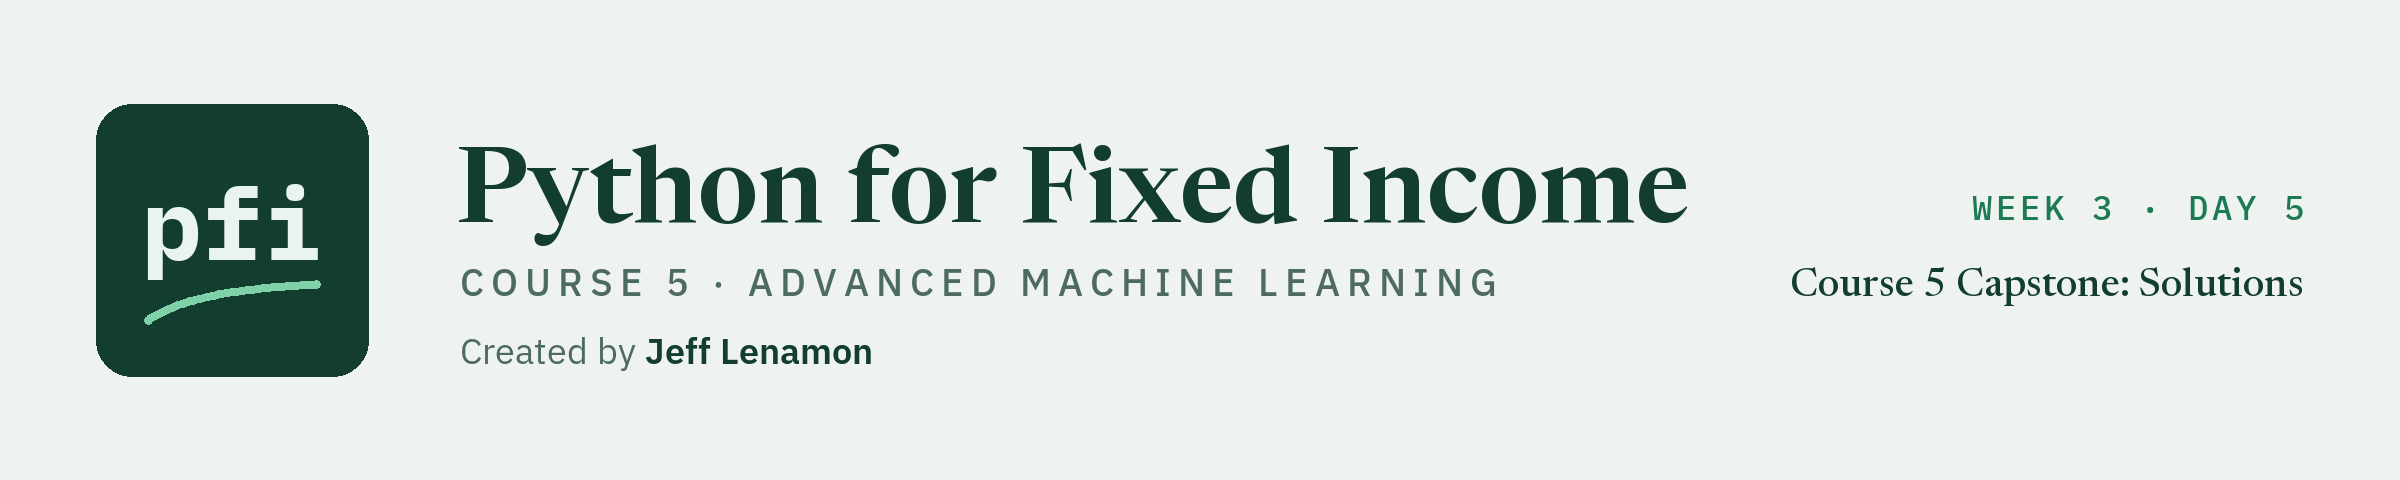

# Course 5 Capstone: Solutions

Week 3, Day 5. The worked version of the capstone: every question answered with code, its output, and what the output shows. Write your own answers and your own description first.

**Data:** `taiwan_bankruptcy.csv`, 6,819 rows of company financial ratios from the Taiwan Economic Journal, 1999 to 2009: **real**, UCI Machine Learning Repository dataset 572, CC BY 4.0. Citation: Taiwanese Bankruptcy Predic&#116;ion [Dataset]. (2020). UCI Machine Learning Repository. https://doi.org/10.24432/C5004D.

> This course is educational content created in a personal capacity. Nothing here is investment advice or a recommendation to buy or sell any security. All portfolio data is synthetic.

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/lenamonj/python-fixed-income/blob/main/course5_advanced_ml/week3/day5/course5_capstone_solutions.ipynb)

**Rows.** Every model in this capstone is fitted, tuned, and chosen by 5-fold cross-validation inside the training rows of `prepare`'s split; the test rows are scored once, in section 9, after the choice is written down, and never again.

## The Brief

### The scenario

A colleague who covers Asian corporates hands you a public file: financial ratios of Taiwanese companies, each row flagged by whether the company went bankrupt. The questions: **which of four models separates the bankrupt rows best on rows it never saw, how sure can anyone be when the test rows hold only a few dozen bankrupt companies, which ratios does the chosen model lean on, and where does it fail?**

Fourteen days built the tools: `ensemblekit.py` beside Course 4's `mlkit.py`, bagging and forests, boosting with XGBoost and LightGBM, randomized search and nested scores, out-of-fold thresholds, class weights and SMOTE inside a pipeline, bootstrap intervals, and SHAP values. Today you use them on a file you have not seen.

The answer is a description of a historical, anonymised dataset. It is not a credit view on any company, and nothing you build is a rating, an investment decision, or a probability of bankruptcy for any company going forward.

### What makes it hard

Nothing is planted. The file is the one the UCI repository publishes, and it has what real files have: a column that never changes, columns that repeat each other, columns that hold two very different scales of number, a row order that is not random, a rare outcome, and a page that leaves out much of what an analyst would want to know. Finding each one, saying what you do about it, and doing it without letting the test rows reach any choice is the work.

### What to hand in

This notebook, completed and run from top to bottom, with fifteen deliverables:

| # | Deliverable | Where |
| --- | --- | --- |
| 1 | `ensemblekit.py` complete, and `pytest -q` passing with its output saved | Section 1 |
| 2 | `load_taiwan(path)` in `taiwan.py`: reads the file, checks it, cleans the names, returns the frame with a check log | Section 2 |
| 3 | A description of the whole file in hashed checks: rows, bankruptcies, the constant column, the equal pairs, the two scales, the row order | Section 3 |
| 4 | `prepare(frame)`: drops the constant column and one of each equal pair, splits 80/20 stratified with `SEED`, asserts `assert_disjoint` | Section 4 |
| 5 | Four models as functions that return unfitted pipelines, each tuned by `RandomizedSearchCV` on the training rows | Section 5 |
| 6 | One imbalance decision with numbers: no weighting, weights, or SMOTE inside an `ImbPipeline` | Section 6 |
| 7 | Thresholds for a recall of 0.70 from `oof_threshold` on the training rows | Section 7 |
| 8 | The test rows opened once: `compare_models`, a bootstrap interval for each model, the confusion matrices | Section 9 |
| 9 | A choice with reasons, made before the test rows, and a nested score for it | Sections 8 and 9 |
| 10 | SHAP values for the chosen model, against permutation importance and split counts | Section 10 |
| 11 | A results workbook, `course5_capstone_results.xlsx`, read back and checked | Section 11 |
| 12 | A written description, "What the model shows, and where it fails", that passes `ensemblekit.assert_described` | Section 12 |
| 13 | Further practice, named | Section 12 |
| 14 | One Git commit for each deliverable that writes a file, then the tag `course5` | Every section, then Save the Day with Git |
| 15 | An AI-use log | Section 12 |

### How long

The course map gives the capstone one day. It is more work than one sitting. Plan on two or three.

| Sitting | Sections |
| --- | --- |
| First | 1 the module, 2 load and check, 3 the whole file, 4 prepare |
| Second | 5 four models, 6 the imbalance decision, 7 thresholds, 8 the choice |
| Third | 9 the test rows, 10 what the model leans on, 11 the workbook, 12 the description and the log, then Git and Bring It Home |

The searches in section 5 and the nested score in section 8 take a few minutes each on one thread. Let them run.

### The rules

1. **`frame` is the file as it arrived, with cleaned names,** and is never changed. Every step makes a new table.
2. **Description before the split, modelling after it.** Section 3 describes the whole file, and no number from it builds a feature or chooses anything. From section 4 on, the split comes first.
3. **Every step that learns from rows lives inside a pipeline,** fitted on training rows only: the quantile transform, SMOTE, the model itself.
4. **Three roles of rows.** Training rows fit. Folds of the training rows choose: the settings, the imbalance treatment, the thresholds, and the model. The test rows report, once, in section 9, after the choice is written down.
5. **`random_state=SEED` on everything that takes one, and `n_jobs=1` on every model, search, and cross-validation call.** The setup cell sets one thread before the libraries load, so every run prints the same numbers.
6. **Describe, never forecast.** Every sentence you write says what a model shows on this file and where it fails. Nothing says a company, or a kind of company, is a good or bad credit, and nothing says what a lender or an investor should do. An importance or a SHAP value is an association in this file, never a cause.
7. **Git only in the work folder.** Every Git command is written `!git -C "{work}" ...`, as on every day of the course.
8. **The notebook runs from top to bottom** with Restart and Run All before you hand it in.

### What help is allowed

Every earlier notebook of Courses 4 and 5 and your notes; the documentation of pandas, scikit-learn, XGBoost, LightGBM, imbalanced-learn, SHAP, and openpyxl; and an AI assistant, used the way the course taught: the docstring is the prompt, read the code that comes back, test it before you trust it, and keep a log as you go (question 12.4). Nothing from an employer goes into an AI tool or into Colab.

### How to check your work

Most questions ask you to store an answer in a variable such as `answer_2_1`. The cell after it calls `check()`, which prints `correct`, `not yet` with what you have, or `not attempted yet`. The right answers are not written anywhere in this notebook: each check holds a short code made from the right answer, and `check()` makes a code from yours in the same way and compares the two. A whole number can be given as `7` or `7.0`. A decimal is rounded to the places the question states before it is compared, so store the full number and let `check()` round it. Text is compared without regard to capitals or spaces at the ends. Several values go in a tuple, in the order the question asks.

Your decisions change the numbers that follow, so the checks after section 4 assume the decisions the course made. Under some questions a closed block that starts "Stuck after trying?" holds the decision the capstone expects for one kind of choice: not a count and not an answer. Leave it closed until you have made your own.

Worked answers are in `course5_capstone_solutions.ipynb` in this folder. Open it after you have written your own description.

## The Data

**The source.** UCI Machine Learning Repository, dataset 572, "Taiwanese Bankruptcy Predic&#116;ion", donated to the repository on 27 June 2020: https://archive.ics.uci.edu/dataset/572/taiwanese+bankruptcy+predic%74ion . Licence, quoted from the page: "This dataset is licensed under a Creative Commons Attribution 4.0 International (CC BY 4.0) license. This allows for the sharing and adaptation of the datasets for any purpose, provided that the appropriate credit is given." Citation, as the page gives it: Taiwanese Bankruptcy Predic&#116;ion [Dataset]. (2020). UCI Machine Learning Repository. https://doi.org/10.24432/C5004D.

**What the page says about the companies,** quoted: "The data were collected from the Taiwan Economic Journal for the years 1999 to 2009. Company bankruptcy was defined based on the business regulations of the Taiwan Stock Exchange." The page gives the file 6,819 instances and 95 features, and says it has no missing values.

**What the page does not say.** It names no creator and no paper. It gives no units and does not say how any value was scaled. It defines the outcome by the sentence above and no more: not how long after the ratios the bankruptcy was observed. It gives no company identifier and does not say whether a row is one company or one company in one year, so the course says "rows", never "companies" for a count. Its list of variables, X1 to X95, is in a different order from the file's columns, and some of its definitions match no column name, so the course reads the file's own column names and uses that list nowhere as a definition.

**What the course changed:** the file name only (`data.csv` in the provider's zip is `taiwan_bankruptcy.csv` here, byte for byte). Your loader makes two changes to the column names, as the licence asks that changes be stated: it removes the space every feature name starts with, and in three names it removes the yen sign and the space before it, so the notebook's sources stay plain text.

**Place and period.** One market's listed companies, 1999 to 2009. The accounting rules, the exchange's definition of bankruptcy, and the market differ from US corporate credit, as the card file of weeks 1 and 2 differed from US consumer credit.

**The data dictionary** is the file's own column names; there are no definitions to give. Section 2 prints them.

## Setup

Run the setup cells first. They are complete: do not change them. The first makes today's work folder and copies the data files into it: the Taiwan file, and the files the module's tests read. The next three write the complete `mlkit.py`, `ensemblekit.py`, and `test_ensemblekit.py` as day 14 left them. **If you kept your own `my_bondmath` up to date, paste your own two `ensemblekit` files into those cells instead.** Then the modules are imported, and the last setup cell defines `reload_capstone()`, `fold_scores()`, `answer_text()`, and `check()`.

Q. Set up the work folder and copy the data files into it.

In [1]:
# today's setup: the thread settings, the modules, the seed, the course data, and a fresh work folder
import os

# one thread for the maths libraries, so every run of the notebook gives the same last digits.
# These two lines must run before numpy, pandas, scikit-learn, XGBoost, or LightGBM is imported: if you ran another
# cell first, restart the kernel and run this cell first (in Colab: Runtime, Restart session).
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"

import importlib
import importlib.metadata
import importlib.util
import platform
import shutil
import subprocess
import sys
import tempfile
import urllib.request
from pathlib import Path

# packages a Colab runtime or a new environment may lack: stop with the line that installs the missing one
for module_name, install_name in [("sklearn", "scikit-learn"), ("statsmodels", "statsmodels"), ("scipy", "scipy"), ("xgboost", "xgboost"), ("lightgbm", "lightgbm"), ("imblearn", "imbalanced-learn"), ("shap", "shap"), ("pytest", "pytest")]:
    if importlib.util.find_spec(module_name) is None:
        raise RuntimeError(f"{install_name} is not installed. Run  !pip install {install_name}  in a new cell, "
                           "then run this cell again.")

import numpy as np
import pandas as pd

# SHAP is slow to import, so only the days that use it import it here
import shap

# the versions the saved outputs of this notebook came from (course5_advanced_ml/requirements.txt)
PINNED = {"numpy": "2.5.3", "pandas": "3.0.6", "scikit-learn": "1.9.1", "scipy": "1.18.1", "xgboost": "3.4.1", "lightgbm": "4.7.0", "imbalanced-learn": "0.14.2", "shap": "0.52.0", "matplotlib": "3.11.2", "pytest": "9.1.1"}
installed = {name: importlib.metadata.version(name) for name in PINNED}
print(f"Python {platform.python_version()}; " + ", ".join(f"{name} {version}" for name, version in installed.items()))
different = [name for name in PINNED if installed[name] != PINNED[name]]
if different:
    print(f"Not the course's pinned version: {', '.join(different)}. Printed numbers may differ in the last digits from the saved notebook.")

# the seed: one number for every random choice the course makes, so every run makes the same choices
SEED = 42

# remember the notebook's own folder, so that running this cell again starts from the same place
if "notebook_folder" not in globals():
    notebook_folder = Path.cwd()

# 1. find the course data before moving: the repo's data folder on your machine, GitHub in Colab
RAW_DATA = "https://raw.githubusercontent.com/lenamonj/python-fixed-income/main/data/"
local_data = (notebook_folder / ".." / ".." / ".." / "data").resolve()
on_github = not (local_data / "credit_card_default.csv").exists()

# 2. a fresh work folder for today, in the system temp folder, outside the course repo
work = Path(tempfile.mkdtemp(prefix="pfi_course5_15_"))
os.chdir(work)

# 3. copy today's data files into the work folder
DATA_FILES = ["credit_card_default.csv", "benchmark.csv", "ratings.csv", "polish_bankruptcy_5year.csv", "taiwan_bankruptcy.csv"]
for name in DATA_FILES:
    if on_github:
        urllib.request.urlretrieve(RAW_DATA + name, work / name)
    else:
        shutil.copy(local_data / name, work / name)

# print the folder's name only: its full path would show your user name
print(f"Work folder: {work.name}, in your temp folder")
print(f"Data files from {'GitHub' if on_github else 'the data folder of the course repo'}: {', '.join(DATA_FILES)}")
print(f"SEED = {SEED}")

Python 3.13.8; numpy 2.5.3, pandas 3.0.6, scikit-learn 1.9.1, scipy 1.18.1, xgboost 3.4.1, lightgbm 4.7.0, imbalanced-learn 0.14.2, shap 0.52.0, matplotlib 3.11.2, pytest 9.1.1
Work folder: pfi_course5_15_pkyzyx0d, in your temp folder
Data files from the data folder of the course repo: credit_card_default.csv, benchmark.csv, ratings.csv, polish_bankruptcy_5year.csv, taiwan_bankruptcy.csv
SEED = 42


Q. Write `mlkit.py`, Course 4's complete module, unchanged. `ensemblekit` imports it.

In [2]:
%%writefile mlkit.py
"""mlkit: the small pieces of machine learning that scikit-learn leaves to the analyst, written down and tested.

Written day by day in Python for Fixed Income, Course 4: Machine Learning.

Conventions, the same in every function:
- The seed is 42 wherever a function takes one, so every run gives the same numbers.
- Spreads are in basis points (bp). A model of log_oas is fitted in natural logs of bp; its errors are reported
  in bp after exp, and exp of a fitted log is a median-type value, not a mean.
- The positive class is 1 (default, bankrupt). Precision, recall, and F1 are for class 1 only.
- A row is flagged when its model probability is at least the threshold (probability >= threshold).
- Rows that fit a model, rows that choose a setting, and rows that report a result are kept apart; the split
  functions here prove it with a check that stops.
- Inputs of the wrong shape, or empty inputs, raise ValueError with a message that says what was wrong.
"""
import numpy as np  # arrays and arithmetic
import pandas as pd  # tables with labels
from numpy.typing import ArrayLike  # a list, an array, or a pandas Series


def assert_disjoint(train_index: ArrayLike, test_index: ArrayLike) -> None:
    """Stop if any row label is in both the training rows and the test rows.

    Inputs: the labels (or positions) of the rows in each part, for example X_train.index and X_test.index.
    Output: None when the parts share no label.
    Convention: a row in both parts is a test row the model has already seen, which flatters every metric.
    Raises AssertionError naming how many labels are in both parts, and ValueError if either part is empty.
    """
    # the labels of each part as sets
    train = set(np.asarray(train_index).tolist())
    test = set(np.asarray(test_index).tolist())
    if not train or not test:
        raise ValueError("train_index and test_index must both hold at least one label")
    # the labels found in both parts
    shared = train & test
    if shared:
        raise AssertionError(f"{len(shared)} row labels are in both the training and the test rows")


def _as_1d_array(values: ArrayLike, name: str) -> np.ndarray:
    """Return `values` as a 1-D float array, or raise ValueError naming the input."""
    array = np.asarray(values, dtype=float)
    if array.ndim != 1:
        raise ValueError(f"{name} must be one-dimensional, not {array.ndim}-dimensional")
    if array.size == 0:
        raise ValueError(f"{name} is empty")
    return array


def regression_metrics(y_true: ArrayLike, y_fitted: ArrayLike) -> dict[str, float]:
    """R-squared, mean absolute error, and root mean squared error of fitted values.

    Inputs: y_true and y_fitted, the same length, in the target's unit (for example oas in bp).
    Output: {"r2", "mae", "rmse"}. r2 is unitless, 1 - SS_res / SS_tot on the rows given (on test rows it can
    be negative); mae and rmse are in the target's unit. For a log_oas model, pass exp of both to get bp.
    Convention: equal to scikit-learn's r2_score, mean_absolute_error, and root_mean_squared_error.
    Excel: =RSQ(...) only for a straight line on one feature; =AVERAGE(ABS(a-b)) and =SQRT(SUMXMY2(a,b)/COUNT(a)).
    Raises ValueError if the inputs are empty, not one-dimensional, or of different lengths.
    """
    # check both inputs and that they line up row for row
    actual = _as_1d_array(y_true, "y_true")
    fitted = _as_1d_array(y_fitted, "y_fitted")
    if actual.size != fitted.size:
        raise ValueError(f"y_true has {actual.size} values and y_fitted has {fitted.size}")
    # each error in the target's unit
    errors = actual - fitted
    # R-squared: the share of the spread around the mean that the fitted values account for
    ss_res = float(np.sum(errors ** 2))
    ss_tot = float(np.sum((actual - actual.mean()) ** 2))
    r2 = 1 - ss_res / ss_tot
    # the average size of an error, and the square root of the average squared error
    mae = float(np.mean(np.abs(errors)))
    rmse = float(np.sqrt(np.mean(errors ** 2)))
    return {"r2": r2, "mae": mae, "rmse": rmse}


def adjusted_r2(r2: float, n_rows: int, n_features: int) -> float:
    """Adjusted R-squared: R-squared with a charge for each feature.

    Inputs: r2 on the training rows (unitless), n_rows the number of training rows, n_features the number of
    features not counting the intercept.
    Output: 1 - (1 - r2) x (n_rows - 1) / (n_rows - n_features - 1), unitless. An in-sample measure, so it is
    computed on training rows only.
    Excel: =1-(1-R2)*(n-1)/(n-k-1)
    Raises ValueError if n_features is negative or n_rows is not above n_features + 1.
    """
    # the formula needs at least one degree of freedom left after the features and the intercept
    if n_features < 0:
        raise ValueError(f"n_features must be 0 or more, not {n_features}")
    if n_rows <= n_features + 1:
        raise ValueError(f"n_rows ({n_rows}) must be greater than n_features + 1 ({n_features + 1})")
    # scale the unexplained share by the ratio of degrees of freedom
    return 1 - (1 - r2) * (n_rows - 1) / (n_rows - n_features - 1)


def rating_dummies(ratings: pd.Series, levels: list[str], reference: str) -> pd.DataFrame:
    """One indicator column per rating level except the reference level, which the intercept stands for.

    Inputs: ratings, one text rating per bond (for example "BBB+"); levels, every allowed level in the order the
    columns should follow (the rating column of ratings.csv, known in advance, not learned from the data);
    reference, the level left out.
    Output: a DataFrame with the same index, one float column (0.0 or 1.0) per level except reference, named
    rating_<level>, in the order of levels. A coefficient on rating_BB is then the difference from a bond rated
    `reference`, other features fixed.
    Convention: floats, not booleans, so every library and an Excel formula read the same 0.0 and 1.0. The
    reference is named by the caller, never chosen by alphabetical order.
    Raises ValueError if ratings is empty, reference is not in levels, or a rating is not in levels.
    """
    # check the inputs before building anything
    if len(ratings) == 0:
        raise ValueError("ratings is empty")
    if reference not in levels:
        raise ValueError(f"reference {reference!r} is not one of the levels")
    unknown = sorted(set(ratings) - set(levels))
    if unknown:
        raise ValueError(f"ratings not in levels: {unknown}")
    # one column per level, 1.0 where the bond has that rating
    columns = {f"rating_{level}": (ratings == level).astype(float) for level in levels if level != reference}
    return pd.DataFrame(columns, index=ratings.index)


def vif_table(X: pd.DataFrame) -> pd.Series:
    """Variance inflation factor of each feature: how much its coefficient's variance grows from the overlap with
    the other features.

    Input: X, the features as numeric columns (no constant column; one is added inside).
    Output: a Series named vif, one value per column, sorted from highest to lowest. VIF_j = 1 / (1 - R2_j),
    where R2_j is the R-squared of column j regressed on a constant and every other column. 1 means no overlap;
    above 5 is called high and above 10 very high, as conventions. A column that is an exact copy (or exact
    combination) of others has R2_j = 1 and VIF infinity.
    Convention: equal to statsmodels' variance_inflation_factor on X with a constant added.
    Excel: =1/(1-INDEX(LINEST(xj, other columns, TRUE, TRUE), 3, 1))
    Raises ValueError if X has fewer than two columns or fewer rows than columns plus two.
    """
    # check there is something to regress on, and enough rows to do it
    if X.shape[1] < 2:
        raise ValueError(f"X needs at least two columns, not {X.shape[1]}")
    if X.shape[0] < X.shape[1] + 2:
        raise ValueError(f"X has {X.shape[0]} rows, too few for {X.shape[1]} columns")
    values = X.to_numpy(dtype=float)
    result = {}
    for j, name in enumerate(X.columns):
        # column j is the target; a constant and the other columns are the features
        target = values[:, j]
        others = np.column_stack([np.ones(len(values)), np.delete(values, j, axis=1)])
        # least squares fit and its R-squared
        coefficients, *_ = np.linalg.lstsq(others, target, rcond=None)
        ss_res = float(np.sum((target - others @ coefficients) ** 2))
        ss_tot = float(np.sum((target - target.mean()) ** 2))
        r2 = 1 - ss_res / ss_tot
        # an exact combination of the others leaves no residual (R-squared 1 to the last digit): the VIF is infinite
        result[name] = np.inf if r2 >= 1 else 1 / (1 - r2)
    return pd.Series(result, name="vif").sort_values(ascending=False)


from scipy import stats  # Jarque-Bera and Shapiro-Wilk
from statsmodels.stats.diagnostic import het_breuschpagan  # Breusch-Pagan
from statsmodels.tools import add_constant  # the intercept column


def residual_tests(residuals: pd.Series, exog: pd.DataFrame) -> dict[str, float]:
    """p-values of three checks on a regression's residuals: constant variance and normality (two tests).

    Inputs: residuals, actual minus fitted on the training rows, in the target's unit; exog, the features the
    model was fitted on, without a constant (one is added inside), with the same rows.
    Output: {"breusch_pagan", "jarque_bera", "shapiro_wilk"}, each a p-value between 0 and 1. A small p-value
    (below 0.05, the course's convention) means the data would be surprising if the assumption held:
    - breusch_pagan: statsmodels het_breuschpagan with its default (Koenker's form, n x R-squared of the squared
      residuals regressed on a constant and exog); the assumption is constant variance;
    - jarque_bera: scipy.stats.jarque_bera (skew and kurtosis); the assumption is normal residuals;
    - shapiro_wilk: scipy.stats.shapiro; the assumption is normal residuals.
    Excel has no function for these; Breusch-Pagan can be built from LINEST and CHISQ.DIST.RT.
    Raises ValueError if the inputs are empty or have different numbers of rows.
    """
    # check the two inputs line up
    if len(residuals) == 0 or len(exog) == 0:
        raise ValueError("residuals and exog must not be empty")
    if len(residuals) != len(exog):
        raise ValueError(f"residuals has {len(residuals)} rows and exog has {len(exog)}")
    values = np.asarray(residuals, dtype=float)
    # Breusch-Pagan: returns the LM statistic, its p-value, then an F form; the LM p-value is kept
    _, bp_pvalue, _, _ = het_breuschpagan(values, add_constant(np.asarray(exog, dtype=float), has_constant="add"))
    # the two normality tests
    jb_pvalue = stats.jarque_bera(values).pvalue
    sw_pvalue = stats.shapiro(values).pvalue
    return {"breusch_pagan": float(bp_pvalue), "jarque_bera": float(jb_pvalue), "shapiro_wilk": float(sw_pvalue)}


from sklearn.pipeline import Pipeline  # the type of a chain of steps


def named_coefficients(pipeline: Pipeline) -> pd.Series:
    """The fitted coefficients of a pipeline's last step, labelled with the feature names that step saw.

    Input: a fitted scikit-learn Pipeline whose last step has coef_ (LinearRegression, Ridge, Lasso,
    LogisticRegression) and whose step before it has get_feature_names_out (a ColumnTransformer, a scaler).
    Output: a Series of coefficients indexed by feature name, in the order the model used them. Units: per unit
    of each feature as the model saw it, so per standard deviation after StandardScaler; the intercept is not
    included. For a binary LogisticRegression the one row of coef_ is used (log-odds of class 1).
    Raises ValueError if the last step has no coef_ (a tree, for example) or the pipeline has one step only.
    """
    # the model is the last step; the names come from everything before it
    if len(pipeline.steps) < 2:
        raise ValueError("the pipeline needs a preprocessing step before the model")
    model = pipeline.steps[-1][1]
    if not hasattr(model, "coef_"):
        raise ValueError(f"the last step, {type(model).__name__}, has no coef_")
    names = pipeline[:-1].get_feature_names_out()
    # a binary classifier keeps its coefficients in one row; flatten it
    coefficients = np.ravel(model.coef_)
    if coefficients.size != len(names):
        raise ValueError(f"{coefficients.size} coefficients but {len(names)} feature names")
    return pd.Series(coefficients, index=names, name="coefficient")


def odds_ratios(coefficients: pd.Series) -> pd.Series:
    """Odds ratios from logistic regression coefficients: exp of each coefficient, the intercept left out.

    Input: coefficients in log-odds, indexed by feature name, as statsmodels' Logit params (the intercept is
    named "const") or a Series with an entry named "intercept".
    Output: a Series of exp(coefficient) per feature: the factor by which the odds of class 1 multiply for one
    more unit of that feature, other features fixed. The unit is the feature's own (per 10,000 NT dollars if the
    feature was divided by 10,000; per standard deviation if it was scaled).
    Excel: =EXP(coef)
    Raises ValueError if no coefficient is left once the intercept is removed.
    """
    # leave out the intercept: exp of it is the odds when every feature is 0, not a ratio
    slopes = coefficients.drop(labels=["const", "intercept"], errors="ignore")
    if slopes.empty:
        raise ValueError("no coefficients left after removing the intercept")
    return np.exp(slopes).rename("odds_ratio")


def logistic_probability(z: float | ArrayLike) -> float | np.ndarray:
    """The logistic curve: turns log-odds z into a probability between 0 and 1.

    Input: z, a number or an array of numbers in log-odds (intercept plus coefficients times features).
    Output: 1 / (1 + exp(-z)), a float for a number, an array for an array. z = 0 gives 0.5.
    Excel: =1/(1+EXP(-z))
    """
    # numpy's exp works on a number and on an array alike
    probability = 1 / (1 + np.exp(-np.asarray(z, dtype=float)))
    return float(probability) if probability.ndim == 0 else probability


def _check_labels(y_true: ArrayLike, y_flag: ArrayLike) -> tuple[np.ndarray, np.ndarray]:
    """Return both inputs as integer arrays of 0 and 1, or raise ValueError."""
    actual = np.asarray(y_true)
    flagged = np.asarray(y_flag)
    if actual.ndim != 1 or flagged.ndim != 1 or actual.size == 0:
        raise ValueError("y_true and y_flag must be non-empty and one-dimensional")
    if actual.size != flagged.size:
        raise ValueError(f"y_true has {actual.size} values and y_flag has {flagged.size}")
    for name, values in (("y_true", actual), ("y_flag", flagged)):
        others = sorted(set(values.tolist()) - {0, 1})
        if others:
            raise ValueError(f"{name} holds labels other than 0 and 1: {others[:5]}")
    return actual.astype(int), flagged.astype(int)


def confusion_counts(y_true: ArrayLike, y_flag: ArrayLike) -> dict[str, int]:
    """The four cells of the confusion matrix, with 1 (default) as the positive class.

    Inputs: y_true, the actual outcome per row (0 or 1); y_flag, the model's flag per row (0 or 1), for example
    (probability >= threshold).
    Output: {"tn", "fp", "fn", "tp"} as whole numbers: true negatives (0 flagged 0), false positives (0 flagged
    1), false negatives (1 flagged 0), true positives (1 flagged 1). They add up to the number of rows.
    Convention: the same counts as confusion_matrix(y_true, y_flag).ravel() in scikit-learn.
    Excel: =COUNTIFS(actual,1,flag,1) and the other three combinations.
    Raises ValueError on labels other than 0 and 1, empty inputs, or inputs of different lengths.
    """
    actual, flagged = _check_labels(y_true, y_flag)
    # count each combination of actual and flag
    return {"tn": int(np.sum((actual == 0) & (flagged == 0))), "fp": int(np.sum((actual == 0) & (flagged == 1))),
            "fn": int(np.sum((actual == 1) & (flagged == 0))), "tp": int(np.sum((actual == 1) & (flagged == 1)))}


def classification_metrics(y_true: ArrayLike, y_flag: ArrayLike) -> dict[str, float]:
    """Accuracy, precision, recall, and F1 for class 1 (default), from 0/1 flags.

    Inputs: y_true and y_flag, as confusion_counts.
    Output: {"accuracy", "precision", "recall", "f1"}, each between 0 and 1:
    accuracy (TP + TN) / n; precision TP / (TP + FP), the share of flagged rows that are defaults; recall
    TP / (TP + FN), the share of defaults that are flagged; F1 their harmonic mean, 2TP / (2TP + FP + FN).
    Convention: pos_label=1, binary averaging, zero_division=0 (a model that flags nothing has precision 0, not
    an error), as scikit-learn's functions with those arguments.
    Excel: =TP/(TP+FP), =TP/(TP+FN) with the COUNTIFS cells.
    Raises ValueError as confusion_counts.
    """
    counts = confusion_counts(y_true, y_flag)
    tn, fp, fn, tp = counts["tn"], counts["fp"], counts["fn"], counts["tp"]
    # each ratio is 0 when its denominator is 0 (zero_division=0)
    accuracy = (tp + tn) / (tn + fp + fn + tp)
    precision = tp / (tp + fp) if tp + fp else 0.0
    recall = tp / (tp + fn) if tp + fn else 0.0
    f1 = 2 * tp / (2 * tp + fp + fn) if tp + fp + fn else 0.0
    return {"accuracy": accuracy, "precision": precision, "recall": recall, "f1": f1}


def threshold_for_recall(y_true: ArrayLike, proba: ArrayLike, target_recall: float) -> float:
    """The highest threshold at which the model still catches at least `target_recall` of the defaults.

    Inputs: y_true, actual outcomes (0 or 1) on the rows used to choose (validation rows, or out-of-fold
    predictions on training rows, never test rows); proba, the model probability of class 1 per row;
    target_recall, the share of defaults the desk asks to catch, above 0 and at most 1.
    Output: one of the distinct probabilities. Flagging rows with probability >= that threshold gives recall at
    least target_recall, and the next higher distinct probability would give less. A higher threshold flags
    fewer rows, so this is the threshold with the fewest flags that meets the target.
    Convention: the course's threshold rule, stated as an illustration of the recall-against-precision choice.
    Raises ValueError if target_recall is not in (0, 1], the inputs differ in length, or there is no row of
    class 1.
    """
    # check the target and the inputs
    if not 0 < target_recall <= 1:
        raise ValueError(f"target_recall must be above 0 and at most 1, not {target_recall}")
    scores = _as_1d_array(proba, "proba")
    # y_true is checked as a set of 0/1 labels the same length as proba
    actual, _ = _check_labels(y_true, np.zeros(scores.size, dtype=int))
    positives = int(actual.sum())
    if positives == 0:
        raise ValueError("y_true has no row of class 1, so recall is undefined")
    # sort rows from the highest probability down; lowering the threshold adds rows in this order
    order = np.argsort(-scores, kind="stable")
    sorted_scores, sorted_actual = scores[order], actual[order]
    # defaults caught when every row down to this one is flagged
    caught = np.cumsum(sorted_actual)
    # a threshold equal to a probability flags every row with that probability, so look at the last row of
    # each run of equal probabilities
    last_of_run = np.append(sorted_scores[1:] != sorted_scores[:-1], True)
    recall = caught[last_of_run] / positives
    thresholds = sorted_scores[last_of_run]
    # thresholds run from high to low and recall only rises: take the first one that meets the target
    meets = np.nonzero(recall >= target_recall)[0]
    return float(thresholds[meets[0]])


from sklearn.model_selection import KFold, StratifiedKFold  # the course's cross-validation splitters


def cv_folds(kind: str = "classification") -> KFold | StratifiedKFold:
    """The course's cross-validation splitter, so the choice lives in one place.

    Input: kind, "classification" or "regression".
    Output: StratifiedKFold(5, shuffle=True, random_state=42) for classification (each fold keeps the share of
    class 1), KFold(5, shuffle=True, random_state=42) for regression. Pass it as cv= to GridSearchCV,
    cross_val_score, or cross_val_predict, on training rows only.
    Convention: never for dated rows, which use walk_forward_splits or TimeSeriesSplit (no shuffle).
    Raises ValueError for any other kind.
    """
    # five folds, shuffled once with the course's seed
    if kind == "classification":
        return StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    if kind == "regression":
        return KFold(n_splits=5, shuffle=True, random_state=42)
    raise ValueError(f'kind must be "classification" or "regression", not {kind!r}')


import re  # whole-word search

from sklearn.metrics import average_precision_score, roc_auc_score

# words that turn a description into a forecast, advice, or a lending decision; a reminder, not a proof
FORECAST_WORDS = ["will", "expect", "expects", "should", "forecast", "forecasts", "cheap", "rich", "attractive",
                  "signal", "signals", "buy", "sell", "approve", "decline", "lend", "invest"]


def compare_models(models: dict, X: pd.DataFrame, y: ArrayLike, thresholds: dict[str, float]) -> pd.DataFrame:
    """One row of metrics per fitted model, on the rows given.

    Inputs: models, {name: a fitted classifier with predict_proba}, fitted by the caller on training rows;
    X and y, the rows to report on (validation rows, or the test rows once at the end); thresholds,
    {name: threshold} for every model, chosen on rows other than these test rows.
    Output: a DataFrame indexed by model name with columns roc_auc and average_precision (from probabilities,
    no threshold), then threshold, accuracy, precision, recall, f1 for rows flagged at probability >= threshold.
    Convention: nothing is fitted here; an unfitted model raises scikit-learn's NotFittedError.
    Raises ValueError if models is empty or a model has no threshold.
    """
    # check every model has a threshold before computing anything
    if not models:
        raise ValueError("models is empty")
    missing = sorted(set(models) - set(thresholds))
    if missing:
        raise ValueError(f"no threshold for: {missing}")
    rows = {}
    for name, model in models.items():
        # the model probability of class 1 per row
        proba = model.predict_proba(X)[:, 1]
        # metrics that rank without a threshold, then metrics at the model's threshold
        row = {"roc_auc": roc_auc_score(y, proba), "average_precision": average_precision_score(y, proba),
               "threshold": thresholds[name]}
        row |= classification_metrics(y, (proba >= thresholds[name]).astype(int))
        rows[name] = row
    return pd.DataFrame.from_dict(rows, orient="index")


def assert_descriptive(text: str) -> None:
    """Stop if a written description uses a word from FORECAST_WORDS.

    Input: text, a description of what a model shows.
    Output: None if no listed word appears as a whole word, in any case.
    Convention: the list is a reminder, not a proof. A text can pass and still make a forecast in other words,
    and a listed word can be harmless in context; the check makes the writer look again.
    Raises ValueError naming every listed word found, in the order of FORECAST_WORDS.
    """
    # whole words only, ignoring case: "willing" does not match "will"
    found = [word for word in FORECAST_WORDS if re.search(rf"\b{word}\b", text, flags=re.IGNORECASE)]
    if found:
        raise ValueError(f"the text uses forecast, advice, or lending words: {found}")


def walk_forward_splits(dates: pd.DatetimeIndex, min_train: int, test_size: int,
                        gap: int = 0) -> list[tuple[np.ndarray, np.ndarray]]:
    """Expanding-window splits for dated rows: train on the past, test on the rows that follow.

    Inputs: dates, the rows' dates, unique and ascending; min_train, the rows in the first training window;
    test_size, the rows in each test window; gap, rows left out between the last training row and the first
    test row (use the number of rows a target or feature spans; 0 for a same-day target).
    Output: a list of (train_positions, test_positions), integer positions into dates. Fold k trains on
    positions 0 to min_train + k x test_size - 1 and tests the next test_size positions after `gap` rows.
    The window steps forward by test_size; a last test window shorter than test_size is dropped.
    Convention: never shuffled; every training date is before every test date.
    Raises ValueError if the dates are not unique and ascending, min_train or test_size is below 1, gap is
    negative, or there are too few rows for one fold.
    """
    # check the dates and the sizes
    index = pd.DatetimeIndex(dates)
    if not (index.is_unique and index.is_monotonic_increasing):
        raise ValueError("dates must be unique and ascending")
    if min_train < 1 or test_size < 1 or gap < 0:
        raise ValueError(f"need min_train >= 1, test_size >= 1, gap >= 0; got {min_train}, {test_size}, {gap}")
    splits = []
    train_end = min_train  # one past the last training position
    # add folds while a whole test window fits after the gap
    while train_end + gap + test_size <= len(index):
        test_start = train_end + gap
        splits.append((np.arange(0, train_end), np.arange(test_start, test_start + test_size)))
        train_end += test_size
    if not splits:
        raise ValueError(f"{len(index)} rows are too few for min_train {min_train}, gap {gap}, test_size {test_size}")
    return splits


def assert_past_only(train_dates: ArrayLike, test_dates: ArrayLike, gap: int = 0,
                     calendar: ArrayLike | None = None) -> None:
    """Stop unless every training date is earlier than every test date, with a gap where one is asked for.

    Inputs: the dates of the training rows and of the test rows; gap, the rows of `calendar` that must lie
    strictly between the last training date and the first test date; calendar, every date of the dataset
    (needed when gap is above 0).
    Output: None when the split uses only the past.
    Raises AssertionError naming the last training date and the first test date when the order or the gap is
    wrong, and ValueError if either part is empty or a gap is asked for without a calendar.
    """
    train = pd.DatetimeIndex(train_dates)
    test = pd.DatetimeIndex(test_dates)
    if len(train) == 0 or len(test) == 0:
        raise ValueError("train_dates and test_dates must both hold at least one date")
    # the latest training date must come before the earliest test date
    last_train, first_test = train.max(), test.min()
    if not last_train < first_test:
        raise AssertionError(f"a training date ({last_train.date()}) is not before the first test date "
                             f"({first_test.date()})")
    if gap > 0:
        if calendar is None:
            raise ValueError("a gap is counted in rows of the calendar, so calendar is needed")
        # rows of the calendar strictly between the two dates
        days = pd.DatetimeIndex(calendar)
        between = int(((days > last_train) & (days < first_test)).sum())
        if between < gap:
            raise AssertionError(f"only {between} rows lie between {last_train.date()} and {first_test.date()}, "
                                 f"fewer than the gap of {gap}")


from collections.abc import Iterable

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score


def elbow_table(X: ArrayLike, k_values: Iterable[int], seed: int = 42) -> pd.DataFrame:
    """Inertia and silhouette of K-means for each number of clusters, to choose k by judgement.

    Inputs: X, the features already scaled (K-means measures distance, so units decide the clusters); k_values,
    the numbers of clusters to try, each 2 or more; seed, passed as random_state.
    Output: a DataFrame indexed by k (named k) with columns inertia (the within-cluster sum of squared distances,
    in squared scaled units; it falls as k rises) and silhouette (the mean silhouette coefficient, Euclidean,
    -1 to 1; higher means tighter, better separated clusters).
    Convention: KMeans(n_clusters=k, n_init=10, random_state=seed), n_init written out.
    Raises ValueError if k_values is empty, a k is below 2, or a k is not below the number of rows.
    """
    # check the k values before fitting
    ks = list(k_values)
    if not ks:
        raise ValueError("k_values is empty")
    n_rows = len(X)
    bad = [k for k in ks if k < 2 or k >= n_rows]
    if bad:
        raise ValueError(f"each k must be at least 2 and below the {n_rows} rows; not {bad}")
    rows = []
    for k in ks:
        # fit K-means with ten starts and the course's seed
        model = KMeans(n_clusters=k, n_init=10, random_state=seed).fit(X)
        rows.append({"k": k, "inertia": float(model.inertia_), "silhouette": float(silhouette_score(X, model.labels_))})
    return pd.DataFrame(rows).set_index("k")


def cluster_profile(frame: pd.DataFrame, labels: ArrayLike, columns: list[str]) -> pd.DataFrame:
    """Describe each cluster in the data's own units: how many rows, and the median of each column.

    Inputs: frame, the rows in their original units (oas in bp, duration in years), not the scaled features the
    clusters were fitted on; labels, the cluster of each row, in the same order; columns, the columns to profile.
    Output: a DataFrame indexed by cluster (named cluster, sorted), with count and one median column per name in
    columns, in the frame's units. A profile describes a group; it does not rank one.
    Excel: a pivot table counts and averages but has no median; =MEDIAN(IF(labels=k, column)) does.
    Raises ValueError if labels and frame differ in length, frame is empty, or a column is not in frame.
    """
    # check the inputs line up and the columns exist
    labels = np.asarray(labels)
    if len(frame) == 0:
        raise ValueError("frame is empty")
    if len(labels) != len(frame):
        raise ValueError(f"labels has {len(labels)} values and frame has {len(frame)} rows")
    missing = [c for c in columns if c not in frame.columns]
    if missing:
        raise ValueError(f"columns not in frame: {missing}")
    # group the original rows by cluster, then count and take medians
    grouped = frame[columns].groupby(pd.Series(labels, index=frame.index, name="cluster"))
    profile = grouped.median()
    profile.insert(0, "count", grouped.size())
    return profile.sort_index()


from sklearn.decomposition import PCA


def pca_loadings(pca: PCA, names: list[str]) -> pd.DataFrame:
    """The loadings of a fitted PCA, one column per component, each with a fixed sign.

    Inputs: pca, a fitted scikit-learn PCA; names, the input columns in the order the PCA saw them (for the
    curve, the tenors).
    Output: a DataFrame indexed by name with columns PC1, PC2, ...: each component's weights on the inputs
    (pca.components_ transposed, unit length). A component's sign is arbitrary, so each column is multiplied by
    -1 where needed to make its loadings sum to a positive number; a rerun or another library then gives the
    same picture. Scores that match these loadings are (X - pca.mean_) @ loadings.
    Excel: no PCA function; =MMULT(changes less their column means, loadings) gives the scores.
    Raises ValueError if names does not have one entry per input column.
    """
    # one name per input column
    components = np.asarray(pca.components_)
    if len(names) != components.shape[1]:
        raise ValueError(f"{len(names)} names for {components.shape[1]} input columns")
    loadings = pd.DataFrame(components.T, index=names,
                            columns=[f"PC{i}" for i in range(1, components.shape[0] + 1)])
    # flip each component whose loadings sum to a negative number
    signs = np.where(loadings.sum(axis=0) < 0, -1.0, 1.0)
    return loadings * signs


def explained_table(pca: PCA) -> pd.DataFrame:
    """The share of variance each component of a fitted PCA accounts for, and the running total, in percent.

    Input: pca, a fitted scikit-learn PCA.
    Output: a DataFrame indexed by PC1, PC2, ... with explained_pct (explained_variance_ratio_ x 100) and
    cumulative_pct (the running sum). With every component kept, the last cumulative_pct is 100.
    """
    # the ratios in percent, then their running sum
    explained = np.asarray(pca.explained_variance_ratio_) * 100
    index = [f"PC{i}" for i in range(1, len(explained) + 1)]
    return pd.DataFrame({"explained_pct": explained, "cumulative_pct": np.cumsum(explained)}, index=index)

Writing mlkit.py


Q. Write `ensemblekit.py` and `test_ensemblekit.py` as day 14 left them: the complete module.

In [3]:
%%writefile ensemblekit.py
"""ensemblekit: the pieces of ensembles, tuning, and rare-event modelling that the libraries leave to the analyst,
written down and tested.

Written day by day in Python for Fixed Income, Course 5: Advanced Machine Learning. It imports mlkit (Course 4's
module) and never changes it.

Conventions, the same in every function:
- The seed is 42 wherever a function takes one, so every run gives the same numbers.
- The positive class is 1 (default, bankrupt). A row is flagged when its model output is at least the threshold.
- Course 5 never scores a row that Course 4 used as a test row. The course4_*_rows functions rebuild Course 4's
  splits exactly and return only the rows Course 5 may use; the closed rows are never returned.
- Rows that fit a model, rows that choose a setting, and rows that report a result are kept apart.
- Every library call that can use more than one thread is given n_jobs=1, so every run gives the same digits.
- Inputs of the wrong shape, or empty inputs, raise ValueError with a message that says what was wrong.
"""
import numpy as np  # arrays and arithmetic
import pandas as pd  # tables with labels
from sklearn.model_selection import train_test_split  # Course 4's split, rebuilt

import mlkit  # Course 4's module: thresholds, metrics, splitters, and the no-leak check

# the card file: its outcome column and the 19 model columns (the four person columns are never features)
CARD_TARGET = "default payment next month"
CARD_FEATURES = ["LIMIT_BAL", "PAY_0", "PAY_2", "PAY_3", "PAY_4", "PAY_5", "PAY_6"] + \
    [f"BILL_AMT{i}" for i in range(1, 7)] + [f"PAY_AMT{i}" for i in range(1, 7)]


def course4_card_rows(frame: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame, pd.Series, pd.Series]:
    """Course 4's 60/20/20 split of the card file, rebuilt, without its test rows.

    Input: frame, the 30,000 accounts of credit_card_default.csv as read by pd.read_csv.
    Output: X_train (18,000 rows), X_valid (6,000 rows), y_train, y_valid, with the 19 model columns in
    CARD_FEATURES and the file's row labels. Course 4's 6,000 test rows are never returned.
    Convention: the same two calls as Course 4: train_test_split(test_size=0.2, stratify=y, random_state=42), then
    the remaining 80 percent split with test_size=0.25, stratified, same seed. The validation rows were used in
    Course 4 to choose a threshold and a pruning level, never to fit.
    Raises ValueError if a column is missing or the frame does not have 30,000 rows.
    """
    # check the frame is the whole card file
    missing = [name for name in CARD_FEATURES + [CARD_TARGET] if name not in frame.columns]
    if missing:
        raise ValueError(f"frame lacks the columns {missing}")
    if len(frame) != 30_000:
        raise ValueError(f"frame must hold the 30,000 card accounts, not {len(frame)}")
    X, y = frame[CARD_FEATURES], frame[CARD_TARGET]
    # Course 4's first cut puts 20 percent aside as test rows: they are dropped here, never returned
    X_rest, _, y_rest, _ = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
    # Course 4's second cut: a quarter of the rest (20 percent of the file) as validation rows
    X_train, X_valid, y_train, y_valid = train_test_split(X_rest, y_rest, test_size=0.25, stratify=y_rest,
                                                          random_state=42)
    mlkit.assert_disjoint(X_train.index, X_valid.index)
    return X_train, X_valid, y_train, y_valid


def bootstrap_positions(n_rows: int, seed: int = 42) -> np.ndarray:
    """Draw n_rows row positions with replacement: one bootstrap sample.

    Input: n_rows, how many rows the data has (at least 1); seed, the random seed.
    Output: an array of n_rows positions from 0 to n_rows - 1, in the order drawn. A position can appear more than
    once, and some positions do not appear at all (about 36.8 percent of them for large n_rows).
    Convention: np.random.default_rng(seed).integers(0, n_rows, n_rows), so the same seed gives the same sample.
    Excel: =RANDBETWEEN(1,n) draws one position but takes no seed and changes at every recalculation.
    Raises ValueError if n_rows is below 1.
    """
    if n_rows < 1:
        raise ValueError(f"n_rows must be at least 1, not {n_rows}")
    # one generator per call, seeded, so the draw does not depend on anything drawn before
    rng = np.random.default_rng(seed)
    return rng.integers(0, n_rows, n_rows)


def out_of_bag(n_rows: int, drawn: np.ndarray) -> np.ndarray:
    """The positions a bootstrap sample never drew: its out-of-bag rows.

    Inputs: n_rows, how many rows the data has; drawn, the positions of a bootstrap sample.
    Output: the sorted positions from 0 to n_rows - 1 that are not in drawn.
    Convention: a model fitted on the drawn rows has never seen these rows, so they can score it.
    Raises ValueError if drawn is empty or holds a position outside 0 to n_rows - 1.
    """
    positions = np.asarray(drawn)
    if positions.size == 0:
        raise ValueError("drawn is empty")
    if positions.min() < 0 or positions.max() > n_rows - 1:
        raise ValueError(f"drawn holds a position outside 0 to {n_rows - 1}")
    # every position, minus the ones drawn at least once
    return np.setdiff1d(np.arange(n_rows), positions)


from sklearn.metrics import roc_auc_score  # ranking quality from probabilities


def bagged_proba(bagging, X: pd.DataFrame) -> np.ndarray:
    """Bagging by hand: the average of each fitted tree's class-1 probability, each on its own columns.

    Inputs: bagging, a fitted BaggingClassifier; X, the rows to score, with the columns it was fitted on.
    Output: one number per row, the mean over bagging.estimators_ of each tree's class-1 probability on the
    columns listed in bagging.estimators_features_. It equals bagging.predict_proba(X)[:, 1] within 1e-12.
    Convention: a tree whose bootstrap sample held only one class gives 0 for class 1 when that class is 0.
    Excel: with each tree's column of outputs pasted side by side, =AVERAGE(B2:K2) filled down.
    Raises ValueError if bagging is not fitted.
    """
    if not hasattr(bagging, "estimators_"):
        raise ValueError("bagging is not fitted: call fit first")
    # the trees were fitted on plain arrays of the chosen columns, so score them the same way
    values = np.asarray(X, dtype=float)
    total = np.zeros(len(values))
    for tree, columns in zip(bagging.estimators_, bagging.estimators_features_):
        proba = tree.predict_proba(values[:, columns])
        # the tree's classes are positions in bagging.classes_; class 1 is position 1
        position = np.flatnonzero(tree.classes_ == 1)
        total += proba[:, position[0]] if position.size else 0.0
    return total / len(bagging.estimators_)


def oob_auc(model, y_train) -> float:
    """ROC AUC of the out-of-bag probabilities of a bagged model or a random forest.

    Inputs: model, fitted with oob_score=True on the training rows; y_train, those rows' outcomes, in order.
    Output: roc_auc_score(y_train, model.oob_decision_function_[:, 1]): each row scored only by the trees that
    did not draw it.
    Convention: model.oob_score_ is the accuracy of the out-of-bag votes for a classifier, not ROC AUC; this
    function gives the ranking number the course compares models by.
    Raises ValueError if the model was fitted without oob_score=True, or if a row has no out-of-bag vote (too few
    trees, so some row was drawn by every tree).
    """
    if not hasattr(model, "oob_decision_function_"):
        raise ValueError("the model has no out-of-bag outputs: fit it with oob_score=True")
    proba = model.oob_decision_function_[:, 1]
    if np.isnan(proba).any():
        raise ValueError(f"{int(np.isnan(proba).sum())} rows have no out-of-bag vote: use more trees")
    return float(roc_auc_score(y_train, proba))


def tree_correlation(forest, X: pd.DataFrame) -> float:
    """How much the trees of an ensemble agree: the mean pairwise correlation of their class-1 outputs.

    Inputs: forest, a fitted random forest, extra-trees, or bagging model (anything with estimators_, and
    estimators_features_ for bagging); X, the rows to score (validation rows).
    Output: the mean of the upper triangle of np.corrcoef over the trees' class-1 probabilities on X: 1 means
    every tree gives the same ranking, 0 means no linear agreement.
    Convention: averaging trees removes less noise the more they agree; a random forest tries a random subset of
    columns at each split to lower this number.
    Excel: =CORREL(B2:B6001,C2:C6001) for one pair of pasted tree columns.
    Raises ValueError if the ensemble has fewer than two trees.
    """
    trees = list(forest.estimators_)
    if len(trees) < 2:
        raise ValueError(f"need at least two trees, the ensemble has {len(trees)}")
    # each tree was fitted on a plain array; bagging may give each tree its own columns
    values = np.asarray(X, dtype=float)
    columns = getattr(forest, "estimators_features_", [slice(None)] * len(trees))
    outputs = np.array([tree.predict_proba(values[:, cols])[:, -1] for tree, cols in zip(trees, columns)])
    # the correlation of every pair of trees, then the mean above the diagonal
    matrix = np.corrcoef(outputs)
    return float(matrix[np.triu_indices(len(trees), k=1)].mean())


from sklearn.inspection import permutation_importance  # the drop in a score when one column is shuffled


def importance_table(model, X_valid: pd.DataFrame, y_valid, scoring: str = "roc_auc", n_repeats: int = 5,
                     seed: int = 42) -> pd.DataFrame:
    """Two importance measures side by side: impurity importance and permutation importance.

    Inputs: model, a fitted tree ensemble with feature_importances_, fitted on a DataFrame; X_valid, y_valid,
    rows the model was NOT fitted on (validation rows); scoring, the score whose drop is measured; n_repeats, how
    many shuffles per column; seed, the random seed of the shuffles.
    Output: a DataFrame indexed by feature with columns impurity (model.feature_importances_, from the training
    rows, sums to 1), permutation (the mean drop in the score over n_repeats shuffles of that column),
    permutation_sd (their standard deviation), impurity_rank and permutation_rank (1 = largest), sorted by
    permutation, largest first.
    Convention: impurity importance is learned on the training rows and rewards columns the trees could split on
    to fit noise; permutation importance on unseen rows measures how much the score leans on a column there.
    Neither measure is a cause. permutation_importance runs with n_jobs=1.
    Raises ValueError if the model has no feature_importances_ (an unfitted model, or a linear model).
    """
    if not hasattr(model, "feature_importances_"):
        raise ValueError("the model has no feature_importances_: fit a tree ensemble first")
    # shuffle each column n_repeats times on the rows given and record the drop in the score
    result = permutation_importance(model, X_valid, y_valid, scoring=scoring, n_repeats=n_repeats,
                                    random_state=seed, n_jobs=1)
    table = pd.DataFrame({"impurity": model.feature_importances_, "permutation": result.importances_mean,
                          "permutation_sd": result.importances_std}, index=pd.Index(X_valid.columns, name="feature"))
    # rank 1 is the largest value; ties share the better rank
    table["impurity_rank"] = table["impurity"].rank(ascending=False, method="min").astype(int)
    table["permutation_rank"] = table["permutation"].rank(ascending=False, method="min").astype(int)
    return table.sort_values("permutation", ascending=False, kind="stable")


from sklearn.model_selection import cross_val_predict  # out-of-fold outputs, one per row


def course4_bench_rows(bench: pd.DataFrame, ratings: pd.DataFrame) -> pd.DataFrame:
    """Course 4's 615 training bonds of the synthetic benchmark, without its 206 test bonds.

    Inputs: bench, the 821 bonds of benchmark.csv; ratings, ratings.csv (rating and score).
    Output: the 615 training bonds with every column of bench plus score (the rating's number, 1 = AAA),
    log_oas (natural log of oas in bp), years (days from as_of_date to maturity / 365.25), and amount_bn
    (amount_outstanding in billions), with bench's row labels. Course 4's 206 test bonds are never returned.
    Convention: Course 4's split, train_test_split(test_size=0.25, random_state=42) on the joined rows. The bonds
    and their spreads are invented by the course's generator.
    Raises ValueError if bench does not hold 821 bonds.
    """
    if len(bench) != 821:
        raise ValueError(f"bench must hold the 821 benchmark bonds, not {len(bench)}")
    # the rating's number, joined row for row (each rating appears once in ratings)
    frame = bench.merge(ratings[["rating", "score"]], on="rating", how="left", validate="many_to_one")
    frame["log_oas"] = np.log(frame["oas"])
    dates = pd.to_datetime(frame["maturity"]) - pd.to_datetime(frame["as_of_date"])
    frame["years"] = dates.dt.days / 365.25
    frame["amount_bn"] = frame["amount_outstanding"] / 1e9
    # Course 4's split: the second part was its test set, dropped here
    train, _ = train_test_split(frame, test_size=0.25, random_state=42)
    return train


def oof_threshold(model, X, y, target_recall: float = 0.70, cv=None) -> tuple[float, np.ndarray]:
    """The course's threshold rule, applied to out-of-fold probabilities on the training rows.

    Inputs: model, an unfitted (or fitted) classifier with predict_proba; X, y, the training rows; target_recall,
    the share of defaults to catch; cv, a splitter (default mlkit.cv_folds(), stratified 5-fold, seed 42).
    Output: (threshold, proba): proba holds each training row's class-1 probability from the fold model that did
    not see it (cross_val_predict, n_jobs=1); threshold is mlkit.threshold_for_recall(y, proba, target_recall),
    the highest threshold whose out-of-fold recall is at least target_recall.
    Convention: the threshold is chosen on training rows only, so validation and test rows stay for reporting.
    cross_val_predict fits clones, so the caller's model is left as it was.
    Raises ValueError from mlkit.threshold_for_recall on a bad target or no row of class 1.
    """
    folds = cv if cv is not None else mlkit.cv_folds()
    proba = cross_val_predict(model, X, y, cv=folds, method="predict_proba", n_jobs=1)[:, 1]
    return mlkit.threshold_for_recall(y, proba, target_recall), proba


def samme_alpha(weighted_error: float, learning_rate: float = 1.0) -> float:
    """The weight AdaBoost gives one stump's vote, for two classes.

    Inputs: weighted_error, the stump's error with each row counted by its weight (above 0, below 0.5);
    learning_rate, the shrinkage AdaBoostClassifier applies (default 1.0).
    Output: learning_rate * ln((1 - e) / e), in natural logs. A stump right on 80 percent of the weight gets
    ln(4) = 1.3863; one barely better than a coin gets almost 0.
    Convention: the SAMME weight with two classes (its extra term ln(classes - 1) is ln 1 = 0); it equals
    AdaBoostClassifier's estimator_weights_.
    Excel: =LN((1-e)/e).
    Raises ValueError unless 0 < weighted_error < 0.5.
    """
    if not 0 < weighted_error < 0.5:
        raise ValueError(f"weighted_error must be above 0 and below 0.5, not {weighted_error}")
    return float(learning_rate * np.log((1 - weighted_error) / weighted_error))


def reweight(weights: np.ndarray, missed: np.ndarray, alpha: float) -> np.ndarray:
    """AdaBoost's new row weights after one round: the rows the stump missed count for more.

    Inputs: weights, the current row weights (non-negative); missed, 1 where the stump was wrong and 0 where it
    was right, the same length; alpha, the stump's weight (samme_alpha).
    Output: weights * exp(alpha * missed), divided by their sum so the new weights sum to 1.
    Excel: =w*EXP(alpha*miss) filled down, then each divided by the column's SUM.
    Raises ValueError if the lengths differ, the input is empty, or a weight is negative.
    """
    w = np.asarray(weights, dtype=float)
    m = np.asarray(missed, dtype=float)
    if w.size == 0 or w.shape != m.shape:
        raise ValueError(f"weights and missed must be non-empty and the same length, not {w.size} and {m.size}")
    if (w < 0).any():
        raise ValueError("weights must not be negative")
    # a missed row is multiplied by e^alpha, a correct row by 1
    new = w * np.exp(alpha * m)
    return new / new.sum()


from sklearn.tree import DecisionTreeRegressor  # one round's tree, fitted to the residuals


def boost_by_hand(X, y, n_rounds: int, learning_rate: float, max_depth: int, seed: int = 42) -> np.ndarray:
    """Gradient boosting for a squared error, by hand: start from the mean, then fit trees to the residuals.

    Inputs: X, the feature rows; y, the target (for example log_oas); n_rounds, how many trees; learning_rate,
    the fraction of each tree's output added; max_depth, each tree's depth; seed, each tree's random_state.
    Output: the fitted values on X after n_rounds: F0 = mean(y), then for each round
    F = F + learning_rate * tree.predict(X), with the tree fitted to the residuals y - F.
    Convention: equals GradientBoostingRegressor(n_estimators=n_rounds, learning_rate=..., max_depth=...,
    random_state=seed).predict(X) on the rows it was fitted on, within 1e-12. No criterion= is passed (scikit-learn
    1.9 deprecates "friedman_mse" for a regression tree).
    Excel: one round is =y-F, the two leaf means by AVERAGEIFS on either side of the stump's threshold, and
    =F+lr*IF(x<=t,left,right).
    Raises ValueError if n_rounds is below 1 or learning_rate is not positive.
    """
    if n_rounds < 1 or learning_rate <= 0:
        raise ValueError(f"n_rounds must be at least 1 and learning_rate positive, not {n_rounds}, {learning_rate}")
    target = np.asarray(y, dtype=float)
    # round 0: every row's fitted value is the mean
    fitted = np.full(target.size, target.mean())
    for _ in range(n_rounds):
        # fit a small tree to what is still unexplained, then add a fraction of it
        tree = DecisionTreeRegressor(max_depth=max_depth, random_state=seed).fit(X, target - fitted)
        fitted = fitted + learning_rate * tree.predict(X)
    return fitted


def mae_bp(log_true, log_fitted) -> float:
    """Mean absolute error in bp of a model fitted on log spreads.

    Inputs: log_true and log_fitted, natural logs of spreads in bp, the same length.
    Output: mean(|exp(log_true) - exp(log_fitted)|), in bp.
    Convention: the course's benchmark metric; exp of a fitted log is a median-type value, not a mean.
    Excel: =AVERAGE(ABS(EXP(a)-EXP(b))).
    Raises ValueError if the inputs are empty or of different lengths.
    """
    true, fitted = np.asarray(log_true, dtype=float), np.asarray(log_fitted, dtype=float)
    if true.size == 0 or true.shape != fitted.shape:
        raise ValueError(f"inputs must be non-empty and the same length, not {true.size} and {fitted.size}")
    return float(np.mean(np.abs(np.exp(true) - np.exp(fitted))))


def early_stopping_rows(X_train, y_train, fraction: float = 0.2, seed: int = 42) -> tuple:
    """Carve stopping rows out of the training rows, for early stopping, so no report row chooses the trees.

    Inputs: X_train, y_train, the training rows; fraction, the share set aside to stop on (above 0, below 0.5);
    seed, the split's seed.
    Output: X_fit, X_stop, y_fit, y_stop: a stratified split of the training rows only. Fit on X_fit and pass
    (X_stop, y_stop) as eval_set; validation and test rows are never an eval_set.
    Convention: train_test_split(test_size=fraction, stratify=y_train, random_state=seed), checked with
    mlkit.assert_disjoint.
    Raises ValueError unless 0 < fraction < 0.5.
    """
    if not 0 < fraction < 0.5:
        raise ValueError(f"fraction must be above 0 and below 0.5, not {fraction}")
    X_fit, X_stop, y_fit, y_stop = train_test_split(X_train, y_train, test_size=fraction, stratify=y_train,
                                                    random_state=seed)
    mlkit.assert_disjoint(X_fit.index, X_stop.index)
    return X_fit, X_stop, y_fit, y_stop


def scale_pos_weight(y) -> float:
    """XGBoost's weight for the rare class: negatives divided by positives.

    Input: y, the outcomes of the training rows (0 or 1).
    Output: (number of 0s) / (number of 1s). On Course 4's card training rows about 3.5.
    Convention: passed as XGBClassifier(scale_pos_weight=...); the model's output is then a score whose average
    is above the outcome rate, not a probability.
    Raises ValueError if y is empty or has no positive.
    """
    outcomes = np.asarray(y)
    positives = int((outcomes == 1).sum())
    if positives == 0:
        raise ValueError("y has no row of class 1")
    return float((outcomes == 0).sum() / positives)


def stack_inputs(models: dict, X, y, cv=None) -> pd.DataFrame:
    """The columns a stack's final model is fitted on: each base model's out-of-fold class-1 probability.

    Inputs: models, {name: classifier with predict_proba}; X, y, the training rows; cv, a splitter (default
    mlkit.cv_folds()).
    Output: a DataFrame with X's row labels and one column per model, in the order of models: each row's
    probability from the fold model that did not see it (cross_val_predict, n_jobs=1).
    Convention: what StackingClassifier(stack_method="predict_proba", cv=cv) feeds its final estimator for two
    classes. A final model fitted on in-sample outputs would learn to trust the base models too much.
    Raises ValueError if models is empty.
    """
    if not models:
        raise ValueError("models is empty")
    folds = cv if cv is not None else mlkit.cv_folds()
    columns = {name: cross_val_predict(model, X, y, cv=folds, method="predict_proba", n_jobs=1)[:, 1]
               for name, model in models.items()}
    return pd.DataFrame(columns, index=X.index)


def bootstrap_interval(y_true, proba, metric, n_boot: int = 1000, level: float = 0.95,
                       seed: int = 42) -> tuple[float, float]:
    """A percentile interval for a metric, from resampling the scored rows.

    Inputs: y_true, the outcomes of the scored rows (0 or 1); proba, the model's outputs on them; metric, a
    function metric(y_true, proba) such as roc_auc_score; n_boot, how many resamples; level, the interval's
    coverage (0.95 for a 95 percent interval); seed, the resampling seed.
    Output: (lower, upper), numpy.percentile (linear) of the n_boot values at (1 - level) / 2 and (1 + level) / 2.
    Convention: each resample draws len(y_true) rows with replacement by np.random.default_rng(seed); a resample
    holding one class only is drawn again. The interval describes the noise from which rows happened to be
    scored, not the noise from refitting the model.
    Excel: =PERCENTILE.INC(range,0.025) and =PERCENTILE.INC(range,0.975) on the pasted resampled values.
    Raises ValueError on inputs of different lengths, fewer than both classes, n_boot below 1, or level outside
    (0, 1).
    """
    actual, scores = np.asarray(y_true), np.asarray(proba, dtype=float)
    if actual.size == 0 or actual.shape != scores.shape:
        raise ValueError(f"y_true and proba must be non-empty and the same length, not {actual.size} and {scores.size}")
    if len(np.unique(actual)) < 2:
        raise ValueError("y_true must hold both classes")
    if n_boot < 1 or not 0 < level < 1:
        raise ValueError(f"n_boot must be at least 1 and level between 0 and 1, not {n_boot}, {level}")
    rng = np.random.default_rng(seed)
    values = []
    while len(values) < n_boot:
        rows = rng.integers(0, actual.size, actual.size)
        # a resample with one class has no ROC AUC; draw again
        if len(np.unique(actual[rows])) < 2:
            continue
        values.append(metric(actual[rows], scores[rows]))
    lower, upper = np.percentile(values, [100 * (1 - level) / 2, 100 * (1 + level) / 2])
    return float(lower), float(upper)


from sklearn.model_selection import cross_val_score  # one score per fold


def course4_polish_rows(frame: pd.DataFrame) -> tuple[pd.DataFrame, pd.Series]:
    """Course 4's 4,680 training rows of the Polish bankruptcy file, without its 1,170 test rows.

    Input: frame, the 5,910 rows of polish_bankruptcy_5year.csv read with float_precision="round_trip".
    Output: X_train (Attr1 to Attr64, missing values kept) and y_train (class), 4,680 rows, 326 of them bankrupt,
    with the file's row labels. Course 4's 1,170 test rows are never returned.
    Convention: Course 4's capstone steps: exact duplicate rows dropped (5,910 to 5,850), then
    train_test_split(test_size=0.2, stratify=y, random_state=42).
    Raises ValueError if the frame does not hold 5,910 rows with a class column.
    """
    if len(frame) != 5_910 or "class" not in frame.columns:
        raise ValueError(f"frame must be the 5,910 rows of the Polish file with a class column, not {len(frame)} rows")
    unique = frame.drop_duplicates()
    X, y = unique.drop(columns="class"), unique["class"]
    # Course 4's split: the second part was its test set, dropped here
    X_train, _, y_train, _ = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
    return X_train, y_train


def nested_score(search, X, y, outer=None, scoring: str = "average_precision") -> pd.Series:
    """An honest score for a tuned model: the whole search is repeated inside each outer fold.

    Inputs: search, an unfitted RandomizedSearchCV or GridSearchCV that carries its own inner cv; X, y, the
    training rows; outer, the outer splitter (default mlkit.cv_folds()); scoring, the metric.
    Output: one score per outer fold, indexed fold_1, fold_2, ...: each fold's search tunes on the other folds
    only and is scored on its own held-out rows (cross_val_score, n_jobs=1).
    Convention: a search's best_score_ is the best of many noisy numbers and is not an honest score of the model it
    chose; the mean of this Series is.
    Raises ValueError if the search has no inner cv.
    """
    if getattr(search, "cv", None) is None:
        raise ValueError("give the search its own inner cv, for example StratifiedKFold(3, shuffle=True, random_state=42)")
    folds = outer if outer is not None else mlkit.cv_folds()
    scores = cross_val_score(search, X, y, cv=folds, scoring=scoring, n_jobs=1)
    return pd.Series(scores, index=[f"fold_{i}" for i in range(1, len(scores) + 1)], name=scoring)


def search_table(search, top: int = 5) -> pd.DataFrame:
    """A fitted search's results as a short table, best first.

    Inputs: search, a fitted RandomizedSearchCV or GridSearchCV; top, how many candidates to keep.
    Output: columns rank, mean, sd (the mean and standard deviation of the fold scores, ddof=0, as cv_results_),
    then one column per searched parameter (the param_ prefix dropped), sorted by rank.
    Excel: =AVERAGE and =STDEV.P of a candidate's five fold scores give its mean and sd (STDEV.S does not).
    Raises ValueError if the search is not fitted.
    """
    if not hasattr(search, "cv_results_"):
        raise ValueError("the search is not fitted: call fit first")
    results = pd.DataFrame(search.cv_results_)
    params = [name for name in results.columns if name.startswith("param_")]
    table = results[["rank_test_score", "mean_test_score", "std_test_score"] + params]
    table.columns = ["rank", "mean", "sd"] + [name[len("param_"):] for name in params]
    return table.sort_values("rank", kind="stable").head(top).reset_index(drop=True)


from sklearn.base import BaseEstimator, TransformerMixin  # what makes a class a scikit-learn transformer
from sklearn.utils.validation import check_is_fitted  # stops a transformer used before fit


def safe_ratio(numerator: pd.Series, denominator: pd.Series) -> pd.Series:
    """A ratio of two columns that is never infinite: missing where the denominator is 0 or either side is missing.

    Inputs: numerator, denominator, two Series with the same row labels.
    Output: numerator / denominator as floats, with NaN where the denominator is 0 or either value is missing.
    Convention: a model that handles missing values (or an imputer inside a pipeline) then deals with those rows;
    an infinity would break most estimators.
    Excel: =IF(OR(B2=0,B2="",A2=""),NA(),A2/B2), where =A2/B2 alone gives #DIV/0!.
    Raises ValueError if the two Series do not have the same row labels.
    """
    if not numerator.index.equals(denominator.index):
        raise ValueError("numerator and denominator must have the same row labels")
    defined = denominator.ne(0) & numerator.notna() & denominator.notna()
    # divide only where the ratio is defined; every other row stays NaN
    return numerator.astype(float).div(denominator.astype(float).where(defined)).where(defined)


class ClipToTraining(TransformerMixin, BaseEstimator):
    """Clip each column to bounds learned from the rows it is fitted on (by default the 1st and 99th percentiles).

    Inside a pipeline, fit sees only each fold's training rows, so the bounds never come from held-out rows.
    Parameters: lower, upper, the quantiles (0 <= lower < upper <= 1).
    Fitted attributes: lower_, upper_, one bound per column (numpy.nanquantile, linear, missing values ignored);
    n_features_in_; feature_names_in_ when fitted on a DataFrame.
    transform returns a float array; a missing value stays missing.
    Excel: =PERCENTILE.INC(training_range,0.01) and 0.99 give the bounds; =MIN(MAX(x,low),high) clips.
    """

    def __init__(self, lower: float = 0.01, upper: float = 0.99):
        self.lower = lower
        self.upper = upper

    def fit(self, X, y=None):
        if not 0 <= self.lower < self.upper <= 1:
            raise ValueError(f"need 0 <= lower < upper <= 1, not {self.lower}, {self.upper}")
        values = np.asarray(X, dtype=float)
        if hasattr(X, "columns"):
            self.feature_names_in_ = np.asarray(X.columns, dtype=object)
        self.n_features_in_ = values.shape[1]
        # each column's bounds, from these rows only
        self.lower_ = np.nanquantile(values, self.lower, axis=0)
        self.upper_ = np.nanquantile(values, self.upper, axis=0)
        return self

    def transform(self, X):
        check_is_fitted(self, ["lower_", "upper_"])
        values = np.asarray(X, dtype=float)
        if values.shape[1] != self.n_features_in_:
            raise ValueError(f"X has {values.shape[1]} columns, the transformer was fitted on {self.n_features_in_}")
        return np.clip(values, self.lower_, self.upper_)

    def get_feature_names_out(self, input_features=None):
        check_is_fitted(self, ["lower_", "upper_"])
        if input_features is not None:
            return np.asarray(input_features, dtype=object)
        if hasattr(self, "feature_names_in_"):
            return self.feature_names_in_
        return np.asarray([f"x{i}" for i in range(self.n_features_in_)], dtype=object)


def class_counts_after(sampler, X, y) -> pd.Series:
    """How many rows of each class a resampler leaves: for showing what a sampler does.

    Inputs: sampler, an imbalanced-learn sampler such as SMOTE(random_state=42); X, y, rows with no missing value.
    Output: the count of each class after sampler.fit_resample(X, y), indexed by class.
    Convention: a demonstration only. Rows a model is scored on are never resampled; resampling belongs inside an
    imblearn pipeline, where cross-validation resamples each fold's training rows only.
    """
    _, y_resampled = sampler.fit_resample(X, y)
    return pd.Series(y_resampled).value_counts().sort_index()


def prior_correction(score, fitted_rate: float, true_rate: float) -> np.ndarray:
    """Move a score from a model fitted at one outcome rate back to the rate of the real rows.

    Inputs: score, the model's outputs (between 0 and 1); fitted_rate, the outcome rate of the rows the model was
    fitted on (0.5 after SMOTE to balance); true_rate, the outcome rate of the real training rows.
    Output: each score's odds multiplied by k = (true_rate / (1 - true_rate)) / (fitted_rate / (1 - fitted_rate)),
    turned back into a number between 0 and 1: s * k / (s * k + 1 - s).
    Convention: a closed form that assumes resampling changed only the class shares; it leaves the ranking of rows
    unchanged. Equal rates give the score back.
    Excel: k in one cell, =(t/(1-t))/(f/(1-f)), then =p*k/(p*k+1-p) filled down.
    Raises ValueError if a rate is not strictly between 0 and 1 or a score is outside [0, 1].
    """
    for name, rate in (("fitted_rate", fitted_rate), ("true_rate", true_rate)):
        if not 0 < rate < 1:
            raise ValueError(f"{name} must be strictly between 0 and 1, not {rate}")
    s = np.asarray(score, dtype=float)
    if s.size == 0 or (s < 0).any() or (s > 1).any():
        raise ValueError("score must be non-empty and between 0 and 1")
    # the factor that moves odds from the fitted rate to the true rate
    k = (true_rate / (1 - true_rate)) / (fitted_rate / (1 - fitted_rate))
    return s * k / (s * k + 1 - s)


import re  # whole-word search

# words that turn a description of a model into a claim about causes; a reminder, not a proof
EXPLANATION_WORDS = ["cause", "causes", "caused", "driver", "drivers", "drives", "reason", "reasons", "because"]


def shap_table(shap_values, top: int | None = None) -> pd.DataFrame:
    """Mean absolute SHAP value per feature, largest first.

    Inputs: shap_values, a shap.Explanation for one output (rows by features), for example
    shap.TreeExplainer(model)(X); top, how many features to keep (all if None).
    Output: a DataFrame indexed by feature with columns mean_abs_shap (the average size of the feature's
    contribution to the model's log-odds, in log-odds) and rank (1 = largest).
    Convention: a SHAP value describes how the model's output for a row splits across features; it is not the
    effect of changing a feature and not a cause.
    Excel: =AVERAGE(ABS(column)) on a pasted column of SHAP values.
    Raises ValueError if the values are not one row per observation and one column per feature.
    """
    values = np.asarray(shap_values.values, dtype=float)
    if values.ndim != 2 or values.shape[1] != len(shap_values.feature_names):
        raise ValueError(f"expected rows by features, got shape {values.shape}")
    table = pd.DataFrame({"mean_abs_shap": np.abs(values).mean(axis=0)},
                         index=pd.Index(shap_values.feature_names, name="feature"))
    table = table.sort_values("mean_abs_shap", ascending=False, kind="stable")
    table["rank"] = np.arange(1, len(table) + 1)
    return table if top is None else table.head(top)


def assert_additive(shap_values, raw_score, tol: float = 1e-9) -> None:
    """Stop unless each row's SHAP values add up to the model's raw output (log-odds).

    Inputs: shap_values, a shap.Explanation for one output; raw_score, the model's log-odds for the same rows
    (LightGBM: predict(X, raw_score=True); XGBoost: predict(X, output_margin=True)); tol, the largest gap allowed
    (1e-9 for LightGBM; 1e-5 for XGBoost, which computes in float32).
    Output: None when base value + the row's SHAP values equals raw_score in every row within tol.
    Convention: the contributions add up in log-odds, not in probability; mlkit.logistic_probability turns the sum
    into the model's probability.
    Raises AssertionError naming the largest gap and its row position, and ValueError on lengths that differ.
    """
    values = np.asarray(shap_values.values, dtype=float)
    raw = np.asarray(raw_score, dtype=float)
    if values.ndim != 2 or values.shape[0] != raw.size:
        raise ValueError(f"shap_values has {values.shape[0]} rows and raw_score {raw.size}")
    # base value plus the row's contributions, against the model's own log-odds
    gaps = np.abs(np.asarray(shap_values.base_values, dtype=float) + values.sum(axis=1) - raw)
    worst = int(np.argmax(gaps))
    if gaps[worst] > tol:
        raise AssertionError(f"SHAP values do not add up to raw_score: largest gap {gaps[worst]:.3g} at row "
                             f"position {worst} (tolerance {tol:g}); raw_score must be log-odds, not a probability")


def assert_described(text: str) -> None:
    """Stop if a written description uses a forecast word or a cause word.

    Input: text, a description of what a model shows.
    Output: None if the text passes mlkit.assert_descriptive and holds no word of EXPLANATION_WORDS as a whole word,
    in any case.
    Convention: the lists are a reminder, not a proof. "because" is on the list so the writer looks again at every
    causal sentence; a description that needs it rewrites the sentence.
    Raises ValueError naming the words found.
    """
    mlkit.assert_descriptive(text)
    found = [word for word in EXPLANATION_WORDS if re.search(rf"\b{word}\b", text, flags=re.IGNORECASE)]
    if found:
        raise ValueError(f"the text uses cause or explanation words: {found}")

Writing ensemblekit.py


In [4]:
%%writefile test_ensemblekit.py
"""Tests for ensemblekit.py.

Expected values come from scikit-learn, XGBoost, LightGBM, imbalanced-learn, or SHAP on the same inputs, from
Course 4's published numbers, or from small examples worked by hand. No test touches the network.
Run from this folder with:  python -m pytest
"""
from functools import cache
from pathlib import Path

import numpy as np
import pandas as pd
import pytest
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

import ensemblekit

HERE = Path(__file__).resolve().parent
SEED = 42


@cache
def read_card() -> pd.DataFrame:
    """The 30,000 UCI card accounts, read once per test run."""
    return pd.read_csv(HERE / "credit_card_default.csv")


@cache
def card_rows() -> tuple[pd.DataFrame, pd.DataFrame, pd.Series, pd.Series]:
    """Course 4's training and validation rows of the card file."""
    return ensemblekit.course4_card_rows(read_card())


def card_small(n: int = 3_000) -> tuple[pd.DataFrame, pd.Series]:
    """The first n of Course 4's training rows, for tests that fit many models and must stay fast."""
    X_train, _, y_train, _ = card_rows()
    return X_train.iloc[:n], y_train.iloc[:n]


def course4_card_test_labels() -> set:
    """The row labels of Course 4's card test set, recomputed with Course 4's own call."""
    card = read_card()
    y = card[ensemblekit.CARD_TARGET]
    _, X_test = train_test_split(card, test_size=0.2, stratify=y, random_state=SEED)
    return set(X_test.index)


def test_course4_card_rows_counts():
    X_train, X_valid, y_train, y_valid = card_rows()
    assert (len(X_train), len(X_valid), len(y_train), len(y_valid)) == (18_000, 6_000, 18_000, 6_000)
    assert list(X_train.columns) == ensemblekit.CARD_FEATURES
    for person in ("SEX", "EDUCATION", "MARRIAGE", "AGE", "ID"):
        assert person not in X_train.columns
    with pytest.raises(ValueError):
        ensemblekit.course4_card_rows(read_card().iloc[:100])


def test_course4_card_rows_closed_rows():
    X_train, X_valid, _, _ = card_rows()
    closed = course4_card_test_labels()
    assert len(closed) == 6_000
    assert not closed & set(X_train.index)
    assert not closed & set(X_valid.index)


def test_course4_card_rows_reproduces_logistic():
    X_train, X_valid, y_train, y_valid = card_rows()
    model = Pipeline([("scale", StandardScaler()), ("model", LogisticRegression(max_iter=1000))])
    model.fit(X_train, y_train)
    # Course 4 day 10's validation ROC AUC for the scaled logistic regression
    assert round(roc_auc_score(y_valid, model.predict_proba(X_valid)[:, 1]), 4) == 0.7190


def test_bootstrap_positions_with_replacement():
    drawn = ensemblekit.bootstrap_positions(1_000)
    assert drawn.shape == (1_000,)
    assert drawn.min() >= 0 and drawn.max() <= 999
    # with replacement: some rows twice, so fewer distinct positions than rows
    assert len(np.unique(drawn)) < 1_000
    with pytest.raises(ValueError):
        ensemblekit.bootstrap_positions(0)


def test_bootstrap_positions_seeded():
    first = ensemblekit.bootstrap_positions(500, seed=SEED)
    assert np.array_equal(first, ensemblekit.bootstrap_positions(500, seed=SEED))
    assert np.array_equal(first, np.random.default_rng(SEED).integers(0, 500, 500))
    assert not np.array_equal(first, ensemblekit.bootstrap_positions(500, seed=7))


def test_out_of_bag_hand():
    # rows 0 to 5; the sample drew 0, 0, 2, 5, 5, 5: rows 1, 3, 4 were never drawn
    left_out = ensemblekit.out_of_bag(6, np.array([0, 0, 2, 5, 5, 5]))
    assert left_out.tolist() == [1, 3, 4]
    with pytest.raises(ValueError):
        ensemblekit.out_of_bag(6, np.array([0, 6]))
    with pytest.raises(ValueError):
        ensemblekit.out_of_bag(6, np.array([], dtype=int))


def test_out_of_bag_share_near_e():
    n = 18_000
    drawn = ensemblekit.bootstrap_positions(n)
    left_out = ensemblekit.out_of_bag(n, drawn)
    # no row is both drawn and out of bag
    assert not set(left_out.tolist()) & set(drawn.tolist())
    # (1 - 1/n)^n tends to 1/e = 0.3679
    assert abs(len(left_out) / n - np.exp(-1)) < 0.01


from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier


def small_bagging(n_estimators: int = 10, oob: bool = False) -> tuple[BaggingClassifier, pd.DataFrame, pd.Series]:
    X, y = card_small()
    bagging = BaggingClassifier(DecisionTreeClassifier(random_state=SEED), n_estimators=n_estimators,
                                oob_score=oob, random_state=SEED, n_jobs=1)
    return bagging.fit(X, y), X, y


def test_bagged_proba_matches_sklearn():
    bagging, X, _ = small_bagging()
    _, X_valid, _, _ = card_rows()
    assert ensemblekit.bagged_proba(bagging, X_valid) == pytest.approx(bagging.predict_proba(X_valid)[:, 1], abs=1e-12)
    # also with a random half of the columns per tree, so estimators_features_ matters
    X, y = card_small()
    half = BaggingClassifier(DecisionTreeClassifier(random_state=SEED), n_estimators=10, max_features=0.5,
                             random_state=SEED, n_jobs=1).fit(X, y)
    assert ensemblekit.bagged_proba(half, X_valid) == pytest.approx(half.predict_proba(X_valid)[:, 1], abs=1e-12)


def test_bagged_proba_rejects_unfitted():
    with pytest.raises(ValueError, match="not fitted"):
        ensemblekit.bagged_proba(BaggingClassifier(random_state=SEED), card_small()[0])


def test_oob_auc_matches_roc_auc():
    bagging, _, y = small_bagging(n_estimators=40, oob=True)
    assert ensemblekit.oob_auc(bagging, y) == pytest.approx(roc_auc_score(y, bagging.oob_decision_function_[:, 1]),
                                                            abs=1e-12)
    # oob_score_ is accuracy, a different number
    assert ensemblekit.oob_auc(bagging, y) != pytest.approx(bagging.oob_score_, abs=1e-3)


def test_oob_auc_requires_oob_score():
    bagging, _, y = small_bagging()
    with pytest.raises(ValueError, match="oob_score=True"):
        ensemblekit.oob_auc(bagging, y)


from types import SimpleNamespace

from sklearn.ensemble import RandomForestClassifier


class StandInTree:
    """A stand-in for a fitted tree: its class-1 output is the first column plus a constant."""

    def __init__(self, shift: float):
        self.shift = shift

    def predict_proba(self, values: np.ndarray) -> np.ndarray:
        p = values[:, 0] / 10 + self.shift
        return np.column_stack([1 - p, p])


def test_tree_correlation_hand():
    X = pd.DataFrame({"a": [1.0, 2.0, 3.0, 4.0], "b": [0.0, 0.0, 1.0, 1.0]})
    # two outputs that differ by a constant are perfectly correlated
    forest = SimpleNamespace(estimators_=[StandInTree(0.1), StandInTree(0.3)])
    assert ensemblekit.tree_correlation(forest, X) == pytest.approx(1.0, abs=1e-12)


def test_tree_correlation_forest_below_bagging():
    X, y = card_small()
    _, X_valid, _, _ = card_rows()
    bagging = BaggingClassifier(DecisionTreeClassifier(random_state=SEED), n_estimators=10, random_state=SEED,
                                n_jobs=1).fit(X, y)
    forest = RandomForestClassifier(n_estimators=10, random_state=SEED, n_jobs=1).fit(X, y)
    assert forest.estimators_[0].max_features == "sqrt"
    assert ensemblekit.tree_correlation(forest, X_valid) < ensemblekit.tree_correlation(bagging, X_valid)


def test_tree_correlation_rejects_one_tree():
    X, y = card_small(500)
    forest = RandomForestClassifier(n_estimators=1, random_state=SEED, n_jobs=1).fit(X, y)
    with pytest.raises(ValueError, match="at least two trees"):
        ensemblekit.tree_correlation(forest, X)


from sklearn.inspection import permutation_importance


@cache
def forest_with_noise() -> tuple[RandomForestClassifier, pd.DataFrame, pd.Series]:
    """A 50-tree forest with 20-row leaves on 3,000 training rows plus a column of random numbers, and 2,000
    validation rows with their own random column."""
    X, y = card_small()
    _, X_valid, _, y_valid = card_rows()
    rng = np.random.default_rng(SEED)
    X = X.assign(noise=rng.normal(size=len(X)))
    X_valid = X_valid.iloc[:2_000].assign(noise=rng.normal(size=2_000))
    forest = RandomForestClassifier(n_estimators=50, min_samples_leaf=20, random_state=SEED, n_jobs=1).fit(X, y)
    return forest, X_valid, y_valid.iloc[:2_000]


def test_importance_table_columns_and_ranks():
    forest, X_valid, y_valid = forest_with_noise()
    table = ensemblekit.importance_table(forest, X_valid, y_valid)
    assert list(table.columns) == ["impurity", "permutation", "permutation_sd", "impurity_rank", "permutation_rank"]
    assert set(table.index) == set(X_valid.columns)
    assert table["impurity"].sum() == pytest.approx(1.0, abs=1e-12)
    assert table["permutation"].is_monotonic_decreasing
    assert table["permutation_rank"].iloc[0] == 1
    assert table.loc[table["impurity"].idxmax(), "impurity_rank"] == 1


def test_importance_table_matches_permutation_importance():
    forest, X_valid, y_valid = forest_with_noise()
    table = ensemblekit.importance_table(forest, X_valid, y_valid, n_repeats=3)
    direct = permutation_importance(forest, X_valid, y_valid, scoring="roc_auc", n_repeats=3, random_state=SEED,
                                    n_jobs=1)
    expected = pd.Series(direct.importances_mean, index=X_valid.columns)
    assert table["permutation"].to_numpy() == pytest.approx(expected[table.index].to_numpy(), abs=1e-12)


def test_importance_table_noise_near_zero():
    forest, X_valid, y_valid = forest_with_noise()
    table = ensemblekit.importance_table(forest, X_valid, y_valid)
    # on unseen rows, shuffling a column of random numbers costs (almost) nothing
    assert abs(table.loc["noise", "permutation"]) < 0.01
    assert table.loc["PAY_0", "permutation"] > 10 * abs(table.loc["noise", "permutation"])


def test_importance_table_rejects_model_without_importances():
    X, y = card_small(500)
    model = Pipeline([("scale", StandardScaler()), ("model", LogisticRegression(max_iter=1000))]).fit(X, y)
    with pytest.raises(ValueError, match="feature_importances_"):
        ensemblekit.importance_table(model, X, y)


from sklearn.exceptions import NotFittedError
from sklearn.utils.validation import check_is_fitted


@cache
def bench_rows() -> pd.DataFrame:
    """Course 4's 615 training bonds."""
    return ensemblekit.course4_bench_rows(pd.read_csv(HERE / "benchmark.csv"), pd.read_csv(HERE / "ratings.csv"))


def test_course4_bench_rows_counts_and_closed():
    train = bench_rows()
    assert len(train) == 615
    assert {"score", "log_oas", "years", "amount_bn"} <= set(train.columns)
    assert train["log_oas"].to_numpy() == pytest.approx(np.log(train["oas"]).to_numpy(), abs=1e-12)
    # Course 4's test bonds, recomputed with Course 4's call on the file
    bench = pd.read_csv(HERE / "benchmark.csv")
    _, bench_test = train_test_split(bench, test_size=0.25, random_state=SEED)
    assert len(bench_test) == 206
    assert not set(bench_test["cusip"]) & set(train["cusip"])
    with pytest.raises(ValueError):
        ensemblekit.course4_bench_rows(bench.iloc[:800], pd.read_csv(HERE / "ratings.csv"))


def test_oof_threshold_meets_recall():
    X, y = card_small()
    model = Pipeline([("scale", StandardScaler()), ("model", LogisticRegression(max_iter=1000))])
    threshold, proba = ensemblekit.oof_threshold(model, X, y, target_recall=0.70)
    assert proba.shape == (len(X),)
    flagged = proba >= threshold
    assert flagged[y.to_numpy() == 1].mean() >= 0.70
    # the next higher distinct probability would miss the target
    higher = np.unique(proba[proba > threshold])
    if higher.size:
        assert (proba >= higher[0])[y.to_numpy() == 1].mean() < 0.70


def test_oof_threshold_does_not_fit_callers_model():
    X, y = card_small(1_000)
    model = DecisionTreeClassifier(max_depth=3, random_state=SEED)
    ensemblekit.oof_threshold(model, X, y)
    with pytest.raises(NotFittedError):
        check_is_fitted(model)


from sklearn.ensemble import AdaBoostClassifier


def test_samme_alpha_hand():
    # right on 80 percent of the weight: ln(0.8 / 0.2) = ln 4
    assert ensemblekit.samme_alpha(0.2) == pytest.approx(np.log(4), abs=1e-12)
    assert ensemblekit.samme_alpha(0.2, learning_rate=0.5) == pytest.approx(0.5 * np.log(4), abs=1e-12)


def test_samme_alpha_rejects_error_at_half():
    for error in (0.5, 0.0, 0.7):
        with pytest.raises(ValueError):
            ensemblekit.samme_alpha(error)


def test_reweight_sums_to_one():
    new = ensemblekit.reweight(np.full(4, 0.25), np.array([1, 0, 0, 0]), np.log(3))
    # the missed row is multiplied by 3: weights 3, 1, 1, 1 over 6
    assert new == pytest.approx([0.5, 1 / 6, 1 / 6, 1 / 6], abs=1e-12)
    assert new.sum() == pytest.approx(1.0, abs=1e-12)
    with pytest.raises(ValueError):
        ensemblekit.reweight(np.array([0.5, -0.5]), np.array([1, 0]), 1.0)
    with pytest.raises(ValueError):
        ensemblekit.reweight(np.array([0.5, 0.5]), np.array([1, 0, 0]), 1.0)


def test_three_rounds_match_sklearn():
    X, y = card_small()
    ada = AdaBoostClassifier(DecisionTreeClassifier(max_depth=1, random_state=SEED), n_estimators=3,
                             random_state=SEED).fit(X, y)
    # three rounds by hand: fit a stump on the weights, measure its weighted error, weight it, reweight the rows
    weights = np.full(len(X), 1 / len(X))
    alphas = []
    for _ in range(3):
        stump = DecisionTreeClassifier(max_depth=1, random_state=SEED).fit(X, y, sample_weight=weights)
        missed = (stump.predict(X) != y.to_numpy()).astype(float)
        error = float(np.sum(weights * missed) / np.sum(weights))
        alphas.append(ensemblekit.samme_alpha(error))
        weights = ensemblekit.reweight(weights, missed, alphas[-1])
    assert alphas == pytest.approx(ada.estimator_weights_.tolist(), abs=1e-12)


from sklearn.ensemble import GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor


def test_boost_by_hand_matches_sklearn():
    train = bench_rows()
    X, y = train[["score", "duration", "years"]], train["log_oas"]
    fitted = ensemblekit.boost_by_hand(X, y, n_rounds=100, learning_rate=0.1, max_depth=2)
    library = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=2, random_state=SEED).fit(X, y)
    assert fitted == pytest.approx(library.predict(X), abs=1e-12)


def test_boost_by_hand_one_round_is_mean_plus_stump():
    train = bench_rows()
    X, y = train[["score"]], train["log_oas"]
    fitted = ensemblekit.boost_by_hand(X, y, n_rounds=1, learning_rate=0.5, max_depth=1)
    stump = DecisionTreeRegressor(max_depth=1, random_state=SEED).fit(X, y - y.mean())
    assert fitted == pytest.approx(y.mean() + 0.5 * stump.predict(X), abs=1e-12)
    # a stump has two leaves, so one round gives two distinct fitted values
    assert len(np.unique(fitted.round(12))) == 2
    with pytest.raises(ValueError):
        ensemblekit.boost_by_hand(X, y, n_rounds=0, learning_rate=0.1, max_depth=1)


def test_mae_bp_hand():
    # spreads of 100 and 200 bp fitted at 110 and 180 bp: errors 10 and 20 bp
    log_true, log_fitted = np.log([100.0, 200.0]), np.log([110.0, 180.0])
    assert ensemblekit.mae_bp(log_true, log_fitted) == pytest.approx(15.0, abs=1e-9)
    with pytest.raises(ValueError):
        ensemblekit.mae_bp([1.0], [1.0, 2.0])


def test_early_stopping_rows_stratified_and_disjoint():
    X_train, X_valid, y_train, _ = card_rows()
    X_fit, X_stop, y_fit, y_stop = ensemblekit.early_stopping_rows(X_train, y_train)
    assert (len(X_fit), len(X_stop)) == (14_400, 3_600)
    assert not set(X_fit.index) & set(X_stop.index)
    # the stopping rows come from the training rows, never from the validation rows
    assert set(X_stop.index) <= set(X_train.index)
    assert not set(X_stop.index) & set(X_valid.index)
    assert abs(y_stop.mean() - y_train.mean()) < 0.001


def test_early_stopping_rows_rejects_fraction():
    X, y = card_small(500)
    for fraction in (0.0, 0.5, 0.8):
        with pytest.raises(ValueError):
            ensemblekit.early_stopping_rows(X, y, fraction=fraction)


def test_scale_pos_weight_hand():
    assert ensemblekit.scale_pos_weight([0, 0, 0, 1]) == pytest.approx(3.0, abs=1e-12)
    assert ensemblekit.scale_pos_weight(pd.Series([1, 0, 1, 0, 0, 0])) == pytest.approx(2.0, abs=1e-12)


def test_scale_pos_weight_rejects_no_positive():
    with pytest.raises(ValueError):
        ensemblekit.scale_pos_weight([0, 0, 0])


from sklearn.ensemble import StackingClassifier
from sklearn.model_selection import cross_val_predict


def base_models() -> dict:
    return {"logistic": Pipeline([("scale", StandardScaler()), ("model", LogisticRegression(max_iter=1000))]),
            "tree": DecisionTreeClassifier(max_depth=3, random_state=SEED)}


def test_stack_inputs_match_cross_val_predict():
    X, y = card_small()
    inputs = ensemblekit.stack_inputs(base_models(), X, y)
    for name, model in base_models().items():
        direct = cross_val_predict(model, X, y, cv=ensemblekit.mlkit.cv_folds(), method="predict_proba", n_jobs=1)
        assert inputs[name].to_numpy() == pytest.approx(direct[:, 1], abs=1e-12)


def test_stack_inputs_columns_named():
    X, y = card_small(1_000)
    inputs = ensemblekit.stack_inputs(base_models(), X, y)
    assert list(inputs.columns) == ["logistic", "tree"]
    assert inputs.index.equals(X.index)
    with pytest.raises(ValueError):
        ensemblekit.stack_inputs({}, X, y)


def test_stacking_classifier_uses_out_of_fold():
    X, y = card_small()
    stack = StackingClassifier(list(base_models().items()), final_estimator=LogisticRegression(),
                               stack_method="predict_proba", cv=ensemblekit.mlkit.cv_folds(), n_jobs=1).fit(X, y)
    inputs = ensemblekit.stack_inputs(base_models(), X, y)
    by_hand = LogisticRegression().fit(inputs.to_numpy(), y)
    assert stack.final_estimator_.coef_ == pytest.approx(by_hand.coef_, abs=1e-10)
    assert stack.final_estimator_.intercept_ == pytest.approx(by_hand.intercept_, abs=1e-10)


def validation_scores(n: int = 2_000) -> tuple[pd.Series, np.ndarray]:
    """Outcomes and probabilities of a depth-3 tree, fitted on 3,000 training rows, on n validation rows."""
    X, y = card_small()
    _, X_valid, _, y_valid = card_rows()
    tree = DecisionTreeClassifier(max_depth=3, random_state=SEED).fit(X, y)
    return y_valid.iloc[:n], tree.predict_proba(X_valid.iloc[:n])[:, 1]


def test_bootstrap_interval_contains_point():
    y, proba = validation_scores()
    lower, upper = ensemblekit.bootstrap_interval(y, proba, roc_auc_score, n_boot=200)
    assert lower < roc_auc_score(y, proba) < upper
    assert upper - lower < 0.1


def test_bootstrap_interval_seeded():
    y, proba = validation_scores(500)
    first = ensemblekit.bootstrap_interval(y, proba, roc_auc_score, n_boot=100, seed=SEED)
    assert first == ensemblekit.bootstrap_interval(y, proba, roc_auc_score, n_boot=100, seed=SEED)
    assert first != ensemblekit.bootstrap_interval(y, proba, roc_auc_score, n_boot=100, seed=7)


def test_bootstrap_interval_redraws_one_class_resample():
    # one positive in five rows: about a third of the resamples hold no positive and must be drawn again
    y, proba = np.array([0, 0, 0, 0, 1]), np.array([0.1, 0.2, 0.3, 0.4, 0.9])

    def strict_auc(actual, scores):
        assert len(np.unique(actual)) == 2, "a resample with one class reached the metric"
        return roc_auc_score(actual, scores)

    lower, upper = ensemblekit.bootstrap_interval(y, proba, strict_auc, n_boot=50)
    assert lower == upper == pytest.approx(1.0, abs=1e-12)
    with pytest.raises(ValueError):
        ensemblekit.bootstrap_interval(np.zeros(5), proba, roc_auc_score)


from scipy.stats import randint
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold


@cache
def polish_rows() -> tuple[pd.DataFrame, pd.Series]:
    """Course 4's 4,680 training rows of the Polish file."""
    frame = pd.read_csv(HERE / "polish_bankruptcy_5year.csv", float_precision="round_trip")
    return ensemblekit.course4_polish_rows(frame)


def small_search() -> RandomizedSearchCV:
    return RandomizedSearchCV(DecisionTreeClassifier(random_state=SEED),
                              {"max_depth": randint(2, 6), "min_samples_leaf": randint(5, 50)}, n_iter=4,
                              scoring="average_precision", cv=StratifiedKFold(3, shuffle=True, random_state=SEED),
                              random_state=SEED, n_jobs=1)


def test_course4_polish_rows_counts_and_closed():
    X_train, y_train = polish_rows()
    assert (len(X_train), int(y_train.sum())) == (4_680, 326)
    assert list(X_train.columns) == [f"Attr{k}" for k in range(1, 65)]
    # Course 4's test rows, recomputed with Course 4's capstone code
    frame = pd.read_csv(HERE / "polish_bankruptcy_5year.csv", float_precision="round_trip")
    unique = frame.drop_duplicates()
    _, X_test = train_test_split(unique, test_size=0.2, stratify=unique["class"], random_state=SEED)
    assert len(X_test) == 1_170
    assert not set(X_test.index) & set(X_train.index)
    with pytest.raises(ValueError):
        ensemblekit.course4_polish_rows(frame.iloc[:100])


def test_nested_score_one_per_fold():
    X, y = card_small()
    scores = ensemblekit.nested_score(small_search(), X, y)
    assert list(scores.index) == [f"fold_{i}" for i in range(1, 6)]
    assert ((scores > 0) & (scores < 1)).all()
    with pytest.raises(ValueError):
        ensemblekit.nested_score(RandomizedSearchCV(DecisionTreeClassifier(), {"max_depth": [2, 3]}, cv=None), X, y)


def test_nested_score_differs_from_best_score():
    X, y = card_small()
    scores = ensemblekit.nested_score(small_search(), X, y)
    search = small_search().set_params(cv=ensemblekit.mlkit.cv_folds()).fit(X, y)
    assert scores.mean() != pytest.approx(search.best_score_, abs=1e-6)


def test_search_table_sorted_and_columns():
    X, y = card_small()
    search = small_search().fit(X, y)
    table = ensemblekit.search_table(search, top=3)
    assert list(table.columns) == ["rank", "mean", "sd", "max_depth", "min_samples_leaf"]
    assert len(table) == 3
    assert table["rank"].is_monotonic_increasing
    assert table["mean"].iloc[0] == pytest.approx(search.best_score_, abs=1e-12)
    with pytest.raises(ValueError):
        ensemblekit.search_table(small_search())


from sklearn.model_selection import cross_validate


def test_safe_ratio_zero_and_missing():
    numerator = pd.Series([1.0, 2.0, np.nan, 4.0, 0.0])
    denominator = pd.Series([2.0, 0.0, 1.0, np.nan, 5.0])
    ratio = ensemblekit.safe_ratio(numerator, denominator)
    assert ratio.iloc[0] == pytest.approx(0.5, abs=1e-12)
    assert ratio.iloc[4] == pytest.approx(0.0, abs=1e-12)
    assert ratio.iloc[1:4].isna().all()
    with pytest.raises(ValueError):
        ensemblekit.safe_ratio(numerator, denominator.iloc[:3])


def test_safe_ratio_never_infinite():
    X_train, _ = polish_rows()
    # X2 total liabilities / total assets and X10 equity / total assets: debt to equity = X2 / X10
    ratio = ensemblekit.safe_ratio(X_train["Attr2"], X_train["Attr10"])
    assert not np.isinf(ratio).any()
    assert ratio.isna().sum() >= ((X_train["Attr10"] == 0) | X_train["Attr10"].isna() | X_train["Attr2"].isna()).sum()


def test_clip_bounds_from_training_rows():
    X, y = card_small()
    pipeline = Pipeline([("clip", ensemblekit.ClipToTraining()),
                         ("model", DecisionTreeClassifier(max_depth=2, random_state=SEED))])
    result = cross_validate(pipeline, X, y, cv=ensemblekit.mlkit.cv_folds(), scoring="roc_auc", n_jobs=1,
                            return_estimator=True, return_indices=True)
    # each fold's bounds are that fold's training rows' quantiles, never the whole set's
    for fitted, train_rows in zip(result["estimator"], result["indices"]["train"]):
        clip = fitted.named_steps["clip"]
        assert clip.lower_ == pytest.approx(np.nanquantile(X.iloc[train_rows], 0.01, axis=0), abs=1e-12)
        assert clip.upper_ == pytest.approx(np.nanquantile(X.iloc[train_rows], 0.99, axis=0), abs=1e-12)
    clipped = ensemblekit.ClipToTraining().fit(X).transform(X)
    assert (clipped >= np.nanquantile(X, 0.01, axis=0)).all()


def test_clip_feature_names_out():
    X, _ = card_small(500)
    clip = ensemblekit.ClipToTraining().fit(X)
    assert list(clip.get_feature_names_out()) == list(X.columns)
    with pytest.raises(ValueError):
        ensemblekit.ClipToTraining(lower=0.9, upper=0.1).fit(X)


from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline


def test_class_counts_after_smote_balances():
    X, y = card_small(1_000)
    counts = ensemblekit.class_counts_after(SMOTE(random_state=SEED), X, y)
    assert list(counts.index) == [0, 1]
    assert counts[0] == counts[1] == int((y == 0).sum())


def test_prior_correction_hand():
    # a score of 0.5 from a model fitted at 50 percent, moved to 20 percent: odds 1 times k = 0.25, so 0.2
    assert ensemblekit.prior_correction([0.5], 0.5, 0.2) == pytest.approx([0.2], abs=1e-12)
    # 0.8 has odds 4; times 0.25 gives odds 1, so 0.5
    assert ensemblekit.prior_correction(np.array([0.8, 0.0, 1.0]), 0.5, 0.2) == pytest.approx([0.5, 0.0, 1.0], abs=1e-12)
    for bad in (0.0, 1.0, 1.5):
        with pytest.raises(ValueError):
            ensemblekit.prior_correction([0.5], bad, 0.2)


def test_prior_correction_identity_when_rates_equal():
    scores = np.linspace(0, 1, 11)
    assert ensemblekit.prior_correction(scores, 0.07, 0.07) == pytest.approx(scores, abs=1e-12)


def test_smote_inside_pipeline_scores_original_rows():
    X, y = card_small()
    pipeline = ImbPipeline([("smote", SMOTE(random_state=SEED)),
                            ("model", DecisionTreeClassifier(max_depth=3, random_state=SEED))])
    result = cross_validate(pipeline, X, y, cv=ensemblekit.mlkit.cv_folds(), scoring="roc_auc", n_jobs=1,
                            return_indices=True)
    held_out = result["indices"]["test"]
    # every held-out row is an original row, each scored once: the folds' sizes add up to the rows given
    assert sum(len(rows) for rows in held_out) == len(X)
    assert sorted(np.concatenate(held_out).tolist()) == list(range(len(X)))
    proba = cross_val_predict(pipeline, X, y, cv=ensemblekit.mlkit.cv_folds(), method="predict_proba", n_jobs=1)
    assert proba.shape == (len(X), 2)


import warnings

with warnings.catch_warnings():
    # shap 0.52 calls three matplotlib colormap methods that matplotlib marks for a later deprecation. pytest shows
    # PendingDeprecationWarning (a notebook kernel does not), so the import is quietened here, for shap only.
    warnings.filterwarnings("ignore", category=PendingDeprecationWarning, module="shap")
    import shap
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier


@cache
def lightgbm_shap() -> tuple[LGBMClassifier, pd.DataFrame, shap.Explanation]:
    """A 30-tree LightGBM fitted on the Polish training rows (missing values handled natively), and its SHAP
    values on the first 500 of them."""
    X, y = polish_rows()
    model = LGBMClassifier(n_estimators=30, random_state=SEED, n_jobs=1, verbose=-1).fit(X, y)
    rows = X.iloc[:500]
    return model, rows, shap.TreeExplainer(model)(rows)


def test_shap_table_sorted():
    _, rows, values = lightgbm_shap()
    table = ensemblekit.shap_table(values)
    assert list(table.columns) == ["mean_abs_shap", "rank"]
    assert set(table.index) == set(rows.columns)
    assert table["mean_abs_shap"].is_monotonic_decreasing
    assert table["rank"].tolist() == list(range(1, 65))
    assert table["mean_abs_shap"].iloc[0] == pytest.approx(np.abs(values.values).mean(axis=0).max(), abs=1e-12)
    assert len(ensemblekit.shap_table(values, top=5)) == 5


def test_assert_additive_lightgbm():
    model, rows, values = lightgbm_shap()
    ensemblekit.assert_additive(values, model.predict(rows, raw_score=True), tol=1e-9)


def test_assert_additive_raises_on_probability():
    model, rows, values = lightgbm_shap()
    with pytest.raises(AssertionError, match="largest gap"):
        ensemblekit.assert_additive(values, model.predict_proba(rows)[:, 1])
    # the log-odds sum becomes the model's probability through the logistic function
    total = values.base_values + values.values.sum(axis=1)
    assert ensemblekit.mlkit.logistic_probability(total) == pytest.approx(model.predict_proba(rows)[:, 1], abs=1e-9)


def test_assert_additive_xgboost_float32():
    X, y = polish_rows()
    model = XGBClassifier(n_estimators=30, max_depth=3, random_state=SEED, n_jobs=1).fit(X, y)
    rows = X.iloc[:500]
    values = shap.TreeExplainer(model)(rows)
    # XGBoost computes in float32: the sum agrees to about 1e-6, not 1e-12
    ensemblekit.assert_additive(values, model.predict(rows, output_margin=True), tol=1e-5)


def test_assert_described_passes_plain_text():
    ensemblekit.assert_described("The model leans on Attr27 and Attr21 in this file; association, not a finding about the world.")


def test_assert_described_names_the_word():
    with pytest.raises(ValueError, match="because"):
        ensemblekit.assert_described("Companies failed because their ratio was low.")
    with pytest.raises(ValueError, match="driver"):
        ensemblekit.assert_described("Attr27 is the main driver of the score.")
    # a forecast word is caught by mlkit.assert_descriptive first
    with pytest.raises(ValueError, match="forecast"):
        ensemblekit.assert_described("The model will flag more companies next year.")

Writing test_ensemblekit.py


Q. Import the modules.

In [5]:
# Python finds a module in the folders listed in sys.path. Put the work folder first.
sys.path.insert(0, str(work))
import mlkit
import ensemblekit

# reload reads each file again, so that running this cell after a change picks up the change
importlib.reload(mlkit)
importlib.reload(ensemblekit)

# the functions and classes defined in ensemblekit itself, not the ones it imports, and not its helpers that start with _
functions = [name for name, obj in vars(ensemblekit).items()
             if callable(obj) and getattr(obj, "__module__", "") == "ensemblekit" and not name.startswith("_")]
print(f"ensemblekit functions: {functions}")

ensemblekit functions: ['course4_card_rows', 'bootstrap_positions', 'out_of_bag', 'bagged_proba', 'oob_auc', 'tree_correlation', 'importance_table', 'course4_bench_rows', 'oof_threshold', 'samme_alpha', 'reweight', 'boost_by_hand', 'mae_bp', 'early_stopping_rows', 'scale_pos_weight', 'stack_inputs', 'bootstrap_interval', 'course4_polish_rows', 'nested_score', 'search_table', 'safe_ratio', 'ClipToTraining', 'class_counts_after', 'prior_correction', 'shap_table', 'assert_additive', 'assert_described']


Q. Define the helpers.

In [6]:
# hashlib makes the short codes that check() compares; re reads pytest's last line
import hashlib
import re

import matplotlib.pyplot as plt
from IPython.display import Markdown, display
from scipy.stats import loguniform, randint, uniform
from sklearn.base import clone
from sklearn.inspection import permutation_importance
from sklearn.metrics import average_precision_score, roc_auc_score
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold, cross_val_score, train_test_split

DATA_FILE = "taiwan_bankruptcy.csv"
TARGET = "Bankrupt?"


def reload_capstone():
    """Import taiwan.py again after a change, and list its functions."""
    importlib.reload(taiwan)
    names = [name for name, obj in vars(taiwan).items() if callable(obj) and getattr(obj, "__module__", "") == "taiwan"]
    print(f"taiwan functions: {names}")


def fold_scores(y, proba, metric=average_precision_score):
    """A metric on each of mlkit.cv_folds()'s five held-out folds, from out-of-fold probabilities.

    cross_val_predict with the same splitter fits the same five models as cross_val_score, so the mean of these
    five numbers is the fold mean cross_val_score (and a search's mean_test_score) reports. Returns an array of 5.
    """
    held_out = [rows for _, rows in mlkit.cv_folds().split(np.zeros(len(y)), y)]
    return np.array([metric(y.iloc[rows], proba[rows]) for rows in held_out])


# The right answers are not written in this notebook, so that no check can be read before the work is done.
# Each check holds a short code made from the right answer, and check() makes a code from yours the same way.
def answer_text(answer, places):
    """Write an answer as text in one standard form, so that 7, 7.0, and a numpy 7 all read the same."""
    if isinstance(answer, str):
        # text: spaces at the ends and capital letters do not matter
        return answer.strip().lower()
    if isinstance(answer, (tuple, list)):
        # several values: each one in turn
        return ",".join(answer_text(item, places) for item in answer)
    # a number: rounded to the places the question asks for. Adding 0.0 turns -0.0 into 0.0.
    number = round(float(answer), places) + 0.0
    return f"{number:.{places}f}"


def check(label, answer, code, places=0):
    """Make a short code from an answer, compare it with the stored code, and print the result."""
    if answer is ...:
        print(f"{label}: not attempted yet")
        return
    try:
        text = answer_text(answer, places)
    except (TypeError, ValueError):
        print(f"{label}: not yet. The answer should be a number, a piece of text, or several of them in a tuple")
        return
    # the first 12 characters of the SHA-256 hash of the label and the answer
    found = hashlib.sha256(f"{label}|{text}".encode()).hexdigest()[:12]
    if found == code:
        print(f"{label}: correct")
    else:
        print(f"{label}: not yet. You have {answer}. Check the rounding the question asks for.")

## 1 Your Complete Module

### 1.1 pytest on the whole module

Q. Run your test file with pytest in the work folder, as every day of the course has, and save the output. Store the number of tests that passed in **answer_1_1**. Every test must pass before you go on: the rest of the capstone stands on the module.

In [7]:
# run the tests in the work folder with the kernel's own Python, in a fresh process
result = subprocess.run([sys.executable, "-m", "pytest", "-q", "-p", "no:cacheprovider", "test_ensemblekit.py"],
                        cwd=work, capture_output=True, text=True)
# past one minute pytest adds the run time again as h:mm:ss in brackets; run times differ every run, so it is left out
print(re.sub(r" \(\d+:\d\d:\d\d\)", "", result.stdout + result.stderr))

........................................................                 [100%]
56 passed in 16.45s



In [8]:
# pytest's last line says how many passed: find the number before the word "passed"
answer_1_1 = int(re.search(r"(\d+) passed", result.stdout).group(1))
print(f"Tests passed: {answer_1_1}, return code {result.returncode}")

Tests passed: 56, return code 0


* `56 passed`: every test of days 1 to 14, against scikit-learn, XGBoost, LightGBM, imbalanced-learn, SHAP, the data files, and hand values. The module has 26 functions and the class `ClipToTraining`; the capstone adds none to it.

In [9]:
check('Question 1.1', answer_1_1, 'f9ff1b944b21')

Question 1.1: correct


### 1.2 Deliverable 1, committed

The work folder becomes a repository in the next two cells: the install check, `init`, the local settings, and the guard that stops the notebook unless Git is working in the work folder and nowhere else. They are complete.

Q. Write the course's `.gitignore` (`__pycache__/`, `.pytest_cache/`, `*.xlsx`), then commit `.gitignore`, `mlkit.py`, `ensemblekit.py`, and `test_ensemblekit.py`, with a message that names the deliverable. The data files are copies of the course's files, so they are never committed. Show the history.

In [10]:
# stop here, with the steps to install it, if Git is not on this machine
if shutil.which("git") is None:
    raise RuntimeError("Git is not installed. Install Git for Windows from https://git-scm.com/downloads "
                       "(or run  winget install --id Git.Git  where your firm allows it), restart VS Code, "
                       "and run this cell again. Colab has Git already.")

# -C "{work}" points every Git command at the work folder, whatever folder the notebook is in
!git -C "{work}" --version
# make the work folder a repository
!git -C "{work}" init -q -b main
# settings for this repository only: a course name, a reserved example email, line endings left as they are,
# and no commit signing, so a signing setup on your machine does not ask for a key here
!git -C "{work}" config user.name "Course Student"
!git -C "{work}" config user.email "student@example.com"
!git -C "{work}" config core.autocrlf false
!git -C "{work}" config commit.gpgsign false

git version 2.50.1.windows.1


Q. Is Git working in the work folder, and only there?

In [11]:
# the guard: Git must report the work folder as the top of this repository, or the notebook stops
top = subprocess.run(["git", "-C", str(work), "rev-parse", "--show-toplevel"],
                     capture_output=True, text=True, check=True).stdout.strip()
assert os.path.samefile(top, work), "Git is not working in the work folder. Stop, and run the setup cell again."
print(f"Git is working in {work.name} and nowhere else")

Git is working in pfi_course5_15_pkyzyx0d and nowhere else


In [12]:
%%writefile .gitignore
__pycache__/
.pytest_cache/
*.xlsx

Writing .gitignore


In [13]:
# choose the files by name, commit quietly, and show the history
!git -C "{work}" add .gitignore mlkit.py ensemblekit.py test_ensemblekit.py
!git -C "{work}" commit -q -m "Deliverable 1: ensemblekit complete, every test passing"
!git -C "{work}" log --oneline

3d0fe14 Deliverable 1: ensemblekit complete, every test passing


## 2 Load and Check the File

### 2.1 Deliverable 2: load_taiwan

The next cell writes the top of `taiwan.py`, the capstone's own module: a docstring, the imports, and four names. Every deliverable that is a function goes in this file, and later questions add to it with `%%writefile -a`.

Q. Below the line in the cell after it, write `load_taiwan(path)`, docstring first. It reads the file, cleans the names (strip the leading space from every name; remove the yen sign and the space before it, writing the sign as the escape `"\u00a5"` so your source stays plain text), checks five things (6,819 rows; 96 columns with `Bankrupt?` first; `Bankrupt?` holding only 0 and 1; every feature a number; the cleaned names unique and plain ASCII), and returns `(frame, log)`, where `log` is a DataFrame with one row per check. If any check fails it raises `ValueError` naming the checks that failed. Run the cell, reload with `reload_capstone()`, call the function, and store the frame's shape, a pair (rows, columns), in **answer_2_1**.

In [14]:
%%writefile taiwan.py
"""taiwan: the Course 5 capstone's functions for the UCI Taiwanese bankruptcy file (dataset 572).

The file is real data: UCI Machine Learning Repository dataset 572, CC BY 4.0. Every model built here describes a
historical, anonymised set of company ratios. None is a rating, a credit view on any company, or an investment
decision.
"""
import pandas as pd
from lightgbm import LGBMClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, QuantileTransformer
from xgboost import XGBClassifier

import mlkit

SEED = 42
N_ROWS = 6819
N_COLUMNS = 96
TARGET = "Bankrupt?"

Writing taiwan.py


In [15]:
%%writefile -a taiwan.py


def load_taiwan(path):
    """Read the file, check it against the dataset page, and clean the column names.

    Input: path, the CSV file (taiwan_bankruptcy.csv).
    Output: (frame, log). frame is the file with two changes to its names only: the leading space is removed from
    every name, and in three names the space and the yen sign after "Yuan" are removed, so the name ends "(Yuan)".
    Every value is as the file holds it. log is a DataFrame with one row per check, columns check and passed.
    Raises ValueError naming every check that fails: 6,819 rows; 96 columns with Bankrupt? first; Bankrupt?
    holding only 0 and 1; every feature a number; the cleaned names unique and plain ASCII.
    """
    frame = pd.read_csv(path)
    # "\u00a5" is the yen sign, written as an escape so this file stays plain ASCII
    cleaned = [name.strip().replace(" \u00a5", "") for name in frame.columns]
    frame.columns = cleaned
    features = cleaned[1:]
    checks = {
        f"{N_ROWS:,} rows": len(frame) == N_ROWS,
        f"{N_COLUMNS} columns, {TARGET} first": frame.shape[1] == N_COLUMNS and cleaned[0] == TARGET,
        f"{TARGET} holds only 0 and 1": set(frame[TARGET].unique()) <= {0, 1},
        "every feature is a number": all(pd.api.types.is_numeric_dtype(frame[name]) for name in features),
        "cleaned names are unique and plain ASCII": len(set(cleaned)) == N_COLUMNS and all(n.isascii() for n in cleaned),
    }
    log = pd.DataFrame({"check": list(checks), "passed": list(checks.values())})
    failed = log.loc[~log["passed"], "check"].tolist()
    if failed:
        raise ValueError(f"the file fails these checks: {failed}")
    return frame, log

Appending to taiwan.py


Q. Import the capstone's module. Run this cell again, or `reload_capstone()`, after every change to the file.

In [16]:
# the work folder is first in sys.path (setup), so Python finds taiwan.py there
import taiwan

reload_capstone()

taiwan functions: ['load_taiwan']


In [17]:
reload_capstone()
frame, load_log = taiwan.load_taiwan(DATA_FILE)
answer_2_1 = frame.shape
print(f"Rows and columns: {answer_2_1}")
load_log

taiwan functions: ['load_taiwan']
Rows and columns: (6819, 96)


,check,passed
0,"6,819 rows",True
1,"96 columns, Bankrupt? first",True
2,Bankrupt? holds only 0 and 1,True
3,every feature is a number,True
4,cleaned names are unique and plain ASCII,True


* 6,819 rows and 96 columns, the page's 6,819 instances and 95 features plus the outcome, and all five checks passed. The checks run before anything else touches the file: a wrong download or a file saved by a spreadsheet with its columns changed would stop here, with the check that failed named.

In [18]:
check('Question 2.1', answer_2_1, 'f951238f9107')

Question 2.1: correct


### 2.2 What the names looked like

Q. Read the file's first line again without your loader (`pd.read_csv(DATA_FILE, nrows=0).columns`). How many names start with a space, and how many hold the yen sign? Store a tuple (with a leading space, with the yen sign) in **answer_2_2**, then print the cleaned names of the three that held it, and every cleaned feature name with its position.

In [19]:
raw_names = pd.read_csv(DATA_FILE, nrows=0).columns
answer_2_2 = (sum(name != name.lstrip() for name in raw_names), sum("\u00a5" in name for name in raw_names))
print(f"names with a leading space: {answer_2_2[0]}; names with the yen sign: {answer_2_2[1]}")
print("cleaned:", [name for name in frame.columns if name.endswith("(Yuan)")])
# the data dictionary: the file's own names, in the file's order
print(pd.Series(frame.columns[1:], index=range(1, frame.shape[1]), name="feature").to_string())

names with a leading space: 95; names with the yen sign: 3
cleaned: ['Revenue Per Share (Yuan)', 'Operating Profit Per Share (Yuan)', 'Per Share Net profit before tax (Yuan)']
1     ROA(C) before interest and depreciation before...
2                ROA(A) before interest and % after tax
3     ROA(B) before interest and depreciation after tax
4                                Operating Gross Margin
5                           Realized Sales Gross Margin
6                                 Operating Profit Rate
7                             Pre-tax net Interest Rate
8                           After-tax net Interest Rate
9           Non-industry income and expenditure/revenue
10                 Continuous interest rate (after tax)
11                               Operating Expense Rate
12                Research and development expense rate
13                                       Cash flow rate
14                  Interest-bearing debt interest rate
15                                      

* 95 of the 95 feature names started with a space, which makes `frame["ROA(C) before interest and depreciation before interest"]` fail with a `KeyError` on the raw file, and 3 held the yen sign. The list above is the whole data dictionary the file allows: names, no units, no definitions.

In [20]:
check('Question 2.2', answer_2_2, '12e0138ac966')

Question 2.2: correct


### 2.3 The outcome

Q. How many rows are flagged bankrupt, and what share of the file is that, in percent? Store both in **answer_2_3** as a tuple (count, percent), the percent to 2 decimals.

In [21]:
answer_2_3 = (int(frame[TARGET].sum()), 100 * frame[TARGET].mean())
print(f"Bankrupt: {answer_2_3[0]} of {len(frame):,} rows, {answer_2_3[1]:.2f} percent")

Bankrupt: 220 of 6,819 rows, 3.23 percent


* 220 of 6,819, 3.23 percent: rarer than the Polish file's bankruptcies of days 11 to 14. A model that flags nothing is right on 96.77 percent of the rows and catches no bankruptcy, so accuracy never chooses here. The primary metric is **average precision**, which a model ranking at random scores at about the bankrupt share; ROC AUC is printed beside it.

In [22]:
check('Question 2.3', answer_2_3, 'd28d8baa36fa', places=2)

Question 2.3: correct


### 2.4 Deliverable 2, committed

Q. Commit `taiwan.py`, with a message that names the deliverable, and show the history.

In [23]:
!git -C "{work}" add taiwan.py
!git -C "{work}" commit -q -m "Deliverable 2: load_taiwan reads, checks, and cleans the names"
!git -C "{work}" log --oneline

5c051db Deliverable 2: load_taiwan reads, checks, and cleans the names
3d0fe14 Deliverable 1: ensemblekit complete, every test passing


## 3 The Whole File, Described

**Deliverable 3. This section describes the whole file, before any split.** Nothing computed here builds a feature or chooses anything: the decisions it leads to (which columns to drop, which split to use) are about the file's structure, and every number a model learns comes later, from training rows only.

### 3.1 Gaps and copies

Q. Count the empty cells in the whole frame, the exact duplicate rows, and the rows whose 95 features repeat another row's. Store a tuple (empty cells, duplicate rows, duplicate feature rows) in **answer_3_1**.

In [24]:
features = list(frame.columns[1:])
answer_3_1 = (int(frame.isna().sum().sum()), int(frame.duplicated().sum()), int(frame[features].duplicated().sum()))
print(f"empty cells {answer_3_1[0]}, duplicate rows {answer_3_1[1]}, duplicate feature rows {answer_3_1[2]}")

empty cells 0, duplicate rows 0, duplicate feature rows 0


* None of any. The page's "no missing values" holds, so no imputer is needed, unlike Course 4's capstone and days 11 to 14; and no row can sit on both sides of a split as a copy.

In [25]:
check('Question 3.1', answer_3_1, '4812be4cb20e')

Question 3.1: correct


### 3.2 A column that never changes

Q. Which feature holds a single value in every row? Store its name in **answer_3_2**, and print the value.

In [26]:
constant = [name for name in features if frame[name].nunique() == 1]
answer_3_2 = constant[0]
print(f"constant: {constant}, value {frame[answer_3_2].iloc[0]}")

constant: ['Net Income Flag'], value 1


* `Net Income Flag`, 1 in every row. A column with one value cannot separate anything; it goes in `prepare`. Its neighbour `Liability-Assets Flag` is not constant: it is 1 in 8 rows, 6 of them bankrupt, too few rows for a model to learn much from.

In [27]:
check('Question 3.2', answer_3_2, 'a6a3d0701bda')

Question 3.2: correct


### 3.3 Columns that repeat each other

Q. Find every pair of features that are equal in every row (`frame[a].equals(frame[b])`). Store the number of pairs in **answer_3_3** and print them.

In [28]:
equal_pairs = [(a, b) for i, a in enumerate(features) for b in features[i + 1:] if frame[a].equals(frame[b])]
answer_3_3 = len(equal_pairs)
for a, b in equal_pairs:
    print(f"{a}  ==  {b}")

Current Liabilities/Liability  ==  Current Liability to Liability
Current Liabilities/Equity  ==  Current Liability to Equity


* 2 pairs: two names for the same column, twice. A copy adds nothing a model can use, and it splits importance between two names, so one of each pair goes.

In [29]:
check('Question 3.3', answer_3_3, '1e3585d95b89')

Question 3.3: correct


### 3.4 Columns that nearly repeat each other

Q. Set aside the constant column and the second column of each equal pair. Among the rest, how many pairs have a correlation above 0.99 in absolute value? Store the count in **answer_3_4** and print the pairs with their correlations to 4 decimals.

In [30]:
kept = [name for name in features if name not in constant and name not in [b for _, b in equal_pairs]]
correlation = frame[kept].corr().abs()
near = [(a, b, correlation.loc[a, b]) for i, a in enumerate(kept) for b in kept[i + 1:] if correlation.loc[a, b] > 0.99]
answer_3_4 = len(near)
for a, b, value in near:
    print(f"{value:.4f}  {a}  |  {b}")

0.9995  Operating Gross Margin  |  Realized Sales Gross Margin
1.0000  Operating Gross Margin  |  Gross Profit to Sales
0.9995  Realized Sales Gross Margin  |  Gross Profit to Sales
0.9936  Pre-tax net Interest Rate  |  Continuous interest rate (after tax)
0.9993  Net Value Per Share (B)  |  Net Value Per Share (A)
0.9992  Net Value Per Share (B)  |  Net Value Per Share (C)
0.9998  Net Value Per Share (A)  |  Net Value Per Share (C)
0.9987  Operating Profit Per Share (Yuan)  |  Operating profit/Paid-in capital
0.9962  After-tax Net Profit Growth Rate  |  Regular Net Profit Growth Rate
1.0000  Debt ratio %  |  Net worth/Assets


* 10 pairs, among them `Debt ratio %` and `Net worth/Assets` (which add to about 1 in every row, so their correlation is close to 1 in absolute value) and the three `Net Value Per Share` columns. They are kept: they are not exact copies, and trees and a regularized logistic regression can fit them. What they do is share importance, as correlated columns did on day 4 and in SHAP on day 14, and section 10 reads every ranking with that in mind.

In [31]:
check('Question 3.4', answer_3_4, '967a234ab8b3')

Question 3.4: correct


### 3.5 Two scales in one column

Q. How many features have a largest value above 1, and how many cells of those columns are above 1? Store a tuple (columns, cells) in **answer_3_5**. Then print the smallest value above 1 and the largest value in those columns.

In [32]:
two_scale_file = [name for name in features if frame[name].max() > 1]
values = frame[two_scale_file].to_numpy()
answer_3_5 = (len(two_scale_file), int((values > 1).sum()))
print(f"columns with a value above 1: {answer_3_5[0]}; cells above 1: {answer_3_5[1]:,}")
print(f"smallest value above 1: {values[values > 1].min():,.0f}; largest: {values.max():,.0f}")
print(f"features with every value between 0 and 1: {len(features) - answer_3_5[0]}")

columns with a value above 1: 24; cells above 1: 24,940
smallest value above 1: 583,000; largest: 10,000,000,000
features with every value between 0 and 1: 71


* 24 columns hold 24,940 cells above 1, and nothing between 1 and 583,000: a column holds a ratio between 0 and 1 in most rows and a number from 583,000 to 10,000,000,000 in the rest. The other 71 features lie between 0 and 1 in every row. The page says nothing about it, and the course does not guess what the large numbers mean: they are described as found.

In [33]:
check('Question 3.5', answer_3_5, '3192f3d021ae')

Question 3.5: correct


### 3.6 Does the scale go with the outcome?

Q. For `Total Asset Growth Rate`, what is the bankrupt share, in percent, among the rows where it is above 1, and among the rest? Store a tuple (above 1, the rest) in **answer_3_6**, to 2 decimals.

In [34]:
above = frame["Total Asset Growth Rate"] > 1
answer_3_6 = (100 * frame.loc[above, TARGET].mean(), 100 * frame.loc[~above, TARGET].mean())
print(f"above 1: {above.sum():,} rows, {answer_3_6[0]:.2f} percent bankrupt; the rest: {(~above).sum():,} rows, {answer_3_6[1]:.2f} percent")

above 1: 6,017 rows, 3.52 percent bankrupt; the rest: 802 rows, 1.00 percent


* 3.52 percent bankrupt among the 6,017 rows above 1, 1.00 percent among the rest. Which scale a row is on goes with the outcome in this file: an association, with no claim about why. Question 5.6 asks whether writing the scale down as its own column helps a model.

In [35]:
check('Question 3.6', answer_3_6, '1f35ad8ab432', places=2)

Question 3.6: correct


### 3.7 The row order

Q. Cut the outcome column into ten pieces in file order with `np.array_split(frame[TARGET].to_numpy(), 10)`, and count the bankrupt rows in each. Store the ten counts as a tuple in **answer_3_7**, and print the outcome of the first six rows.

In [36]:
answer_3_7 = tuple(int(piece.sum()) for piece in np.array_split(frame[TARGET].to_numpy(), 10))
print(f"bankrupt rows by tenth of the file: {answer_3_7}")
print(f"first six rows: {frame[TARGET].head(6).tolist()}")

bankrupt rows by tenth of the file: (36, 30, 58, 34, 12, 9, 9, 10, 8, 14)
first six rows: [1, 1, 1, 1, 1, 1]


* 36, 30, 58, 34, 12, 9, 9, 10, 8, 14: 158 of the 220 bankrupt rows sit in the first four tenths, and the file starts with 6 bankrupt rows in a row. The order carries the outcome. A split that keeps the file's order would give a test set with a different bankrupt share (the AI check at the end), and row position is never a feature.

In [37]:
check('Question 3.7', answer_3_7, '4d9cf3e531bd')

Question 3.7: correct


**The decision the capstone expects.** Shuffle and stratify the split on the outcome, as `prepare` does in section 4: the order of this file is not random, and only a stratified split promises both parts the file's bankrupt share. Never use row position as a feature, and never read the order as time: the page does not say what it is.

## 4 Prepare: Drop the Copies, Then Split

### 4.1 Deliverable 4: prepare

Q. Below the line in the next cell, write `prepare(frame)`, docstring first, with two module names above it: `CONSTANT`, the constant column's name, and `EQUAL_PAIRS`, the list of equal pairs, each as (kept, dropped). It drops `Bankrupt?`, the constant column, and the second column of each pair from the features, splits 80/20 with `train_test_split(X, y, test_size=0.2, stratify=y, random_state=SEED)`, asserts `mlkit.assert_disjoint(X_train.index, X_test.index)`, and returns `X_train, X_test, y_train, y_test`. Reload and run it. Store a tuple (training rows, test rows, training bankruptcies, test bankruptcies) in **answer_4_1**, and print how many features remain.

In [38]:
%%writefile -a taiwan.py


# one value in every row of the file
CONSTANT = "Net Income Flag"
# each pair is equal in every row of the file: the first name is kept, the second dropped
EQUAL_PAIRS = [("Current Liabilities/Liability", "Current Liability to Liability"),
               ("Current Liabilities/Equity", "Current Liability to Equity")]


def prepare(frame):
    """Drop the constant column and the second column of each equal pair, then split 80/20, stratified on
    Bankrupt?, with the course seed.

    Input: frame, the cleaned file from load_taiwan.
    Output: X_train, X_test, y_train, y_test, with the file's row labels. A stratified split keeps the bankrupt
    share the same on both sides; the row order of the file plays no part.
    Raises AssertionError (mlkit.assert_disjoint) if a row label is in both parts.
    """
    X = frame.drop(columns=[TARGET, CONSTANT] + [second for _, second in EQUAL_PAIRS])
    y = frame[TARGET]
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=SEED)
    mlkit.assert_disjoint(X_train.index, X_test.index)
    return X_train, X_test, y_train, y_test

Appending to taiwan.py


In [39]:
reload_capstone()
X_train, X_test, y_train, y_test = taiwan.prepare(frame)
answer_4_1 = (len(X_train), len(X_test), int(y_train.sum()), int(y_test.sum()))
print(f"training rows {answer_4_1[0]:,} ({answer_4_1[2]} bankrupt); test rows {answer_4_1[1]:,} ({answer_4_1[3]} bankrupt)")
print(f"features: {X_train.shape[1]}")
print(f"bankrupt share: training {y_train.mean():.4f}, test {y_test.mean():.4f}, file {frame[TARGET].mean():.4f}")

taiwan functions: ['load_taiwan', 'prepare']
training rows 5,455 (176 bankrupt); test rows 1,364 (44 bankrupt)
features: 92
bankrupt share: training 0.0323, test 0.0323, file 0.0323


* 5,455 training rows with 176 bankruptcies and 1,364 test rows with 44, the same share on both sides, from 92 features. **44 bankrupt test rows is what the whole test score rests on**: each one is worth 2.3 points of recall, and section 9 puts an interval on every test number for that reason.

In [40]:
check('Question 4.1', answer_4_1, 'c187f06624a6')

Question 4.1: correct


**The decision the capstone expects.** Drop the constant column and the second column of each exactly equal pair, and keep the nearly equal ones. Copies and constants add nothing; near copies are different columns, and dropping them would be a choice made from the whole file's correlations, which section 3 promised not to make.

### 4.2 The two-scale columns, on the training rows

Q. The indicator of question 5.6 needs the list of two-scale columns. Make it from the **training rows only**: the columns of `X_train` whose largest value is above 1. Store the list as `two_scale` and its length in **answer_4_2**. Which column of section 3's list is missing from it, and why?

In [41]:
two_scale = [name for name in X_train.columns if X_train[name].max() > 1]
answer_4_2 = len(two_scale)
print(f"two-scale columns in the training rows: {answer_4_2}")
print(f"in the whole file but not in the training rows: {sorted(set(two_scale_file) - set(two_scale))}")

two-scale columns in the training rows: 23
in the whole file but not in the training rows: ['Current Ratio']


* 23, one fewer than the whole file's 24: `Current Ratio` has its values above 1 only in test rows. A list made from all rows would have carried a fact about the test rows into the features. Making it from the training rows is the same rule as fitting a scaler on them.

In [42]:
check('Question 4.2', answer_4_2, 'e1d46feb08b9')

Question 4.2: correct


### 4.3 Deliverable 4, committed

Q. Commit `taiwan.py` again, with a message that names the deliverable.

In [43]:
!git -C "{work}" add taiwan.py
!git -C "{work}" commit -q -m "Deliverable 4: prepare drops the constant column and the equal copies, then splits 80/20"
!git -C "{work}" log --oneline

98af253 Deliverable 4: prepare drops the constant column and the equal copies, then splits 80/20


5c051db Deliverable 2: load_taiwan reads, checks, and cleans the names
3d0fe14 Deliverable 1: ensemblekit complete, every test passing


## 5 Four Models, Tuned on Training Folds

Every number in this section comes from the training rows only, by 5-fold cross-validation with `mlkit.cv_folds()`. Each search refits the whole pipeline on four folds and scores it on the fifth, for every candidate. The search's best score is **the best of several noisy numbers**, so it flatters the model it picked (day 11); it is used here to compare four models searched the same way, and section 8 gives the chosen one an honest, nested score.

**Rows.** Every model in this capstone is fitted, tuned, and chosen by 5-fold cross-validation inside the training rows of `prepare`'s split; the test rows are scored once, in section 9, after the choice is written down, and never again.

### 5.1 Deliverable 5: four functions

Q. Below the line in the next cell, write four functions that each return an **unfitted** pipeline, docstrings first, with the final step named `model`:

* `add_scale_indicators(X, columns)`: `X` with one more column per name in `columns`, 1.0 where the value is above 1, else 0.0, named `"<name> above 1"`.
* `build_logistic(indicators=None)`: `QuantileTransformer(output_distribution="normal", random_state=SEED)` as step `quantile`, then `LogisticRegression(solver="newton-cholesky", tol=1e-8)`; with a list `indicators`, a first step `indicators`, `FunctionTransformer(add_scale_indicators, kw_args={"columns": list(indicators)})`.
* `build_forest()`: `RandomForestClassifier(n_estimators=100, random_state=SEED, n_jobs=1)`.
* `build_xgboost()`: `XGBClassifier(n_estimators=150, random_state=SEED, n_jobs=1)`.
* `build_lightgbm()`: `LGBMClassifier(n_estimators=150, random_state=SEED, n_jobs=1, verbose=-1)`.

Then run the cell after it, which is complete: the distributions each search draws from. Store the number of settings tried in all four searches, the sum of `N_ITER`, in **answer_5_1**.

In [44]:
%%writefile -a taiwan.py


def add_scale_indicators(X, columns):
    """X with one more column for each name in columns: 1.0 where the value is above 1, else 0.0, named
    "<name> above 1". The cut at 1 is fixed, not learned from any row, so the step leaks nothing."""
    return pd.concat([X, (X[columns] > 1).astype(float).add_suffix(" above 1")], axis=1)


def build_logistic(indicators=None):
    """An unfitted pipeline: a quantile transform to a normal shape, then a logistic regression.

    QuantileTransformer learns each column's quantiles from the rows given to fit, so inside cross-validation it
    sees training folds only. solver="newton-cholesky" with tol=1e-8 reaches the optimum in a few exact steps, the
    same on every machine (Course 4's capstone settings). indicators, a list of column names, adds
    add_scale_indicators as a first step.
    """
    steps = [("quantile", QuantileTransformer(output_distribution="normal", random_state=SEED)),
             ("model", LogisticRegression(solver="newton-cholesky", tol=1e-8))]
    if indicators:
        steps.insert(0, ("indicators", FunctionTransformer(add_scale_indicators, kw_args={"columns": list(indicators)})))
    return Pipeline(steps)


def build_forest():
    """An unfitted pipeline holding a random forest of 100 trees. Trees split on the order of a column's values,
    so the forest needs no transform."""
    return Pipeline([("model", RandomForestClassifier(n_estimators=100, random_state=SEED, n_jobs=1))])


def build_xgboost():
    """An unfitted pipeline holding XGBoost with 150 trees, on one thread so every run gives the same digits."""
    return Pipeline([("model", XGBClassifier(n_estimators=150, random_state=SEED, n_jobs=1))])


def build_lightgbm():
    """An unfitted pipeline holding LightGBM with 150 trees, on one thread, with its console messages off."""
    return Pipeline([("model", LGBMClassifier(n_estimators=150, random_state=SEED, n_jobs=1, verbose=-1))])

Appending to taiwan.py


In [45]:
# the settings each search tries: scipy.stats distributions, written out with their bounds
DISTRIBUTIONS = {
    "logistic": {"model__C": loguniform(0.01, 10)},                  # C from 0.01 to 10, even on a log scale
    "forest": {"model__min_samples_leaf": randint(1, 11),            # 1 to 10 rows in a leaf
               "model__max_features": uniform(0.05, 0.10)},          # 5 to 15 percent of the columns per split
    "xgboost": {"model__max_depth": randint(2, 5),                   # 2 to 4 questions deep
                "model__learning_rate": loguniform(0.03, 0.3),       # 0.03 to 0.3, even on a log scale
                "model__subsample": uniform(0.6, 0.4),               # 60 to 100 percent of the rows per tree
                "model__colsample_bytree": uniform(0.5, 0.5)},       # 50 to 100 percent of the columns per tree
    "lightgbm": {"model__num_leaves": randint(4, 24),                # 4 to 23 leaves per tree
                 "model__learning_rate": loguniform(0.03, 0.3),
                 "model__min_child_samples": randint(5, 50)},        # 5 to 49 rows in a leaf
}
# candidates per search: the forest is the slowest to fit, so it tries fewer
N_ITER = {"logistic": 6, "forest": 4, "xgboost": 6, "lightgbm": 6}

In [46]:
reload_capstone()
builders = {"logistic": taiwan.build_logistic, "forest": taiwan.build_forest,
            "xgboost": taiwan.build_xgboost, "lightgbm": taiwan.build_lightgbm}
answer_5_1 = sum(N_ITER.values())
print(f"settings tried: {answer_5_1}; model fits, five folds each: {5 * answer_5_1}")

taiwan functions: ['load_taiwan', 'prepare', 'add_scale_indicators', 'build_logistic', 'build_forest', 'build_xgboost', 'build_lightgbm']
settings tried: 22; model fits, five folds each: 110


* 22 settings, 110 fits before any refit. A grid of three values for each of XGBoost's four settings would be 81 settings for XGBoost alone (day 11). The forest gets fewer candidates because it is the slowest of the four to fit on one thread.

In [47]:
check('Question 5.1', answer_5_1, '24e89f2dacfa')

Question 5.1: correct


In [48]:
!git -C "{work}" add taiwan.py
!git -C "{work}" commit -q -m "Deliverable 5: four models as functions that return unfitted pipelines"
!git -C "{work}" log --oneline

883c5d9 Deliverable 5: four models as functions that return unfitted pipelines
98af253 Deliverable 4: prepare drops the constant column and the equal copies, then splits 80/20
5c051db Deliverable 2: load_taiwan reads, checks, and cleans the names
3d0fe14 Deliverable 1: ensemblekit complete, every test passing


### 5.2 The logistic regression

Q. Search `builders["logistic"]()` with `RandomizedSearchCV(..., DISTRIBUTIONS["logistic"], n_iter=N_ITER["logistic"], scoring="average_precision", cv=mlkit.cv_folds(), random_state=SEED, n_jobs=1)`, fitted on the training rows, into `searches["logistic"]`. Show the three best settings with `ensemblekit.search_table`. Store a tuple (best mean average precision, its fold standard deviation) in **answer_5_2**, to 4 decimals. Start with `searches = {}`.

In [49]:
searches = {}
searches["logistic"] = RandomizedSearchCV(builders["logistic"](), DISTRIBUTIONS["logistic"], n_iter=N_ITER["logistic"],
                                     scoring="average_precision", cv=mlkit.cv_folds(), random_state=SEED, n_jobs=1)
searches["logistic"].fit(X_train, y_train)
# every column is a number: the rank, the fold mean and sd, then the settings
print(ensemblekit.search_table(searches["logistic"], top=3).apply(pd.to_numeric).round(4).to_string())
best_index = searches["logistic"].best_index_
answer_5_2 = (searches["logistic"].best_score_, searches["logistic"].cv_results_["std_test_score"][best_index])

   rank    mean      sd  model__C
0     1  0.4259  0.0252    0.1329
1     2  0.4254  0.0249    0.0294
2     2  0.4254  0.0249    0.0294


* Best mean average precision 0.4259, fold standard deviation 0.0252, at C 0.1329 (smaller C, stronger shrinking of the coefficients). Against a random ranking's 0.0323, the straight-line model on transformed ratios already separates much of the file.

In [50]:
check('Question 5.2', answer_5_2, '70ccc51fb509', places=4)

Question 5.2: correct


### 5.3 The random forest

Q. Search `builders["forest"]()` with `RandomizedSearchCV(..., DISTRIBUTIONS["forest"], n_iter=N_ITER["forest"], scoring="average_precision", cv=mlkit.cv_folds(), random_state=SEED, n_jobs=1)`, fitted on the training rows, into `searches["forest"]`. Show the three best settings with `ensemblekit.search_table`. Store a tuple (best mean average precision, its fold standard deviation) in **answer_5_3**, to 4 decimals.

In [51]:
searches["forest"] = RandomizedSearchCV(builders["forest"](), DISTRIBUTIONS["forest"], n_iter=N_ITER["forest"],
                                     scoring="average_precision", cv=mlkit.cv_folds(), random_state=SEED, n_jobs=1)
searches["forest"].fit(X_train, y_train)
# every column is a number: the rank, the fold mean and sd, then the settings
print(ensemblekit.search_table(searches["forest"], top=3).apply(pd.to_numeric).round(4).to_string())
best_index = searches["forest"].best_index_
answer_5_3 = (searches["forest"].best_score_, searches["forest"].cv_results_["std_test_score"][best_index])

   rank    mean      sd  model__max_features  model__min_samples_leaf
0     1  0.4418  0.0585               0.0875                        8
1     2  0.4406  0.0452               0.0946                        7
2     3  0.4385  0.0464               0.1099                        7


* Best mean average precision 0.4418, fold standard deviation 0.0585. The standard deviation across five folds of about 35 bankrupt rows each is large next to the differences between candidates: the ranking of settings near the top would change with another split of the folds (day 11's finding, on a new file).

In [52]:
check('Question 5.3', answer_5_3, '1d13f22f1d82', places=4)

Question 5.3: correct


### 5.4 XGBoost

Q. Search `builders["xgboost"]()` with `RandomizedSearchCV(..., DISTRIBUTIONS["xgboost"], n_iter=N_ITER["xgboost"], scoring="average_precision", cv=mlkit.cv_folds(), random_state=SEED, n_jobs=1)`, fitted on the training rows, into `searches["xgboost"]`. Show the three best settings with `ensemblekit.search_table`. Store a tuple (best mean average precision, its fold standard deviation) in **answer_5_4**, to 4 decimals.

In [53]:
searches["xgboost"] = RandomizedSearchCV(builders["xgboost"](), DISTRIBUTIONS["xgboost"], n_iter=N_ITER["xgboost"],
                                     scoring="average_precision", cv=mlkit.cv_folds(), random_state=SEED, n_jobs=1)
searches["xgboost"].fit(X_train, y_train)
# every column is a number: the rank, the fold mean and sd, then the settings
print(ensemblekit.search_table(searches["xgboost"], top=3).apply(pd.to_numeric).round(4).to_string())
best_index = searches["xgboost"].best_index_
answer_5_4 = (searches["xgboost"].best_score_, searches["xgboost"].cv_results_["std_test_score"][best_index])

   rank    mean      sd  model__colsample_bytree  model__learning_rate  model__max_depth  model__subsample
0     1  0.4531  0.0929                   0.6873                0.2678                 4            0.9119
1     2  0.4511  0.0716                   0.7160                0.0587                 4            0.7599
2     3  0.4496  0.0601                   0.9961                0.1243                 3            0.8099


* Best mean average precision 0.4531, fold standard deviation 0.0929. The standard deviation across five folds of about 35 bankrupt rows each is large next to the differences between candidates: the ranking of settings near the top would change with another split of the folds (day 11's finding, on a new file).

In [54]:
check('Question 5.4', answer_5_4, '30789c1214a4', places=4)

Question 5.4: correct


### 5.5 LightGBM

Q. Search `builders["lightgbm"]()` with `RandomizedSearchCV(..., DISTRIBUTIONS["lightgbm"], n_iter=N_ITER["lightgbm"], scoring="average_precision", cv=mlkit.cv_folds(), random_state=SEED, n_jobs=1)`, fitted on the training rows, into `searches["lightgbm"]`. Show the three best settings with `ensemblekit.search_table`. Store a tuple (best mean average precision, its fold standard deviation) in **answer_5_5**, to 4 decimals.

In [55]:
searches["lightgbm"] = RandomizedSearchCV(builders["lightgbm"](), DISTRIBUTIONS["lightgbm"], n_iter=N_ITER["lightgbm"],
                                     scoring="average_precision", cv=mlkit.cv_folds(), random_state=SEED, n_jobs=1)
searches["lightgbm"].fit(X_train, y_train)
# every column is a number: the rank, the fold mean and sd, then the settings
print(ensemblekit.search_table(searches["lightgbm"], top=3).apply(pd.to_numeric).round(4).to_string())
best_index = searches["lightgbm"].best_index_
answer_5_5 = (searches["lightgbm"].best_score_, searches["lightgbm"].cv_results_["std_test_score"][best_index])

   rank    mean      sd  model__learning_rate  model__min_child_samples  model__num_leaves
0     1  0.4545  0.0926                0.0711                        33                 18
1     2  0.4423  0.0811                0.0837                        27                 14
2     3  0.4278  0.0867                0.0864                        40                 11


* Best mean average precision 0.4545, fold standard deviation 0.0926. The standard deviation across five folds of about 35 bankrupt rows each is large next to the differences between candidates: the ranking of settings near the top would change with another split of the folds (day 11's finding, on a new file).

In [56]:
check('Question 5.5', answer_5_5, '22e656528a20', places=4)

Question 5.5: correct


### 5.6 The four, side by side, and the two-scale indicators

Q. Put the four searches in a table, `cv_table`, with columns `cv_mean` (best mean average precision) and `cv_sd` (its fold standard deviation), largest mean first. Store a tuple (the leading model's mean less the logistic regression's, the leading model's fold standard deviation) in **answer_5_6**, to 4 decimals. Then cross-validate `taiwan.build_logistic(indicators=two_scale)` with the C the logistic search chose (`set_params(model__C=...)`), with `cross_val_score(..., cv=mlkit.cv_folds(), scoring="average_precision", n_jobs=1)`, and print its mean beside the logistic search's.

In [57]:
cv_table = pd.DataFrame({name: {"cv_mean": s.best_score_, "cv_sd": s.cv_results_["std_test_score"][s.best_index_]}
                         for name, s in searches.items()}).T.sort_values("cv_mean", ascending=False)
leading = cv_table.index[0]
answer_5_6 = (cv_table.loc[leading, "cv_mean"] - cv_table.loc["logistic", "cv_mean"], cv_table.loc[leading, "cv_sd"])
print(cv_table.round(4).to_string())
print(f"leading: {leading}; lead over the logistic regression {answer_5_6[0]:.4f}, its fold sd {answer_5_6[1]:.4f}")

# the two-scale indicators, added inside the pipeline, for the logistic regression at its chosen C
with_indicators = taiwan.build_logistic(indicators=two_scale).set_params(model__C=searches["logistic"].best_params_["model__C"])
indicator_scores = cross_val_score(with_indicators, X_train, y_train, cv=mlkit.cv_folds(), scoring="average_precision", n_jobs=1)
print(f"logistic with the {len(two_scale)} indicators: {indicator_scores.mean():.4f} (without: {searches['logistic'].best_score_:.4f})")

          cv_mean   cv_sd
lightgbm   0.4545  0.0926
xgboost    0.4531  0.0929
forest     0.4418  0.0585
logistic   0.4259  0.0252
leading: lightgbm; lead over the logistic regression 0.0285, its fold sd 0.0926


logistic with the 23 indicators: 0.4400 (without: 0.4259)


* By the searches' best scores: lightgbm 0.4545, xgboost 0.4531, forest 0.4418, logistic 0.4259. LightGBM leads the logistic regression by 0.0285, less than one fold standard deviation (0.0926). **The four are close**, and the gap between the ensembles and the straight-line model is about the size of the noise between folds. Nothing here says boosting wins on this file; it says boosting leads on these folds by a margin the folds themselves could produce.
* The indicators take the logistic regression from 0.4259 to 0.4400, a change of +0.0141, smaller than the fold standard deviation. A tree needs no indicator: one split at 1 does the same job, which is why only the linear model is offered one. The course keeps the four models as searched, without the indicators, so section 6 onward compares like with like.

In [58]:
check('Question 5.6', answer_5_6, 'bb0de178ef4b', places=4)

Question 5.6: correct


## 6 One Imbalance Decision

### 6.1 Deliverable 6: weights, SMOTE, or neither

Q. Take the leading model's tuned estimator, `searches[leading].best_estimator_["model"]`, and compare three ways of treating the rare class, each by `ensemblekit.oof_threshold` on the training rows (out-of-fold probabilities and the threshold for recall 0.70): **none** (the estimator as tuned); **weights** (a clone with `scale_pos_weight=ensemblekit.scale_pos_weight(y_train)` for XGBoost, or `class_weight="balanced"` for the other three); **SMOTE** inside `ImbPipeline([("smote", SMOTE(random_state=SEED)), ("model", clone(...))])`. For each, record the fold mean and sd of average precision (`fold_scores`), the threshold, the rows flagged, the precision at that threshold, and the mean output. Put them in `imbalance_table`, and store a tuple of the three fold means (none, weights, SMOTE) in **answer_6_1**, to 4 decimals.

In [59]:
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

tuned = searches[leading].best_estimator_["model"]
if leading == "xgboost":
    weighted = clone(tuned).set_params(scale_pos_weight=ensemblekit.scale_pos_weight(y_train))
else:
    weighted = clone(tuned).set_params(class_weight="balanced")
variants = {"none": clone(tuned), "weights": weighted,
            "smote": ImbPipeline([("smote", SMOTE(random_state=SEED)), ("model", clone(tuned))])}

rows = {}
for variant, model in variants.items():
    # out-of-fold probabilities on the training rows: SMOTE runs inside each fold's fit, on that fold's rows only
    threshold, proba = ensemblekit.oof_threshold(model, X_train, y_train)
    flags = (proba >= threshold).astype(int)
    scores = fold_scores(y_train, proba)
    rows[variant] = {"ap_mean": scores.mean(), "ap_sd": scores.std(), "threshold": threshold, "flagged": flags.sum(),
                     "precision": mlkit.classification_metrics(y_train, flags)["precision"], "mean_output": proba.mean()}
imbalance_table = pd.DataFrame(rows).T
answer_6_1 = tuple(imbalance_table["ap_mean"])
print(imbalance_table.astype(float).round(4).to_string())
print(f"bankrupt share of the training rows: {y_train.mean():.4f}")

         ap_mean   ap_sd  threshold  flagged  precision  mean_output
none      0.4545  0.0926     0.0140    408.0     0.3039       0.0174
weights   0.4482  0.0550     0.0887    385.0     0.3221       0.0370
smote     0.4406  0.0580     0.1309    450.0     0.2756       0.0485
bankrupt share of the training rows: 0.0323


* Fold mean average precision: none 0.4545, weights 0.4482, SMOTE 0.4406. At recall 0.70, precision 0.3039 with no treatment (408 rows flagged), 0.3221 with weights (385), 0.2756 with SMOTE (450). **On this file and this model, neither treatment improves the ranking**: the untreated model has the highest fold mean. Weights raise the precision at recall 0.70 by 0.0182, a difference of 23 flagged rows out of 5,455, while SMOTE lowers both. Every difference here is well inside one fold standard deviation. That is a finding about this file and this model, not a law.
* The mean output moves: 0.0174 untreated, 0.0370 weighted, 0.0485 with SMOTE, against a bankrupt share of 0.0323. A weighted or resampled model's output is the model's score, not a probability, until it is recalibrated (day 13).
* The untreated row is the leading model's own: its fold mean equals the search's best score, 0.4545, because `cross_val_predict` with the same splitter fits the same five models.

In [60]:
check('Question 6.1', answer_6_1, 'bdbc5f3121c4', places=4)

Question 6.1: correct


### 6.2 Precision at the desk's recall

Q. Store the three precisions at recall 0.70 as a tuple (none, weights, SMOTE) in **answer_6_2**, to 4 decimals.

In [61]:
answer_6_2 = tuple(imbalance_table["precision"])
print({variant: round(value, 4) for variant, value in zip(variants, answer_6_2)})

{'none': 0.3039, 'weights': 0.3221, 'smote': 0.2756}


In [62]:
check('Question 6.2', answer_6_2, '097a0b6b3717', places=4)

Question 6.2: correct


**The decision the capstone expects.** Choose the treatment by the primary metric on the training folds, with precision at the desk's recall beside it, and keep the untreated model unless a treatment beats it on both. Here that is **no treatment**. Resampling before the split, or outside the pipeline, would put synthetic copies of training rows into the held-out folds and flatter every number (day 13's trap).

## 7 Thresholds for a Recall of 0.70

**Deliverable 7.** The course's rule: the highest threshold whose recall is at least 0.70, chosen on out-of-fold probabilities of the training rows with `ensemblekit.oof_threshold`, never on test rows. A recall of 0.70 illustrates the trade between catching bankruptcies and flagging rows that did not go bankrupt, as "if the desk asked for a recall of 70 percent"; it is not what a lender should do.

### 7.1 Four thresholds

Q. For each of the four tuned models (`best = {name: s.best_estimator_ for name, s in searches.items()}`), run `ensemblekit.oof_threshold(best[name], X_train, y_train)` into two dictionaries, `thresholds` and `oof`. Build `threshold_table` with each model's threshold, rows flagged, recall, and precision on the out-of-fold probabilities. Store a tuple of the rows flagged by each model, in the order logistic, forest, xgboost, lightgbm, in **answer_7_1**.

In [63]:
best = {name: s.best_estimator_ for name, s in searches.items()}
thresholds, oof = {}, {}
for name, model in best.items():
    thresholds[name], oof[name] = ensemblekit.oof_threshold(model, X_train, y_train)

rows = {}
for name in best:
    flags = (oof[name] >= thresholds[name]).astype(int)
    metrics = mlkit.classification_metrics(y_train, flags)
    rows[name] = {"threshold": thresholds[name], "flagged": int(flags.sum()), "recall": metrics["recall"],
                  "precision": metrics["precision"]}
threshold_table = pd.DataFrame.from_dict(rows, orient="index")
answer_7_1 = tuple(threshold_table["flagged"])
print(threshold_table.round(4).to_string())

          threshold  flagged  recall  precision
logistic     0.0971      443  0.7045     0.2799
forest       0.1261      418  0.7045     0.2967
xgboost      0.0117      418  0.7045     0.2967
lightgbm     0.0140      408  0.7045     0.3039


* At recall 0.7045, the models flag logistic 443, forest 418, xgboost 418, lightgbm 408 of the 5,455 training rows; LightGBM needs the fewest flags (precision 0.3039). The thresholds differ widely (logistic 0.0971, forest 0.1261, xgboost 0.0117, lightgbm 0.0140): each model's outputs sit on its own scale, so a threshold is never carried from one model to another.

In [64]:
check('Question 7.1', answer_7_1, 'cf6f24539625')

Question 7.1: correct


### 7.2 Deliverables 6 and 7, logged

Q. Write `results.csv`, the course's classification log (columns `model, rows, roc_auc, average_precision, threshold, accuracy, precision, recall, f1`), with one row per model and `rows` set to `cv`: the fold means of ROC AUC and average precision from `fold_scores` on the out-of-fold probabilities, the out-of-fold threshold, and the other four from `mlkit.classification_metrics` on the out-of-fold flags. Use 4 decimals and LF line endings. Store the logistic regression's fold mean ROC AUC in **answer_7_2**, to 4 decimals. Commit it.

In [65]:
log_rows = []
for name in best:
    flags = (oof[name] >= thresholds[name]).astype(int)
    log_rows.append({"model": name, "rows": "cv", "roc_auc": fold_scores(y_train, oof[name], roc_auc_score).mean(),
                     "average_precision": fold_scores(y_train, oof[name]).mean(), "threshold": thresholds[name],
                     **mlkit.classification_metrics(y_train, flags)})
results = pd.DataFrame(log_rows)
results.to_csv("results.csv", index=False, float_format="%.4f", lineterminator="\n")
answer_7_2 = results.loc[results["model"] == "logistic", "roc_auc"].iloc[0]
print((work / "results.csv").read_text(encoding="utf-8"))

model,rows,roc_auc,average_precision,threshold,accuracy,precision,recall,f1
logistic,cv,0.9366,0.4259,0.0971,0.9320,0.2799,0.7045,0.4006
forest,cv,0.9400,0.4418,0.1261,0.9366,0.2967,0.7045,0.4175
xgboost,cv,0.9348,0.4531,0.0117,0.9366,0.2967,0.7045,0.4175
lightgbm,cv,0.9371,0.4545,0.0140,0.9384,0.3039,0.7045,0.4247



* Fold mean ROC AUC: logistic 0.9366, forest 0.9400, xgboost 0.9348, lightgbm 0.9371. ROC AUC sits above 0.9 for all four while average precision sits near 0.4 to 0.5: on a rare outcome, ROC AUC is dominated by the many non-bankrupt rows, which every model ranks low with ease. Average precision asks how much of what a model ranks highest is bankrupt, which is the harder question here.

In [66]:
check('Question 7.2', answer_7_2, '9eb90497739b', places=4)

Question 7.2: correct


In [67]:
!git -C "{work}" add results.csv
!git -C "{work}" commit -q -m "Deliverables 6 and 7: the imbalance decision and out-of-fold thresholds, logged"
!git -C "{work}" log --oneline

1b447af Deliverables 6 and 7: the imbalance decision and out-of-fold thresholds, logged
883c5d9 Deliverable 5: four models as functions that return unfitted pipelines
98af253 Deliverable 4: prepare drops the constant column and the equal copies, then splits 80/20
5c051db Deliverable 2: load_taiwan reads, checks, and cleans the names
3d0fe14 Deliverable 1: ensemblekit complete, every test passing


## 8 The Choice, Before the Test Rows

### 8.1 Deliverable 9: which model

Q. On the evidence of sections 5 to 7 alone, which model do you choose? Store its key in **answer_8_1** as text as `chosen`, and write your reasons in a markdown cell before you go on: the test rows are opened in section 9, and nothing they show changes the choice.

In [68]:
# the choice rests on the training folds: the primary metric first, then the flags needed for the desk's recall
chosen = cv_table.index[0]
answer_8_1 = chosen
print(f"chosen: {chosen}")
print(pd.concat([cv_table, threshold_table[["flagged", "precision"]]], axis=1).round(4).to_string())

chosen: lightgbm
          cv_mean   cv_sd  flagged  precision
lightgbm   0.4545  0.0926      408     0.3039
xgboost    0.4531  0.0929      418     0.2967
forest     0.4418  0.0585      418     0.2967
logistic   0.4259  0.0252      443     0.2799


* **LightGBM.** It has the highest mean average precision on the training folds (0.4545) and needs the fewest flags for the desk's recall (408). The lead is inside the noise between folds (question 5.6), so the choice is close and says so; the logistic regression, a few hundredths behind, is easier to read. The course chooses on its primary metric as Course 4's capstone did and writes the closeness into the description.

In [69]:
check('Question 8.1', answer_8_1, 'be75b1c97918')

Question 8.1: correct


**The decision the capstone expects.** Choose on the primary metric from the training folds, average precision, with the flags needed for the desk's recall beside it, and write the choice and its reasons down **before** opening the test rows. When the lead is smaller than a fold standard deviation, say that the call is close; readability counts too, and it points to the logistic regression here.

### 8.2 An honest score for the chosen model

Q. The chosen model's best score is the best of its candidates, so it flatters it. Repeat its whole search inside each outer fold with `ensemblekit.nested_score`: the same builder, distributions, and `n_iter`, with an inner `cv=StratifiedKFold(3, shuffle=True, random_state=SEED)`. Store a tuple (nested mean, nested fold sd, smallest fold, largest fold) in **answer_8_2**, to 4 decimals. This takes a few minutes.

In [70]:
inner_search = RandomizedSearchCV(builders[chosen](), DISTRIBUTIONS[chosen], n_iter=N_ITER[chosen], scoring="average_precision",
                                  cv=StratifiedKFold(3, shuffle=True, random_state=SEED), random_state=SEED, n_jobs=1)
nested = ensemblekit.nested_score(inner_search, X_train, y_train)
answer_8_2 = (nested.mean(), nested.std(ddof=0), nested.min(), nested.max())
print(nested.round(4).to_string())
print(f"nested mean {answer_8_2[0]:.4f}, sd {answer_8_2[1]:.4f}; the search's best score {searches[chosen].best_score_:.4f}")

fold_1    0.4765
fold_2    0.5463
fold_3    0.3303
fold_4    0.3370
fold_5    0.4745
nested mean 0.4329, sd 0.0851; the search's best score 0.4545


* Nested mean 0.4329, folds from 0.3303 to 0.5463, against the search's best score of 0.4545: the nested score is lower, as day 11 taught: the best of several candidates flatters. The spread across outer folds, 0.2160, is the honest measure of how sure the training rows can make anyone.

In [71]:
check('Question 8.2', answer_8_2, 'ddfbca53b679', places=4)

Question 8.2: correct


## 9 The Test Rows, Opened Once

**Deliverable 8.** Each search already refitted its best settings on all the training rows (`refit=True`). Score the test rows, once, with the thresholds from section 7. Nothing is tuned after this.

### 9.1 compare_models on the test rows

Q. Run `mlkit.compare_models(best, X_test, y_test, thresholds)` into a table named `comparison`. Store the chosen model's test average precision and ROC AUC in **answer_9_1** as a tuple, to 4 decimals.

In [72]:
comparison = mlkit.compare_models(best, X_test, y_test, thresholds)
answer_9_1 = (comparison.loc[chosen, "average_precision"], comparison.loc[chosen, "roc_auc"])
print(comparison.round(4).to_string())

          roc_auc  average_precision  threshold  accuracy  precision  recall      f1
logistic   0.9552             0.5159     0.0971    0.9340     0.2982  0.7727  0.4304
forest     0.9509             0.4752     0.1261    0.9413     0.3269  0.7727  0.4595
xgboost    0.9456             0.4894     0.0117    0.9348     0.3009  0.7727  0.4331
lightgbm   0.9568             0.5073     0.0140    0.9340     0.2946  0.7500  0.4231


* LightGBM: average precision 0.5073, ROC AUC 0.9568 on the 1,364 test rows. By test average precision the order is logistic 0.5159, lightgbm 0.5073, xgboost 0.4894, forest 0.4752: a different order from the training folds'. Question 9.2 says how much of that order means anything.

In [73]:
check('Question 9.1', answer_9_1, '8a79942ae2a5', places=4)

Question 9.1: correct


### 9.2 How sure, with so few bankrupt test rows

Q. For each model, put a 95 percent bootstrap interval on its test average precision with `ensemblekit.bootstrap_interval(y_test, proba, average_precision_score)`, in a table `intervals` with columns `lower` and `upper`. Store the chosen model's interval in **answer_9_2** as a tuple, to 4 decimals.

In [74]:
intervals = pd.DataFrame({name: ensemblekit.bootstrap_interval(y_test, model.predict_proba(X_test)[:, 1], average_precision_score)
                          for name, model in best.items()}, index=["lower", "upper"]).T
answer_9_2 = tuple(intervals.loc[chosen])
print(intervals.round(4).to_string())
print(f"widths: {(intervals['upper'] - intervals['lower']).round(4).to_dict()}")

           lower   upper
logistic  0.3665  0.6566
forest    0.3380  0.6313
xgboost   0.3421  0.6508
lightgbm  0.3517  0.6671
widths: {'logistic': 0.2901, 'forest': 0.2933, 'xgboost': 0.3087, 'lightgbm': 0.3155}


* LightGBM: 0.3517 to 0.6671. Every interval is about 0.29 to 0.32 wide, and all four overlap almost entirely. With 44 bankrupt test rows, the test rows cannot tell these four models apart: the differences in question 9.1 are smaller than the noise from which rows happened to land in the test set. The interval describes that noise only, not the noise from refitting.

In [75]:
check('Question 9.2', answer_9_2, '023e97cac917', places=4)

Question 9.2: correct


### 9.3 The confusion matrices

Q. For each model, flag the test rows at its threshold and count the four cells with `mlkit.confusion_counts`, in a table named `confusion`. Store the chosen model's counts in **answer_9_3** as a tuple (tn, fp, fn, tp).

In [76]:
confusion = pd.DataFrame({name: mlkit.confusion_counts(y_test, (model.predict_proba(X_test)[:, 1] >= thresholds[name]).astype(int))
                          for name, model in best.items()}).T
answer_9_3 = tuple(confusion.loc[chosen, ["tn", "fp", "fn", "tp"]])
print(confusion.to_string())

            tn  fp  fn  tp
logistic  1240  80  10  34
forest    1250  70  10  34
xgboost   1241  79  10  34
lightgbm  1241  79  11  33


* LightGBM: 33 of 44 bankruptcies caught and 11 missed; 79 rows flagged that did not go bankrupt; 1,241 left alone. Its test recall at the out-of-fold threshold is 0.7500 against the 0.70 the threshold was chosen for, and precision 0.2946. The other models: logistic 34 caught, 80 false flags; forest 34 caught, 70 false flags; xgboost 34 caught, 79 false flags.

In [77]:
check('Question 9.3', answer_9_3, 'd9ad1d7a7d6c')

Question 9.3: correct


### 9.4 Training folds against test rows

Q. Store a tuple (the chosen model's mean average precision on the training folds, on the test rows, the first less the second) in **answer_9_4**, to 4 decimals.

In [78]:
answer_9_4 = (searches[chosen].best_score_, comparison.loc[chosen, "average_precision"],
              searches[chosen].best_score_ - comparison.loc[chosen, "average_precision"])
print(f"training folds {answer_9_4[0]:.4f}, test rows {answer_9_4[1]:.4f}, difference {answer_9_4[2]:+.4f}")

training folds 0.4545, test rows 0.5073, difference -0.0529


* 0.4545 on the folds, 0.5073 on the test rows, a difference of -0.0529. The test figure is higher than the folds', and well inside the chosen model's own bootstrap interval: a test set this small moves a figure by more than that either way. It is not evidence that the model does better on new rows than on the folds.

In [79]:
check('Question 9.4', answer_9_4, '56726f0be076', places=4)

Question 9.4: correct


**The decision the capstone expects.** The choice stands as written in section 8: LightGBM. The reasons, in full: the primary metric on the training folds; the flags needed for the desk's recall; the nested score; the test intervals, which overlap for all four models, so the test rows neither confirm nor overturn the order; and the cost in readability against the logistic regression. Changing the model now, after seeing the test rows, would turn them into rows the course chooses against.

Q. Add the test rows to `results.csv`, look at what changed with `git diff --stat`, and commit it.

In [80]:
test_rows = comparison.rename_axis("model").reset_index().assign(rows="test")[results.columns]
results = pd.concat([results, test_rows], ignore_index=True)
results.to_csv("results.csv", index=False, float_format="%.4f", lineterminator="\n")
print((work / "results.csv").read_text(encoding="utf-8"))

model,rows,roc_auc,average_precision,threshold,accuracy,precision,recall,f1
logistic,cv,0.9366,0.4259,0.0971,0.9320,0.2799,0.7045,0.4006
forest,cv,0.9400,0.4418,0.1261,0.9366,0.2967,0.7045,0.4175
xgboost,cv,0.9348,0.4531,0.0117,0.9366,0.2967,0.7045,0.4175
lightgbm,cv,0.9371,0.4545,0.0140,0.9384,0.3039,0.7045,0.4247
logistic,test,0.9552,0.5159,0.0971,0.9340,0.2982,0.7727,0.4304
forest,test,0.9509,0.4752,0.1261,0.9413,0.3269,0.7727,0.4595
xgboost,test,0.9456,0.4894,0.0117,0.9348,0.3009,0.7727,0.4331
lightgbm,test,0.9568,0.5073,0.0140,0.9340,0.2946,0.7500,0.4231



In [81]:
# what changed in the experiment log since the last commit
!git -C "{work}" diff --stat

 results.csv | 4 ++++
 1 file changed, 4 insertions(+)


In [82]:
!git -C "{work}" add results.csv
!git -C "{work}" commit -q -m "Deliverable 8: the test rows opened once, logged"
!git -C "{work}" log --oneline

1390826 Deliverable 8: the test rows opened once, logged
1b447af Deliverables 6 and 7: the imbalance decision and out-of-fold thresholds, logged
883c5d9 Deliverable 5: four models as functions that return unfitted pipelines
98af253 Deliverable 4: prepare drops the constant column and the equal copies, then splits 80/20
5c051db Deliverable 2: load_taiwan reads, checks, and cleans the names
3d0fe14 Deliverable 1: ensemblekit complete, every test passing


## 10 What the Chosen Model Leans On

**Deliverable 10.** SHAP describes the fitted model, not the world: a row's SHAP values split the model's log-odds for that row across its features, relative to the model's average. They say nothing about what would happen if a company changed a ratio. SHAP is computed on the model step, on the training rows (no transform comes before it here).

### 10.1 SHAP values, and that they add up

Q. Take the chosen model's fitted step, `model = best[chosen]["model"]`, and compute `shap_values = shap.TreeExplainer(model)(X_train)`. Check that they add up with `ensemblekit.assert_additive(shap_values, raw)`, where `raw` is the model's log-odds (`model.predict(X_train, raw_score=True)` for LightGBM, which computes in double precision, so the default tolerance of 1e-9 holds; XGBoost would need `output_margin=True` and 1e-5, day 14). Show `ensemblekit.shap_table(shap_values, top=10)`. Store the names of the top three features by mean absolute SHAP value, as a tuple, in **answer_10_1**.

In [83]:
model = best[chosen]["model"]
shap_values = shap.TreeExplainer(model)(X_train)
raw = model.predict(X_train, raw_score=True)
# base value plus each row's SHAP values must give the model's log-odds for that row
ensemblekit.assert_additive(shap_values, raw)
shap_top = ensemblekit.shap_table(shap_values, top=10)
answer_10_1 = tuple(shap_top.index[:3])
print(shap_top.round(4).to_string())

                                                   mean_abs_shap  rank
feature                                                               
Continuous interest rate (after tax)                      0.4406     1
Quick Ratio                                               0.3836     2
Borrowing dependency                                      0.3310     3
Net Income to Total Assets                                0.2593     4
Total debt/Total net worth                                0.2553     5
Interest-bearing debt interest rate                       0.2149     6
Continuous Net Profit Growth Rate                         0.2110     7
Fixed Assets to Assets                                    0.1978     8
ROA(B) before interest and depreciation after tax         0.1965     9
Allocation rate per person                                0.1629    10


* The SHAP values add up to the model's log-odds within 1e-9 (largest gap 2.0e-14). By mean absolute SHAP value the model leans most on `Continuous interest rate (after tax)`, `Quick Ratio`, and `Borrowing dependency`: the average size of their contributions to the log-odds, in this file. That is association in the model's structure, not a cause of bankruptcy.

In [84]:
check('Question 10.1', answer_10_1, 'a7cf38e215f1')

Question 10.1: correct


### 10.2 One row, split across its features

Q. Find the training row with the highest log-odds, `row = int(np.argmax(raw))`. Draw its waterfall with `shap.plots.waterfall(shap_values[row], max_display=10, show=False)`. Store a tuple (its base value plus the sum of its SHAP values, the model's probability for it from `mlkit.logistic_probability`) in **answer_10_2**, to 4 decimals, and print whether the row was bankrupt.

row label 1755: base -8.5347 plus SHAP values = 5.2329 log-odds, probability 0.9947; bankrupt in the file: 1


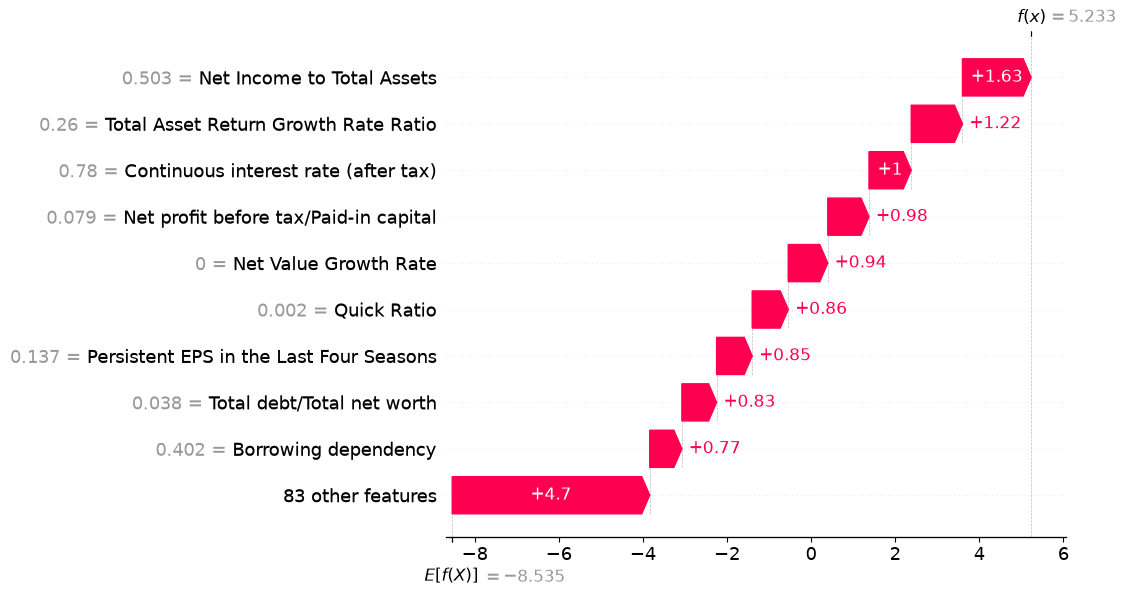

In [85]:
row = int(np.argmax(raw))
row_sum = float(shap_values.base_values[row] + shap_values.values[row].sum())
answer_10_2 = (row_sum, mlkit.logistic_probability(row_sum))
print(f"row label {X_train.index[row]}: base {shap_values.base_values[row]:.4f} plus SHAP values = {row_sum:.4f} log-odds, "
      f"probability {answer_10_2[1]:.4f}; bankrupt in the file: {y_train.iloc[row]}")
shap.plots.waterfall(shap_values[row], max_display=10, show=False)
plt.show()

* Base -8.5347 plus the row's contributions gives 5.2329 in log-odds, a model probability of 0.9947; the row is bankrupt in the file. The contributions add in log-odds, not in probability, so no bar of the waterfall is "points of probability" (day 14's AI check).

In [86]:
check('Question 10.2', answer_10_2, '0624b26bfaa8', places=4)

Question 10.2: correct


### 10.3 Every row, every feature

Q. Draw the beeswarm of the ten features with the largest mean absolute SHAP value (`shap.plots.beeswarm(shap_values, max_display=10, show=False)`). There is no check: describe what it shows in one sentence, as the model's contributions against each feature's values.

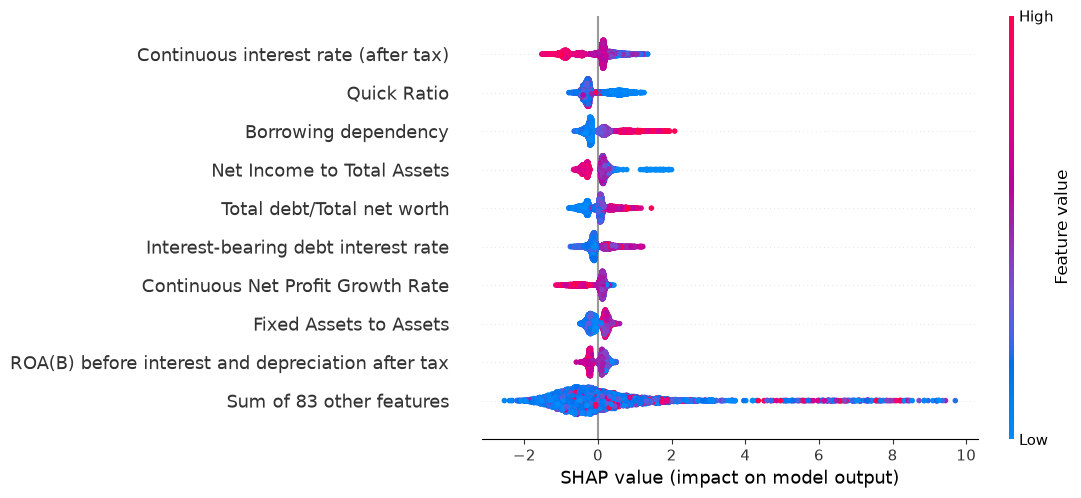

In [87]:
shap.plots.beeswarm(shap_values, max_display=10, show=False)
plt.show()

* Each dot is a training row; its place is the feature's contribution to that row's log-odds and its colour the feature's value. Where high values of a feature sit on one side, the model gives that side's rows higher or lower log-odds in this file. A contribution plotted against a feature's values describes the model; it is never the effect of changing the feature.

### 10.4 SHAP against permutation importance

Q. Compute permutation importance on held-out folds of the training rows: for each fold of `mlkit.cv_folds()`, fit a clone of `best[chosen]` on the other four and run `permutation_importance(..., scoring="average_precision", n_repeats=3, random_state=SEED, n_jobs=1)` on the held-out fold; average the five `importances_mean`. Store a tuple (the top feature by permutation importance, how many features are in both top tens) in **answer_10_4**.

In [88]:
fold_importances = []
for fit_rows, held_out in mlkit.cv_folds().split(X_train, y_train):
    fold_model = clone(best[chosen]).fit(X_train.iloc[fit_rows], y_train.iloc[fit_rows])
    result = permutation_importance(fold_model, X_train.iloc[held_out], y_train.iloc[held_out], scoring="average_precision",
                                    n_repeats=3, random_state=SEED, n_jobs=1)
    fold_importances.append(result.importances_mean)
permutation = pd.Series(np.mean(fold_importances, axis=0), index=X_train.columns).sort_values(ascending=False, kind="stable")
answer_10_4 = (permutation.index[0], len(set(permutation.index[:10]) & set(shap_top.index)))
print(permutation.head(10).round(4).to_string())
print(f"in both top tens: {answer_10_4[1]}")

Interest-bearing debt interest rate            0.0530
Total debt/Total net worth                     0.0483
Quick Ratio                                    0.0332
Borrowing dependency                           0.0310
Persistent EPS in the Last Four Seasons        0.0217
Continuous interest rate (after tax)           0.0175
Non-industry income and expenditure/revenue    0.0136
Revenue per person                             0.0125
Total Asset Growth Rate                        0.0122
Net Value Growth Rate                          0.0119
in both top tens: 5


* By permutation importance (the drop in held-out average precision when a column is shuffled) the top feature is `Interest-bearing debt interest rate`, and 5 features are in both top tens. The two measures ask different questions: SHAP measures how large a feature's contributions are; permutation importance measures how much the held-out score falls without it. Correlated columns (question 3.4) share both, so a feature low on one list may have a near copy higher up.

In [89]:
check('Question 10.4', answer_10_4, 'a3b47484ce80')

Question 10.4: correct


### 10.5 Split counts, and the two-scale columns

Q. Count how often each feature is used to split in the chosen model (`model.booster_.feature_importance(importance_type="split")`, one count per column of `X_train`). How many of the ten features with the most splits are two-scale columns (in `two_scale`), and how many of the top ten by SHAP? Store a tuple (two-scale in the split top ten, two-scale in the SHAP top ten) in **answer_10_5**.

In [90]:
splits = pd.Series(model.booster_.feature_importance(importance_type="split"), index=X_train.columns)
splits = splits.sort_values(ascending=False, kind="stable")
answer_10_5 = (sum(name in two_scale for name in splits.index[:10]), sum(name in two_scale for name in shap_top.index))
print(splits.head(10).to_string())
print(f"two-scale columns: {answer_10_5[0]} of the split top ten, {answer_10_5[1]} of the SHAP top ten")

Total Asset Growth Rate                        83
Interest-bearing debt interest rate            74
Revenue per person                             66
Allocation rate per person                     56
Inventory/Current Liability                    56
Inventory Turnover Rate (times)                53
Quick Ratio                                    52
Non-industry income and expenditure/revenue    51
Operating Expense Rate                         51
Cash Turnover Rate                             48
two-scale columns: 9 of the split top ten, 5 of the SHAP top ten


* 9 of the ten most-split features are two-scale columns, against 5 of the SHAP top ten. A split count rewards a column with many distinct values and a wide range, which gives a tree many places to cut, including cuts that separate a few rows; the two-scale columns are such columns. It counts how often a column is used, not how much it moves the output. That is a fact about how the measure is built, the same lesson as impurity importance and the noise column of day 4.

In [91]:
check('Question 10.5', answer_10_5, '945abac55827')

Question 10.5: correct


## 11 The Results Workbook

### 11.1 Deliverable 11: the workbook

Q. Write `course5_capstone_results.xlsx` with `pd.ExcelWriter`, four sheets in this order: `comparison` (the section 9 table, index named `model`), `intervals` (index named `model`), `thresholds` (`threshold_table`, index named `model`), and `test_scores` (three columns, no index: `row`, the test row's label; `class`; `probability`, the chosen model's test probability). Read it back with `pd.read_excel(..., sheet_name=None)` and store a tuple (number of sheets, the chosen model's average precision read from `comparison`) in **answer_11_1**, to 4 decimals.

In [92]:
proba_test = best[chosen].predict_proba(X_test)[:, 1]
with pd.ExcelWriter("course5_capstone_results.xlsx") as writer:
    comparison.rename_axis("model").to_excel(writer, sheet_name="comparison")
    intervals.rename_axis("model").to_excel(writer, sheet_name="intervals")
    threshold_table.rename_axis("model").to_excel(writer, sheet_name="thresholds")
    pd.DataFrame({"row": X_test.index, "class": y_test.to_numpy(), "probability": proba_test}).to_excel(
        writer, sheet_name="test_scores", index=False)

# read every sheet back and check it against the tables it came from
back = pd.read_excel("course5_capstone_results.xlsx", sheet_name=None)
assert list(back) == ["comparison", "intervals", "thresholds", "test_scores"], list(back)
# openpyxl writes each float with 16 significant digits, so a value can come back changed in its 17th
pd.testing.assert_frame_equal(back["comparison"].set_index("model").rename_axis(None), comparison, rtol=1e-14, atol=0)
assert np.allclose(back["test_scores"]["probability"].to_numpy(), proba_test, rtol=1e-14, atol=0)
answer_11_1 = (len(back), back["comparison"].set_index("model").loc[chosen, "average_precision"])
print(f"{answer_11_1[0]} sheets: {', '.join(f'{name} ({len(table)} rows)' for name, table in back.items())}")

4 sheets: comparison (4 rows), intervals (4 rows), thresholds (4 rows), test_scores (1364 rows)


* Four sheets, every value read back within a relative 1e-14 of the table it came from. The workbook is ignored by Git (`*.xlsx`): it is an output, rebuilt from `taiwan.py`, `results.csv`, and the data at any time. Excel Side by Side opens it.

In [93]:
check('Question 11.1', answer_11_1, '2db328319991', places=4)

Question 11.1: correct


## 12 What the Model Shows, and Where It Fails

### 12.1 The bankruptcies it missed

Q. Among the bankrupt test rows the chosen model did not flag, how many had a probability below half its threshold? Store the count in **answer_12_1**.

In [94]:
threshold = thresholds[chosen]
missed = (y_test.to_numpy() == 1) & (proba_test < threshold)
answer_12_1 = int((proba_test[missed] < threshold / 2).sum())
print(f"missed bankruptcies: {missed.sum()}; with a probability below half the threshold ({threshold / 2:.4f}): {answer_12_1}")

missed bankruptcies: 11; with a probability below half the threshold (0.0070): 9


* 11 missed, 9 of them with less than half the threshold's probability: rows whose ratios put them among the companies that did not go bankrupt, as far as this model ranks them.

In [95]:
check('Question 12.1', answer_12_1, 'c5ec31cc9748')

Question 12.1: correct


### 12.2 Deliverable 12: the written description

Q. Write "What the model shows, and where it fails" in the cell below, in 300 to 500 words of markdown, and run it: it writes `description.md`. Then run the cell after it, which checks your page with `ensemblekit.assert_described` (day 14) and displays it. Commit it. Cover:

1. **The data.** The file, its source and licence, what you dropped, the split.
2. **What was compared,** and how the choice was made, on which rows.
3. **What it shows on the test rows,** with the intervals and the counts.
4. **Which ratios it leans on,** described as association, with the measure named.
5. **Where it fails.** Which errors, at what threshold, on how many rows.
6. **What the data cannot support,** and what was not tested.

The rule, once more: **describe, never forecast, and never explain causes.** `assert_described` stops on forecast words and on cause words such as "because"; a sentence that needs one is rewritten. The word lists are a reminder, not a proof. There is no check cell for this question.

In [96]:
%%writefile description.md
# What the model shows, and where it fails

**The data.** 6,819 rows of company financial ratios from the UCI Machine Learning Repository (dataset 572, CC BY 4.0), collected from the Taiwan Economic Journal for 1999 to 2009, with 220 rows flagged bankrupt (3.23 percent). One constant column and the second column of two exactly equal pairs were dropped, leaving 92 features under the file's own names. A stratified split put 5,455 rows in training and 1,364 in test, with 44 bankrupt test rows.

**What was compared.** Four models, each tuned by a randomized search on five folds of the training rows: a logistic regression on quantile-transformed ratios, a random forest, XGBoost, and LightGBM. By the best mean average precision on the folds, LightGBM led (0.4545) and the logistic regression trailed (0.4259); the lead was smaller than one fold standard deviation, so the call was close. Neither class weights nor SMOTE raised the leading model's mean average precision on the folds. LightGBM was chosen before the test rows were opened; its nested score was 0.4329, with outer folds from 0.3303 to 0.5463.

**What it shows on the test rows.** Average precision 0.5073 (95 percent bootstrap interval 0.3517 to 0.6671) and ROC AUC 0.9568. At the threshold chosen on the training folds for a recall of 0.70, it flagged 112 test rows and caught 33 of the 44 bankruptcies. On the test rows a logistic regression scored the highest average precision (0.5159), a different order from the folds', and the four models' test intervals overlap almost entirely, so the test rows do not separate them.

**Which ratios it leans on.** By mean absolute SHAP value, the model's largest contributions to its log-odds come from Continuous interest rate (after tax), Quick Ratio, and Borrowing dependency. These are associations in this file, inside this model, and they say nothing about why any company failed. Permutation importance on held-out folds shares 5 of its top ten with SHAP; split counts favour the columns that hold two scales of number, a property of how split counts are built. Ten pairs of columns are nearly equal, so importance is shared between near copies.

**Where it fails.** It missed 11 test bankruptcies, 9 of them with a probability below half the threshold, and flagged 79 rows that did not go bankrupt. With 44 bankrupt test rows, each one moves recall by 2.3 points.

**What the data cannot support.** One market and period; a bankruptcy defined by exchange regulation, with no horizon stated; no company identifier, so rows may repeat a company across years and sit on both sides of the split; 24 columns whose two scales the page does not explain; and a row order that carries the outcome. Nothing here is a rating, a probability of bankruptcy for any company going forward, or a view on any company. Not tested: other seeds and splits, recalibration of the probabilities, larger searches, and any other file.

Writing description.md


In [97]:
# check the page against the course's word lists (it raises ValueError naming any word found), then show it
page_text = Path("description.md").read_text(encoding="utf-8")
ensemblekit.assert_described(page_text)
n_words = len(re.findall(r"[A-Za-z0-9]\S*", page_text.split("\n", 1)[-1]))
print(f"No word from the lists. {n_words} words after the title. Read it once more for meaning: the lists are a reminder.")
display(Markdown(page_text))

No word from the lists. 479 words after the title. Read it once more for meaning: the lists are a reminder.


# What the model shows, and where it fails

**The data.** 6,819 rows of company financial ratios from the UCI Machine Learning Repository (dataset 572, CC BY 4.0), collected from the Taiwan Economic Journal for 1999 to 2009, with 220 rows flagged bankrupt (3.23 percent). One constant column and the second column of two exactly equal pairs were dropped, leaving 92 features under the file's own names. A stratified split put 5,455 rows in training and 1,364 in test, with 44 bankrupt test rows.

**What was compared.** Four models, each tuned by a randomized search on five folds of the training rows: a logistic regression on quantile-transformed ratios, a random forest, XGBoost, and LightGBM. By the best mean average precision on the folds, LightGBM led (0.4545) and the logistic regression trailed (0.4259); the lead was smaller than one fold standard deviation, so the call was close. Neither class weights nor SMOTE raised the leading model's mean average precision on the folds. LightGBM was chosen before the test rows were opened; its nested score was 0.4329, with outer folds from 0.3303 to 0.5463.

**What it shows on the test rows.** Average precision 0.5073 (95 percent bootstrap interval 0.3517 to 0.6671) and ROC AUC 0.9568. At the threshold chosen on the training folds for a recall of 0.70, it flagged 112 test rows and caught 33 of the 44 bankruptcies. On the test rows a logistic regression scored the highest average precision (0.5159), a different order from the folds', and the four models' test intervals overlap almost entirely, so the test rows do not separate them.

**Which ratios it leans on.** By mean absolute SHAP value, the model's largest contributions to its log-odds come from Continuous interest rate (after tax), Quick Ratio, and Borrowing dependency. These are associations in this file, inside this model, and they say nothing about why any company failed. Permutation importance on held-out folds shares 5 of its top ten with SHAP; split counts favour the columns that hold two scales of number, a property of how split counts are built. Ten pairs of columns are nearly equal, so importance is shared between near copies.

**Where it fails.** It missed 11 test bankruptcies, 9 of them with a probability below half the threshold, and flagged 79 rows that did not go bankrupt. With 44 bankrupt test rows, each one moves recall by 2.3 points.

**What the data cannot support.** One market and period; a bankruptcy defined by exchange regulation, with no horizon stated; no company identifier, so rows may repeat a company across years and sit on both sides of the split; 24 columns whose two scales the page does not explain; and a row order that carries the outcome. Nothing here is a rating, a probability of bankruptcy for any company going forward, or a view on any company. Not tested: other seeds and splits, recalibration of the probabilities, larger searches, and any other file.


In [98]:
!git -C "{work}" add description.md
!git -C "{work}" commit -q -m "Deliverable 12: what the model shows, and where it fails"
!git -C "{work}" log --oneline

5d649c4 Deliverable 12: what the model shows, and where it fails
1390826 Deliverable 8: the test rows opened once, logged
1b447af Deliverables 6 and 7: the imbalance decision and out-of-fold thresholds, logged
883c5d9 Deliverable 5: four models as functions that return unfitted pipelines
98af253 Deliverable 4: prepare drops the constant column and the equal copies, then splits 80/20
5c051db Deliverable 2: load_taiwan reads, checks, and cleans the names
3d0fe14 Deliverable 1: ensemblekit complete, every test passing


### 12.3 Further practice (Deliverable 13)

For loan-level credit data at scale, Freddie Mac publishes its Single-Family Loan-Level Dataset, free with registration, with a sample file per vintage year: https://www.freddiemac.com/research/datasets/sf-loanlevel-dataset . Its terms prohibit redistribution, so it cannot sit in this repo: register, download it yourself, and run this notebook's steps on it in your own folder.

### 12.4 Deliverable 15: the AI-use log

Q. Fill in the log in the cell below, one row for each time you asked an AI assistant for help with the capstone: what you asked, what you accepted or rejected, and how you checked it. If you used none, write `none used` in the first row. Run the cell: it writes `ai_use_log.md` in the work folder. Then commit it.

What never goes into an AI tool, or into a cloud notebook such as Colab: client names, positions, anything from your employer, and licensed data. This file is public and anonymised, but the habit is the same: describe the columns and the task, and keep the rows out. Your firm's policy comes before anything said here. There is no check cell for this question.

In [99]:
%%writefile ai_use_log.md
# AI-use log

An example of a filled-in log, written for this course to show the level of detail to aim for.

| What I asked | What I accepted or rejected | How I checked it |
| --- | --- | --- |
| How to remove the yen sign from three column names without a non-ASCII character in my file | Accepted writing the sign as the escape "\u00a5". Rejected re-encoding the whole file, which would have changed the data file the licence asks me to keep as published | Printed the three cleaned names and checked every name is ASCII in load_taiwan's log |
| A docstring for prepare | Accepted the wording on the equal pairs. Rejected a line saying the split "balances the classes": stratifying keeps the share the same; it does not balance it | Read every line against the code, then ran the checks of section 4 |
| Why my SHAP values did not add up to the model's output | Accepted that they add up in log-odds, so the comparison is with predict(X, raw_score=True). Rejected a suggestion to rescale them until they matched predict_proba, which is a probability | Ran assert_additive on the raw score, and logistic_probability on the sum against predict_proba |

No row of the file went into the assistant. Each question described the columns and the task.

Writing ai_use_log.md


In [100]:
!git -C "{work}" add ai_use_log.md
!git -C "{work}" commit -q -m "Deliverable 15: the AI-use log"
!git -C "{work}" log --oneline

f3902e3 Deliverable 15: the AI-use log
5d649c4 Deliverable 12: what the model shows, and where it fails
1390826 Deliverable 8: the test rows opened once, logged
1b447af Deliverables 6 and 7: the imbalance decision and out-of-fold thresholds, logged
883c5d9 Deliverable 5: four models as functions that return unfitted pipelines
98af253 Deliverable 4: prepare drops the constant column and the equal copies, then splits 80/20
5c051db Deliverable 2: load_taiwan reads, checks, and cleans the names
3d0fe14 Deliverable 1: ensemblekit complete, every test passing


## Excel Side by Side

Excel has no worksheet function for a random forest, XGBoost, LightGBM, a randomized search, cross-validation, SMOTE, or SHAP, so the models stay in Python. What Excel does well is the counting and the arithmetic after them. Every formula below was typed into desktop Excel for Windows by script, on the workbook this notebook's code writes and on values pasted from it, and its result read back.

Open `course5_capstone_results.xlsx` from the work folder (its name is in the setup cell's output; in File Explorer, paste `%TEMP%` into the address bar). It has the four sheets of question 11.1, in that order, with the column names in row 1; every cell holds a value, none a formula, because pandas wrote numbers. On `test_scores`, column A is the row label, B the class, C the chosen model's probability; on `thresholds`, the chosen model's threshold is in B5 (its row follows the order logistic, forest, xgboost, lightgbm).

| Job | Python | Excel (tested) | Excel returned |
| --- | --- | --- | --- |
| True positives: bankrupt and flagged | `confusion_counts(...)["tp"]` | `=COUNTIFS(test_scores!B2:B1365,1,test_scores!C2:C1365,">="&thresholds!B5)` in F2 | 33 |
| False positives | `["fp"]` | `=COUNTIFS(test_scores!B2:B1365,0,test_scores!C2:C1365,">="&thresholds!B5)` in F3 | 79 |
| False negatives | `["fn"]` | `=COUNTIFS(test_scores!B2:B1365,1,test_scores!C2:C1365,"<"&thresholds!B5)` in F4 | 11 |
| True negatives | `["tn"]` | `=COUNTIFS(test_scores!B2:B1365,0,test_scores!C2:C1365,"<"&thresholds!B5)` in F5 | 1,241 |
| Precision at the threshold | `comparison.loc[chosen, "precision"]` | `=F2/(F2+F3)` | 0.2946 |
| Recall at the threshold | `comparison.loc[chosen, "recall"]` | `=F2/(F2+F4)` | 0.7500 |
| Nested mean, five folds | `nested.mean()` | `=AVERAGE(A1:A5)` on the five pasted fold scores | 0.4329 |
| Nested fold sd | `nested.std(ddof=0)` | `=STDEV.P(A1:A5)` | 0.0851 |
| Bootstrap interval, lower | `bootstrap_interval(...)[0]` | `=PERCENTILE.INC(E1:E1000,0.025)` on the 1,000 pasted values | 0.3517 |
| Bootstrap interval, upper | `bootstrap_interval(...)[1]` | `=PERCENTILE.INC(E1:E1000,0.975)` | 0.6671 |
| One row's log-odds from its SHAP values | `base_values[row] + values[row].sum()` | `=I1+SUM(I2:I93)` | 5.2329 |
| Its probability | `mlkit.logistic_probability(row_sum)` | `=1/(1+EXP(-K1))` | 0.9947 |

**The confusion matrix.** On a new sheet, `COUNTIFS` counts the rows that meet every condition: a class, and a probability compared with the threshold cell. `">="&thresholds!B5` joins the comparison to the threshold's value: a row is flagged when its probability is **at least** the threshold, the course's rule. With the four counts in F2 to F5, precision is true positives over everything flagged, and recall true positives over every bankrupt row.

**The nested score and the interval.** Paste the five nested fold scores into A1:A5: `AVERAGE` is the mean and `STDEV.P` the standard deviation pandas computes with `ddof=0`; `STDEV.S` divides by 4 instead of 5 and gives a larger number (tested: 0.0951). Paste the chosen model's 1,000 bootstrap average precisions into E1:E1000: `PERCENTILE.INC` at 0.025 and 0.975 is `numpy.percentile`'s linear method, the interval `bootstrap_interval` returns.

**One row adding up.** Paste the row of question 10.2's base value into I1 and its 92 SHAP values into I2 down: `=I1+SUM(...)` gives the model's log-odds and `=1/(1+EXP(-K1))` its probability, the logistic function `mlkit.logistic_probability` computes.

* Excel showed the sheets `comparison`, `intervals`, `thresholds`, `test_scores` with no formula on any of them, and read the chosen model's average precision and threshold as the notebook's values within a relative 1e-14. The four `COUNTIFS` counts equal `confusion_counts`; precision, recall, the nested mean and sd, and both percentiles equal Python within 1e-12. The SHAP row's sum and its probability equal LightGBM's log-odds and probability within 1e-9.

## Save the Day with Git

### Deliverable 14: the history

Q. Show the history with `git log --oneline`: one commit for each deliverable that writes a file. Store the number of commits in **answer_git**. Then tag the last commit `course5`, and show the history with its names.

In [101]:
# one line per commit, newest first
!git -C "{work}" log --oneline

f3902e3 Deliverable 15: the AI-use log


5d649c4 Deliverable 12: what the model shows, and where it fails
1390826 Deliverable 8: the test rows opened once, logged
1b447af Deliverables 6 and 7: the imbalance decision and out-of-fold thresholds, logged
883c5d9 Deliverable 5: four models as functions that return unfitted pipelines
98af253 Deliverable 4: prepare drops the constant column and the equal copies, then splits 80/20
5c051db Deliverable 2: load_taiwan reads, checks, and cleans the names
3d0fe14 Deliverable 1: ensemblekit complete, every test passing


In [102]:
# count the commits: one line each in git log --oneline
history_log = subprocess.run(["git", "-C", str(work), "log", "--oneline"], capture_output=True, text=True, check=True).stdout
answer_git = len(history_log.strip().splitlines())
print(f"Commits: {answer_git}")

Commits: 8


In [103]:
# name the last commit, then show the names
!git -C "{work}" tag course5
!git -C "{work}" log --oneline --decorate

f3902e3 (HEAD -> main, tag: course5) Deliverable 15: the AI-use log
5d649c4 Deliverable 12: what the model shows, and where it fails
1390826 Deliverable 8: the test rows opened once, logged
1b447af Deliverables 6 and 7: the imbalance decision and out-of-fold thresholds, logged
883c5d9 Deliverable 5: four models as functions that return unfitted pipelines
98af253 Deliverable 4: prepare drops the constant column and the equal copies, then splits 80/20
5c051db Deliverable 2: load_taiwan reads, checks, and cleans the names
3d0fe14 Deliverable 1: ensemblekit complete, every test passing


* 8 commits: the module, `load_taiwan`, `prepare`, the four model functions, the out-of-fold log, the test rows, the description, and the AI-use log. The workbook stays out, and so do the data copies. `git diff --stat` in section 9 showed the experiment log grow by its test rows.
* `course5` names the commit that ends the course.

In [104]:
check('Question Git', answer_git, '1c20d3be44cc')

Question Git: correct


## Bring It Home

Bring the capstone into your own `my_bondmath` folder. Open a PowerShell terminal in VS Code (Terminal, New Terminal), with the course's `.venv` active.

**Step 1.** Go to your folder, and check that your module still passes.

```powershell
Set-Location "$HOME\projects\my_bondmath"
python -m pytest -q test_ensemblekit.py
```

**Step 2.** Copy `taiwan.py` and `description.md` from the work folder. The setup cell printed its name, `pfi_course5_15_` and eight more characters: put it in place of `<work folder>`. Copy the data file too, for running the module; it is a copy, so it is never committed.

```powershell
$work = "$env:TEMP\<work folder>"
Copy-Item "$work\taiwan.py", "$work\description.md" .
Copy-Item "$HOME\projects\python-fixed-income\data\taiwan_bankruptcy.csv" .
```

**Step 3.** Check that the module loads the file from your folder, then commit the code and the description, and tag the end of the course.

```powershell
python -c "import taiwan; frame, log = taiwan.load_taiwan('taiwan_bankruptcy.csv'); print(log)"
git add taiwan.py description.md
git commit -m "Course 5 capstone: taiwan.py and the description"
git tag course5
git log --oneline --decorate -3
```

`taiwan.py` imports `mlkit` from the same folder, so it runs there as it ran in the notebook.

**In Colab**, download `taiwan.py`, `description.md`, and `course5_capstone_results.xlsx` from the work folder under `/tmp` in the file browser.

## You Can Now

* Check a real file against its source, clean its names as a stated step, and describe it in full before any split: constants, copies, near copies, two scales, and an order that carries the outcome.
* Prepare a split that keeps the file's bankrupt share and lets nothing from the test rows reach a feature, a setting, or a choice.
* Tune four kinds of model with randomized searches, and say when their differences are smaller than the noise between folds.
* Decide between weights, SMOTE, and no treatment with numbers, and say what each does to the output.
* Give the chosen model an honest, nested score, open the test rows once, and put an interval on what they show.
* Describe what a model leans on with SHAP values, permutation importance, and split counts, and say why they disagree.
* Write a results workbook that Excel can check, and a description with no forecast, no cause, and no advice.

## Exercises

The capstone's questions are its exercises. One more, last, as on every day of the course.

### The AI check

You ask an AI assistant for the split, and you give it the docstring as the request. **The docstring is the prompt.** This is what you gave it:

```
def split_rows(frame):
    """Split the cleaned file 80/20 into training and test rows, with SEED.

    The test rows must look like the file: their bankrupt share within 0.25 percentage points of the file's, so
    the test score describes the same mix of companies the models were fitted on. Returns X_train, X_test,
    y_train, y_test.
    """
```

The function below came back. It was written for this course in the style of an AI assistant's answer. It runs without an error, returns four parts of the right sizes, and contains one bug.

* The bug: `shuffle=False` keeps the file's order, so the test rows are the last fifth of the file. Section 3 found that bankrupt rows sit early in the file, so that fifth holds only 22 bankrupt rows of 1,364, 1.61 percent against the file's 3.23. The comment makes it sound careful ("easy to audit"), and nothing fails: the sizes are right. Every test number would describe a different mix of companies from the one the models were fitted on.
* The fix, in the cell below: shuffle with the seed and stratify on the outcome, as `prepare` does.

In [105]:
def split_rows(frame):
    """Split the cleaned file 80/20 into training and test rows, with SEED.

    The test rows must look like the file: their bankrupt share within 0.25 percentage points of the file's, so
    the test score describes the same mix of companies the models were fitted on. Returns X_train, X_test,
    y_train, y_test.
    """
    X, y = frame.drop(columns=TARGET), frame[TARGET]
    # the fix: shuffle with the seed and stratify on the outcome, so both parts keep the file's bankrupt share
    return train_test_split(X, y, test_size=0.2, stratify=y, random_state=SEED)

Q. Test the function against its docstring before you trust it.

In [106]:
X_tr, X_te, y_tr, y_te = split_rows(frame)

# the docstring's promise: the test rows' bankrupt share within 0.25 percentage points of the file's
file_share, test_share = 100 * frame[TARGET].mean(), 100 * y_te.mean()
print(f"bankrupt share: file {file_share:.2f} percent, test rows {test_share:.2f} percent ({y_te.sum()} of {len(y_te):,})")
assert abs(test_share - file_share) < 0.25, f"the test rows' bankrupt share is {test_share:.2f} percent, not the file's {file_share:.2f}"

bankrupt share: file 3.23 percent, test rows 3.23 percent (44 of 1,364)


In [107]:
# the assistant's version, kept for comparison: the last fifth of the file in its own order
ai_test_share = 100 * frame[TARGET].iloc[-len(y_te):].mean()
ai_share_fixed = 100 * y_te.mean()
print(f"assistant's version: {ai_test_share:.2f} percent bankrupt in the test rows; fixed version: {ai_share_fixed:.2f} percent")

assistant's version: 1.61 percent bankrupt in the test rows; fixed version: 3.23 percent


* 1.61 percent in the assistant's test rows, 3.23 once fixed, against the file's 3.23. Keep the test: a split's sizes can be right while its rows are not.

In [108]:
check("AI check the assistant's test share", ai_test_share, 'e52c8a2a3fdf', places=2)
check('AI check the fixed test share', ai_share_fixed, '031083a9ee90', places=2)

AI check the assistant's test share: correct
AI check the fixed test share: correct


## Tidying Up

The work folder stays where it is, so you can open it: its name was printed by the setup cell, and on Windows it is under `$env:TEMP`. Every run of the setup cell makes a new one. To delete a work folder, run these lines in a cell of the same notebook session. Git marks its own files read-only, and on Windows a plain delete stops at them with a `PermissionError`, so the handler clears that flag and tries again.

```python
import stat

def clear_read_only(function, path, error):
    """Make a read-only file writable, then retry the delete that failed on it."""
    os.chmod(path, stat.S_IWRITE)
    function(path)

os.chdir(notebook_folder)
shutil.rmtree(work, onexc=clear_read_only)
print(f"{work.name} exists: {work.exists()}")
```